# Trading Strategy Assignment: Exploratory Data Analysis and Strategy Optimization

## Overview

This assignment explores the intersection of **technical analysis**, **natural language processing**, and **large-scale data processing** in the context of algorithmic trading. You will work with historical market data and earnings call transcripts to develop and evaluate trading strategies.

### Learning Objectives

- **Technical Analysis**: Implement and analyze technical indicators (Moving Averages, RSI, MACD, Bollinger Bands)
- **NLP for Finance**: Apply FinBERT (a financial BERT model) for sentiment analysis on earnings transcripts
- **Scalable Computing**: Explore parallelization techniques for computing indicators on large datasets—consider approaches that can reduce latency compared to iterative pandas operations
- **Strategy Development**: Systematically improve a baseline strategy through iterative experimentation
- **Performance Evaluation**: Use proper train/validation split methodology for model development

---

## Data Description

### Price Data
S&P 500 historical price data with the following schema:

| Column | Description |
|--------|-------------|
| `ticker` | Stock symbol (e.g., AAPL, MSFT) |
| `date` | Trading date |
| `open`, `high`, `low`, `close` | OHLC prices |
| `volume` | Trading volume |

### Earnings Data
Earnings call transcripts for sentiment analysis:

| Column | Description |
|--------|-------------|
| `ticker` | Stock symbol |
| `date` | Earnings call date |
| `transcript` | Full text of earnings call |
| `quarter` | Fiscal quarter (e.g., "Q1 2023") |

---

## Data Splits

The data is partitioned to enable proper model development:

| Split | Date Range | Purpose |
|-------|------------|---------|
| **Dev** | 2000-2017 | Create subsets for development and hyperparameter tuning |
| **Val** | 2018-2024 | Final performance reporting (unseen during development) |

**Important**: Use the dev split and create subsets to iterate and experiment. Reserve the val split for final performance reporting only.

---

## Provided Infrastructure

### Baseline Strategy
A simple moving average crossover strategy enhanced with FinBERT sentiment:
- **Entry**: Price > MA-50 AND (no earnings OR positive sentiment)
- **Exit**: Price < MA-50 OR stop-loss at 20%

### Evaluation Framework
Weekly rebalancing backtest simulation with the following metrics:

| Metric | Description | Target |
|--------|-------------|--------|
| **Total Return** | Portfolio value change from starting capital | Maximize |
| **Sharpe Ratio** | Risk-adjusted return (higher is better) | >1.0 is good |
| **Max Drawdown** | Largest peak-to-trough decline | Minimize |
| **Win Rate** | Percentage of profitable trades | >40% |
| **Volatility** | Standard deviation of returns | Lower for same return |

### Visualization Tools
- Portfolio value over time
- Drawdown analysis
- Returns distribution
- Rolling returns
- Comparison charts

---

## Assignment Workflow

1. **Run cells 1-10** to establish baseline performance
2. **Perform advanced EDA** to understand the data
3. **Implement improvements** in `EnhancedStrategy` (Cell 12) across these areas:
   - Data Quality & Cleaning
   - Technical Indicators
   - Enhanced NLP Analysis
   - Smarter Decision Logic
4. **Iterate based on subsets created in dev split** to tune your strategy
5. **Report final performance** on val split when satisfied

---

## Expected Outcomes

By the end of this assignment, you should have:

1. **Implemented** an enhanced trading strategy that improves upon the baseline
2. **Demonstrated** understanding of scalable computing for large-scale data processing
3. **Documented** your development process and key findings
4. **Achieved** measurable improvements in key metrics (Return, Sharpe, Drawdown)

## GPU Configuration (Optional)

**Important:** You can configure your runtime to use GPU acceleration before executing any cells. GPU acceleration provides 3-4x faster inference for the FinBERT model.

### Configuration Steps

Navigate to **Runtime → Change runtime type → Hardware accelerator: T4 GPU → Save**

### Verification

The first cell has print statement that informs the hardware being used

In [1]:
# ============================================================
# CELL 1: Setup
# ============================================================

import pandas as pd
import numpy as np
import time
import warnings
from datetime import timedelta
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import pipeline
import torch

# Local data directory (use INF2006_Data_Students folder)
DATA_DIR = Path(__file__).parent / 'INF2006_Data_Students' if '__file__' in dir() else Path('.') / 'INF2006_Data_Students'
# Fallback: set explicitly if the above doesn't resolve correctly
if not DATA_DIR.exists():
    DATA_DIR = Path(r'c:\Users\Sebert\Desktop\SIT Lambert\Y2T2\INF2006 - Cloud Computing and Big Data\Project\Algorithmic Trading\INF2006_Data_Students')

warnings.filterwarnings('ignore')

# Configuration
STARTING_CASH = 100000
FINBERT_MODEL = "ProsusAI/finbert"
DEVICE = 0 if torch.cuda.is_available() else -1

print(f"Data directory: {DATA_DIR}")
print(f"Initial capital: ${STARTING_CASH:,.0f}")
print(f"Device: {'GPU' if DEVICE >= 0 else 'CPU'}")

c:\Users\Sebert\Desktop\SIT Lambert\Y2T2\INF2006 - Cloud Computing and Big Data\Project\BigData2\Trading-Strategy\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data directory: c:\Users\Sebert\Desktop\SIT Lambert\Y2T2\INF2006 - Cloud Computing and Big Data\Project\Algorithmic Trading\INF2006_Data_Students
Initial capital: $100,000
Device: CPU


In [2]:
# ============================================================
# CELL 2: Initialize FinBERT
# ============================================================

print("Loading FinBERT (first run downloads ~420MB)...")

finbert_pipeline = pipeline(
    "sentiment-analysis",
    model=FINBERT_MODEL,
    tokenizer=FINBERT_MODEL,
    device=DEVICE,
    return_all_scores=True,
    truncation=True,
    max_length=512
)

print("FinBERT loaded.")

Loading FinBERT (first run downloads ~420MB)...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 8111.92it/s]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FinBERT loaded.


In [3]:
# ============================================================
# CELL 3: Data Loading
# ============================================================

import shutil
import tempfile

def load_prices(split='dev'):
    filepath = DATA_DIR / f'prices_{split}.parquet'
    if not filepath.exists():
        raise FileNotFoundError(f"Not found: {filepath}")
    # Copy to short temp path to avoid Windows long-path issues
    tmp = Path(tempfile.gettempdir()) / f'prices_{split}.parquet'
    shutil.copy2(filepath, tmp)
    return pd.read_parquet(tmp)

def load_earnings(split='dev'):
    filepath = DATA_DIR / f'earnings_{split}.parquet'
    if not filepath.exists():
        raise FileNotFoundError(f"Not found: {filepath}")
    tmp = Path(tempfile.gettempdir()) / f'earnings_{split}.parquet'
    shutil.copy2(filepath, tmp)
    return pd.read_parquet(tmp)

prices_dev = load_prices('dev')
prices_val = load_prices('val')
earnings_dev = load_earnings('dev')
earnings_val = load_earnings('val')

print(f"Dev prices:   {len(prices_dev):,} records")
print(f"Val prices:   {len(prices_val):,} records")
print(f"Dev earnings: {len(earnings_dev):,} records")
print(f"Val earnings: {len(earnings_val):,} records")

Dev prices:   1,332,576 records
Val prices:   598,740 records
Dev earnings: 9,729 records
Val earnings: 8,534 records


In [4]:
# ============================================================
# CELL 4: Exploratory Data Analysis
# ============================================================

print("="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

print(f"\n[PRICE DATA]")
print(f"Date range: {prices_dev['date'].min()} to {prices_dev['date'].max()}")
print(f"Unique tickers: {prices_dev['ticker'].nunique()}")
print(f"\nPrice statistics:")
print(prices_dev[['open', 'high', 'low', 'close', 'volume']].describe())

print(f"\n[MISSING VALUES]")
print(prices_dev.isnull().sum())

print(f"\n[EARNINGS DATA]")
print(f"Date range: {earnings_dev['date'].min()} to {earnings_dev['date'].max()}")
print(f"Unique tickers: {earnings_dev['ticker'].nunique()}")

earnings_dev['transcript_length'] = earnings_dev['transcript'].str.len()
print(f"\nTranscript lengths:")
print(earnings_dev['transcript_length'].describe())

price_tickers = set(prices_dev['ticker'].unique())
earnings_tickers = set(earnings_dev['ticker'].unique())
overlap = price_tickers & earnings_tickers
print(f"\n[TICKER OVERLAP]")
print(f"Prices: {len(price_tickers)}, Earnings: {len(earnings_tickers)}, Overlap: {len(overlap)}")

print("="*60)

EXPLORATORY DATA ANALYSIS

[PRICE DATA]
Date range: 2000-01-03 00:00:00-05:00 to 2017-12-29 00:00:00-05:00
Unique tickers: 340

Price statistics:
               open          high           low         close        volume
count  1.332576e+06  1.332576e+06  1.332576e+06  1.332576e+06  1.332576e+06
mean   3.903053e+01  3.950141e+01  3.854264e+01  3.903509e+01  9.345944e+06
std    7.973711e+01  8.078698e+01  7.858469e+01  7.969384e+01  6.199364e+07
min    3.020800e-02  3.052100e-02  2.697900e-02  3.052100e-02  0.000000e+00
25%    1.247500e+01  1.265784e+01  1.228867e+01  1.247801e+01  8.168000e+05
50%    2.318565e+01  2.348415e+01  2.288000e+01  2.319054e+01  2.067218e+06
75%    4.215672e+01  4.263462e+01  4.168111e+01  4.217284e+01  5.068012e+06
max    2.136094e+03  2.160873e+03  2.097645e+03  2.126268e+03  9.230856e+09

[MISSING VALUES]
ticker    0
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

[EARNINGS DATA]
Date range: 2005-10-13 14:45:00 to 201

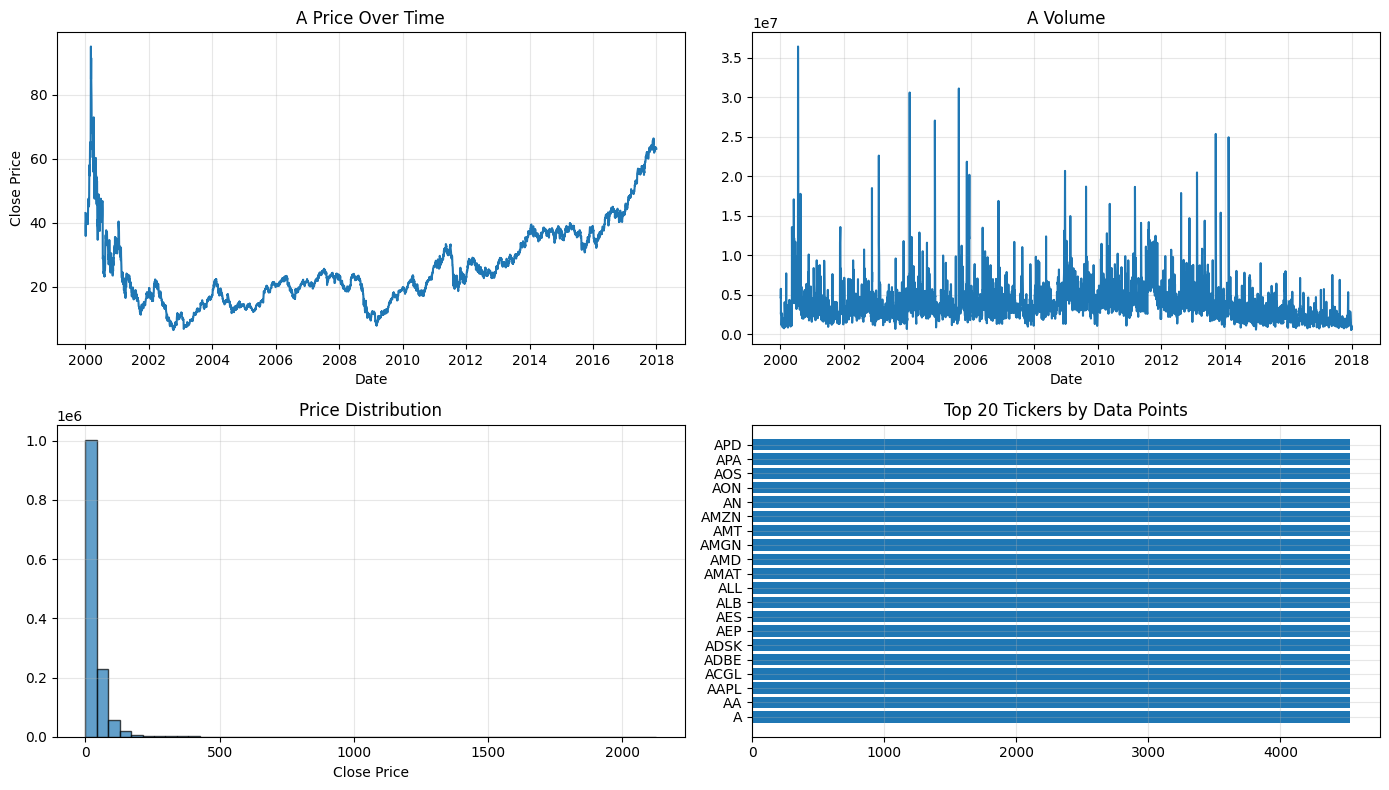

In [5]:
# ============================================================
# CELL 5: Data Visualization
# ============================================================

sample_ticker = prices_dev['ticker'].value_counts().index[0]
sample_prices = prices_dev[prices_dev['ticker'] == sample_ticker].sort_values('date')

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(pd.to_datetime(sample_prices['date']), sample_prices['close'])
axes[0, 0].set_title(f'{sample_ticker} Price Over Time')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Close Price')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(pd.to_datetime(sample_prices['date']), sample_prices['volume'])
axes[0, 1].set_title(f'{sample_ticker} Volume')
axes[0, 1].set_xlabel('Date')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].hist(prices_dev['close'], bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Price Distribution')
axes[1, 0].set_xlabel('Close Price')
axes[1, 0].grid(True, alpha=0.3)

ticker_counts = prices_dev['ticker'].value_counts().head(20)
axes[1, 1].barh(range(len(ticker_counts)), ticker_counts.values)
axes[1, 1].set_yticks(range(len(ticker_counts)))
axes[1, 1].set_yticklabels(ticker_counts.index)
axes[1, 1].set_title('Top 20 Tickers by Data Points')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## Infrastructure

The following classes provide the foundation. You can extend or modify these as you explore.

---

## How the Backtest Simulation Works

### Weekly Rebalancing

The simulation implements a **weekly rebalancing** strategy:

1. **Every Friday**, the strategy evaluates all 400+ S&P 500 stocks
2. For each stock, the strategy makes a decision: `BUY`, `SELL`, or `HOLD`
3. The portfolio is rebalanced based on these decisions
4. Portfolio value and positions are tracked weekly

### Role of Earnings Calls

Earnings call transcripts provide **qualitative sentiment** that complements technical indicators:

| Data Source | Type | Example Signal |
|-------------|------|---------------|
| **Price/Technical** | Quantitative | Price > MA-50 (bullish trend) |
| **Earnings Transcript** | Qualitative | Management sounds confident about Q4 guidance (positive sentiment) |

**FinBERT** (Financial BERT) analyzes earnings transcripts to classify sentiment:
- **Positive**: Management upbeat, strong guidance, growth opportunities
- **Negative**: Cautionary language, cost-cutting, headwinds
- **Neutral**: Factual reporting, balanced outlook

**Example Usage in Strategy:**
```python
# Entry: Price in uptrend AND positive (or no) earnings sentiment
if price > ma_50 and (sentiment == 'positive' or sentiment is None):
    return 'BUY'

# Exit: Price in downtrend OR negative earnings sentiment
if price < ma_50 or sentiment == 'negative':
    return 'SELL'
```


In [6]:
# ============================================================
# CELL 6: Portfolio Class
# ============================================================

class Portfolio:
    def __init__(self, starting_cash=100000):
        self.cash = starting_cash
        self.positions = {}
        self.trades = []

    def buy_target(self, ticker, price, date, target_value=5000):
        if ticker in self.positions:
            return 0
        max_shares = int(target_value // price)
        if max_shares <= 0:
            return 0
        cost = min(max_shares * price, self.cash)
        shares = int(cost // price)
        if shares <= 0:
            return 0
        self.cash -= cost
        self.positions[ticker] = {'shares': shares, 'buy_price': price}
        self.trades.append({'date': date, 'ticker': ticker, 'action': 'BUY',
                          'shares': shares, 'price': price, 'value': cost})
        return shares

    def sell(self, ticker, price, date):
        if ticker not in self.positions:
            return 0
        position = self.positions[ticker]
        shares = position['shares']
        proceeds = shares * price
        del self.positions[ticker]
        self.cash += proceeds
        self.trades.append({'date': date, 'ticker': ticker, 'action': 'SELL',
                          'shares': shares, 'price': price, 'value': proceeds})
        return shares

    def get_value(self, current_prices):
        total = self.cash
        for ticker, pos in self.positions.items():
            if ticker in current_prices:
                total += pos['shares'] * current_prices[ticker]
        return total

    def get_state(self, current_prices):
        return {
            'cash': self.cash,
            'positions': {t: {'shares': p['shares'], 'buy_price': p['buy_price']}
                         for t, p in self.positions.items()},
            'total_value': self.get_value(current_prices)
        }

print("Portfolio class loaded")

Portfolio class loaded


In [7]:
# ============================================================
# CELL 7: Trading Simulation
# ============================================================

class TradingSimulation:
    def __init__(self, prices, earnings, starting_cash=100000):
        self.prices = prices
        self.earnings = earnings
        self.portfolio = Portfolio(starting_cash)
        self.weekly_schedule = self._create_weekly_schedule()
        self._build_lookups()
        # Build price history for fallback to most recent price
        self._build_price_history()

    def _create_weekly_schedule(self):
        min_date = pd.to_datetime(self.prices['date']).min()
        max_date = pd.to_datetime(self.prices['date']).max()
        return pd.date_range(start=min_date, end=max_date, freq='W-FRI').strftime('%Y-%m-%d').tolist()

    def _build_lookups(self):
        # Pre-compute O(1) lookup dictionaries
        # IMPORTANT: Convert dates to strings for consistent matching
        self.prices_by_ticker_date = {}
        for ticker in self.prices['ticker'].unique():
            ticker_prices = self.prices[self.prices['ticker'] == ticker].sort_values('date')
            for _, row in ticker_prices.iterrows():
                # Convert date to string for consistent lookup
                date_str = row['date'] if isinstance(row['date'], str) else pd.to_datetime(row['date']).strftime('%Y-%m-%d')
                self.prices_by_ticker_date[(ticker, date_str)] = row['close']

        self.earnings_by_ticker_week = {}
        for ticker in self.earnings['ticker'].unique():
            ticker_earnings = self.earnings[self.earnings['ticker'] == ticker].sort_values('date')
            for _, row in ticker_earnings.iterrows():
                earnings_date = pd.to_datetime(row['date'])
                week_end = (earnings_date + timedelta (days=(4 - earnings_date.weekday()) % 7)).strftime('%Y-%m-%d')
                self.earnings_by_ticker_week[(ticker, week_end)] = row['transcript']

    def _build_price_history(self):
        """Build price history for each ticker to enable fallback to most recent price."""
        self.price_history = {}
        for ticker in self.prices['ticker'].unique():
            ticker_prices = self.prices[self.prices['ticker'] == ticker].sort_values('date')
            # Store as list of (date_string, price) tuples
            self.price_history[ticker] = [
                (row['date'] if isinstance(row['date'], str) else pd.to_datetime(row['date']).strftime('%Y-%m-%d'), row['close'])
                for _, row in ticker_prices.iterrows()
            ]

    def _get_price_on_date(self, ticker, date):
        """Get price for ticker on specific date, with fallback to most recent price."""
        # Try direct lookup first
        direct = self.prices_by_ticker_date.get((ticker, date))
        if direct is not None:
            return direct

        # Fallback: find most recent price before this date
        if ticker in self.price_history:
            for hist_date, price in reversed(self.price_history[ticker]):
                if hist_date <= date:
                    return price

        return None

    def _get_current_prices(self, date):
        """Get current prices for all tickers, with fallback to most recent prices."""
        current_prices = {}
        for ticker in self.prices['ticker'].unique():
            price = self._get_price_on_date(ticker, date)
            if price is not None:
                current_prices[ticker] = price
        return current_prices

    def _get_recent_earnings(self, ticker, current_date, days_lookback=7):
        return self.earnings_by_ticker_week.get((ticker, current_date))

    def run(self, strategy_function, analytics_lookup, verbose=False):
        portfolio_history = []
        all_tickers = sorted(self.prices['ticker'].unique())

        for i, week_date in enumerate(self.weekly_schedule):
            if verbose and i % 10 == 0:
                print(f"  Week {i+1}/{len(self.weekly_schedule)}: {week_date}")

            current_prices = self._get_current_prices(week_date)
            portfolio_state = self.portfolio.get_state(current_prices)

            for ticker in all_tickers:
                transcript = self._get_recent_earnings(ticker, week_date)

                ticker_data = analytics_lookup.get(ticker, [])
                latest_analytics = None
                for analytics_date, analytics_dict in ticker_data:
                    if analytics_date <= week_date:
                        latest_analytics = analytics_dict
                    else:
                        break
                if latest_analytics is None:
                    continue

                decision = strategy_function(ticker, week_date, transcript, portfolio_state, latest_analytics)
                price = self._get_price_on_date(ticker, week_date)
                if price is None:
                    continue

                if decision == 'BUY':
                    self.portfolio.buy_target(ticker, price, week_date, target_value=5000)
                elif decision == 'SELL':
                    self.portfolio.sell(ticker, price, week_date)

            portfolio_history.append({
                'date': week_date,
                'portfolio_value': self.portfolio.get_value(current_prices),
                'cash': self.portfolio.cash,
                'positions': len(self.portfolio.positions)
            })

        final_date = self.weekly_schedule[-1]
        final_prices = self._get_current_prices(final_date)
        return {
            'trades': self.portfolio.trades,
            'portfolio_history': portfolio_history,
            'final_portfolio': self.portfolio.get_state(final_prices),
            'final_prices': final_prices
        }

print("TradingSimulation class loaded")

TradingSimulation class loaded


In [8]:
# ============================================================
# CELL 8: Performance Metrics & Visualization
# ============================================================

def calculate_metrics(results, starting_cash=STARTING_CASH):
    """Calculate comprehensive performance metrics."""
    history_df = pd.DataFrame(results['portfolio_history'])
    history_df['date'] = pd.to_datetime(history_df['date'])
    trades_df = pd.DataFrame(results['trades'])

    final_value = results['final_portfolio']['total_value']
    total_return = (final_value - starting_cash) / starting_cash

    history_df['daily_return'] = history_df['portfolio_value'].pct_change()

    mean_daily_return = history_df['daily_return'].mean()
    std_daily_return = history_df['daily_return'].std()
    sharpe_ratio = (mean_daily_return / std_daily_return * np.sqrt(252)) if std_daily_return > 0 else 0

    peak = history_df['portfolio_value'].cummax()
    drawdown = (history_df['portfolio_value'] - peak) / peak
    max_drawdown = drawdown.min()

    if len(trades_df) > 0:
        buy_trades = trades_df[trades_df['action'] == 'BUY']
        sell_trades = trades_df[trades_df['action'] == 'SELL']
        profitable_trades = 0
        total_trades = 0
        for _, sell in sell_trades.iterrows():
            buy = buy_trades[buy_trades['ticker'] == sell['ticker']]
            buy = buy[buy['date'] < sell['date']]
            if len(buy) > 0:
                buy = buy.iloc[-1]
                if sell['value'] > buy['value']:
                    profitable_trades += 1
                total_trades += 1
        win_rate = profitable_trades / total_trades if total_trades > 0 else 0
    else:
        win_rate = 0

    volatility = std_daily_return * np.sqrt(252) if std_daily_return > 0 else 0

    return {
        'total_return': total_return,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown': max_drawdown,
        'win_rate': win_rate,
        'volatility': volatility,
        'num_trades': len(trades_df),
        'final_positions': len(results['final_portfolio']['positions'])
    }


def plot_results(results, metrics, title="Strategy Results", starting_cash=STARTING_CASH):
    """Generate visualization plots for strategy results."""
    history_df = pd.DataFrame(results['portfolio_history'])
    history_df['date'] = pd.to_datetime(history_df['date'])

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(title, fontsize=16, fontweight='bold')

    # Portfolio value
    axes[0, 0].plot(history_df['date'], history_df['portfolio_value'], linewidth=2, color='#2E86AB')
    axes[0, 0].axhline(y=starting_cash, color='r', linestyle='--', alpha=0.5, label='Starting Capital')
    axes[0, 0].set_title('Portfolio Value')
    axes[0, 0].set_xlabel('Date')
    axes[0, 0].set_ylabel('Value ($)')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()
    axes[0, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

    # Cash
    axes[0, 1].plot(history_df['date'], history_df['cash'], color='#22C55E', linewidth=2)
    axes[0, 1].set_title('Cash Position')
    axes[0, 1].set_xlabel('Date')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

    # Positions
    axes[0, 2].plot(history_df['date'], history_df['positions'], color='#9467BE', linewidth=2)
    axes[0, 2].set_title('Number of Positions')
    axes[0, 2].set_xlabel('Date')
    axes[0, 2].grid(True, alpha=0.3)

    # Drawdown
    peak = history_df['portfolio_value'].cummax()
    drawdown = (history_df['portfolio_value'] - peak) / peak * 100
    axes[1, 0].fill_between(history_df['date'], drawdown, 0, color='#E15759', alpha=0.3)
    axes[1, 0].plot(history_df['date'], drawdown, color='#E15759', linewidth=1)
    axes[1, 0].set_title('Drawdown %')
    axes[1, 0].set_xlabel('Date')
    axes[1, 0].grid(True, alpha=0.3)

    # Daily returns distribution - filter out inf and NaN values
    daily_returns = history_df['portfolio_value'].pct_change().dropna() * 100
    # Filter out infinite and extreme values that can occur when portfolio goes to zero
    daily_returns = daily_returns[np.isfinite(daily_returns)]
    daily_returns = daily_returns[daily_returns > -100]  # Remove -100% (total loss) outliers for cleaner histogram
    if len(daily_returns) > 0:
        axes[1, 1].hist(daily_returns, bins=30, edgecolor='black', alpha=0.7, color='#4DB6AC')
    axes[1, 1].set_title('Weekly Returns Distribution')
    axes[1, 1].set_xlabel('Return (%)')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].axvline(x=0, color='black', linestyle='-', alpha=0.3)

    # Rolling returns - also filter out inf values
    rolling_return = history_df['portfolio_value'].pct_change(periods=20).dropna() * 100
    rolling_return = rolling_return[np.isfinite(rolling_return)]
    axes[1, 2].plot(history_df['date'][:len(rolling_return)], rolling_return, linewidth=2, color='#FF9845')
    axes[1, 2].axhline(y=0, color='black', linestyle='-', alpha=0.3)
    axes[1, 2].set_title('20-Week Rolling Return')
    axes[1, 2].set_xlabel('Date')
    axes[1, 2].set_ylabel('Return (%)')
    axes[1, 2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_comparison(results_baseline, metrics_baseline, results_enhanced, metrics_enhanced, starting_cash=STARTING_CASH):
    """Plot side-by-side comparison of baseline vs enhanced strategy."""
    baseline_df = pd.DataFrame(results_baseline['portfolio_history'])
    baseline_df['date'] = pd.to_datetime(baseline_df['date'])
    baseline_df['strategy'] = 'Baseline'

    enhanced_df = pd.DataFrame(results_enhanced['portfolio_history'])
    enhanced_df['date'] = pd.to_datetime(enhanced_df['date'])
    enhanced_df['strategy'] = 'Enhanced'

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Baseline vs Enhanced Strategy Comparison', fontsize=16, fontweight='bold')

    # Portfolio Value Over Time
    axes[0, 0].plot(baseline_df['date'], baseline_df['portfolio_value'], linewidth=2, label='Baseline', color='#E15759', alpha=0.8)
    axes[0, 0].plot(enhanced_df['date'], enhanced_df['portfolio_value'], linewidth=2, label='Enhanced', color='#2E86AB', alpha=0.8)
    axes[0, 0].axhline(y=starting_cash, color='gray', linestyle='--', alpha=0.5, label='Starting Capital')
    axes[0, 0].set_title('Portfolio Value Over Time')
    axes[0, 0].set_xlabel('Date')
    axes[0, 0].set_ylabel('Portfolio Value ($)')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

    # Drawdown Comparison
    peak_baseline = baseline_df['portfolio_value'].cummax()
    drawdown_baseline = (baseline_df['portfolio_value'] - peak_baseline) / peak_baseline * 100
    peak_enhanced = enhanced_df['portfolio_value'].cummax()
    drawdown_enhanced = (enhanced_df['portfolio_value'] - peak_enhanced) / peak_enhanced * 100

    axes[0, 1].fill_between(baseline_df['date'], drawdown_baseline, 0, color='#E15759', alpha=0.3, label='Baseline')
    axes[0, 1].plot(baseline_df['date'], drawdown_baseline, color='#E15759', linewidth=1, alpha=0.7)
    axes[0, 1].fill_between(enhanced_df['date'], drawdown_enhanced, 0, color='#2E86AB', alpha=0.3, label='Enhanced')
    axes[0, 1].plot(enhanced_df['date'], drawdown_enhanced, color='#2E86AB', linewidth=1, alpha=0.7)
    axes[0, 1].set_title('Drawdown Comparison (%)')
    axes[0, 1].set_xlabel('Date')
    axes[0, 1].set_ylabel('Drawdown %')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Metrics Comparison Bar Chart
    metrics_names = ['Total Return', 'Sharpe Ratio', 'Win Rate', 'Max Drawdown']
    baseline_values = [
        metrics_baseline['total_return'] * 100,
        metrics_baseline['sharpe_ratio'],
        metrics_baseline['win_rate'] * 100,
        abs(metrics_baseline['max_drawdown']) * 100
    ]
    enhanced_values = [
        metrics_enhanced['total_return'] * 100,
        metrics_enhanced['sharpe_ratio'],
        metrics_enhanced['win_rate'] * 100,
        abs(metrics_enhanced['max_drawdown']) * 100
    ]

    x = np.arange(len(metrics_names))
    width = 0.35

    bars1 = axes[1, 0].bar(x - width/2, baseline_values, width, label='Baseline', color='#E15759', alpha=0.8)
    bars2 = axes[1, 0].bar(x + width/2, enhanced_values, width, label='Enhanced', color='#2E86AB', alpha=0.8)
    axes[1, 0].set_title('Key Metrics Comparison')
    axes[1, 0].set_ylabel('Value')
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(metrics_names, rotation=15, ha='right')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    axes[1, 0].axhline(y=0, color='black', linestyle='-', alpha=0.3)

    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                           f'{height:.1f}', ha='center', va='bottom', fontsize=8)

    # Number of Positions Over Time
    axes[1, 1].plot(baseline_df['date'], baseline_df['positions'], linewidth=2, label='Baseline', color='#E15759', alpha=0.8)
    axes[1, 1].plot(enhanced_df['date'], enhanced_df['positions'], linewidth=2, label='Enhanced', color='#2E86AB', alpha=0.8)
    axes[1, 1].set_title('Number of Positions Over Time')
    axes[1, 1].set_xlabel('Date')
    axes[1, 1].set_ylabel('Number of Positions')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def print_detailed_comparison(baseline_metrics, enhanced_metrics):
    """Print detailed metrics comparison table with improvement indicators."""
    print("\n" + "="*70)
    print("PERFORMANCE COMPARISON")
    print("="*70)

    print(f"{'Metric':<20} {'Baseline':<15} {'Enhanced':<15} {'Improvement':<15}")
    print(f"{'-'*70}")

    # Total Return
    return_diff = enhanced_metrics['return'] - baseline_metrics['return']
    return_arrow = "↑" if return_diff > 0 else "↓"
    print(f"{'Total Return':<20} {baseline_metrics['return']:>13.2%} {enhanced_metrics['return']:>13.2%} {return_arrow} {abs(return_diff):>+9.2%}")

    # Sharpe Ratio
    sharpe_diff = enhanced_metrics['sharpe'] - baseline_metrics['sharpe']
    sharpe_arrow = "↑" if sharpe_diff > 0 else "↓"
    print(f"{'Sharpe Ratio':<20} {baseline_metrics['sharpe']:>13.2f} {enhanced_metrics['sharpe']:>13.2f} {sharpe_arrow} {abs(sharpe_diff):>+9.2f}")

    # Max Drawdown (lower is better, so arrow direction flips)
    drawdown_diff = enhanced_metrics['drawdown'] - baseline_metrics['drawdown']
    drawdown_arrow = "↓" if drawdown_diff > 0 else "↑"
    print(f"{'Max Drawdown':<20} {baseline_metrics['drawdown']:>13.2%} {enhanced_metrics['drawdown']:>13.2%} {drawdown_arrow} {abs(drawdown_diff):>+9.2%}")

    # Win Rate
    winrate_diff = enhanced_metrics['win_rate'] - baseline_metrics['win_rate']
    winrate_arrow = "↑" if winrate_diff > 0 else "↓"
    print(f"{'Win Rate':<20} {baseline_metrics['win_rate']:>13.2%} {enhanced_metrics['win_rate']:>13.2%} {winrate_arrow} {abs(winrate_diff):>+9.2%}")

    # Volatility (lower is better for same return)
    volatility_diff = enhanced_metrics['volatility'] - baseline_metrics['volatility']
    volatility_arrow = "↓" if volatility_diff > 0 else "↑"
    print(f"{'Volatility':<20} {baseline_metrics['volatility']:>13.2%} {enhanced_metrics['volatility']:>13.2%} {volatility_arrow} {abs(volatility_diff):>+9.2%}")

    # Total Trades
    trades_diff = enhanced_metrics['trades'] - baseline_metrics['trades']
    trades_arrow = "↑" if trades_diff > 0 else "↓"
    print(f"{'Total Trades':<20} {baseline_metrics['trades']:>13d} {enhanced_metrics['trades']:>13d} {trades_arrow} {abs(trades_diff):>+9d}")

    print("="*70)

In [9]:
# ============================================================
# CELL 9: Strategy Base Class
# ============================================================

class BaseStrategy:
    def __init__(self, finbert_pipeline=None):
        self.finbert_pipeline = finbert_pipeline
        self.llm_cache = {}
        self.llm_cache_hits = 0
        self.llm_cache_misses = 0
        self.prices = None
        self.earnings = None

    def set_data(self, prices_df, earnings_df):
        """
        Set and preprocess data for evaluation.
        Call this before evaluate().
        """
        print("Cleaning and preprocessing data...")
        self.prices, self.earnings = self.clean_data(prices_df, earnings_df)
        print(f"Data ready: {len(self.prices):,} price records")

    def clean_data(self, prices_df, earnings_df):
        """Clean and validate data. Override for enhanced cleaning."""
        prices = prices_df.copy().drop_duplicates()
        earnings = earnings_df.copy().drop_duplicates()
        prices['date'] = pd.to_datetime(prices['date'])
        earnings['date'] = pd.to_datetime(earnings['date'])
        earnings = earnings[earnings['transcript'].str.len() > 100]
        return prices, earnings

    def calculate_analytics(self, prices_df):
        """Calculate technical indicators. Override for enhanced analytics."""
        print("Computing technical indicators (MA-50)...")
        results = []
        for ticker in prices_df['ticker'].unique():
            df = prices_df[prices_df['ticker'] == ticker].copy().sort_values('date')
            df['ma_50'] = df['close'].rolling(50, min_periods=1).mean()
            results.append(df[['ticker', 'date', 'ma_50', 'close']])
        result_df = pd.concat(results, ignore_index=True)
        result_df['date'] = result_df['date'].dt.strftime('%Y-%m-%d')
        print(f"Technical indicators computed: {len(result_df):,} rows")
        return result_df

    def llm_analysis(self, ticker, transcript, date):
        """Extract sentiment from earnings. Override for enhanced NLP."""
        if transcript is None or self.finbert_pipeline is None:
            return None

        # Use last 2000 characters of transcript
        text = transcript[-2000:] if len(transcript) > 2000 else transcript

        try:
            results = self.finbert_pipeline(text)
            # FinBERT returns sentiment classification
            sentiment = results[0][0]['label']  # 'positive', 'negative', or 'neutral'
            return {'sentiment': sentiment}
        except:
            return None

    def make_decision(self, ticker, date, transcript, portfolio_state, analytics):
        """
        Make trading decision. Override for enhanced logic.

        BASELINE STRATEGY:
        - Entry: Price > MA-50 AND (no earnings OR positive sentiment)
        - Exit: Price < MA-50 OR stop-loss at 20%
        """
        price = analytics.get('close', 0)
        ma_50 = analytics.get('ma_50', 0)
        has_position = ticker in portfolio_state.get('positions', {})

        sentiment = self.llm_analysis(ticker, transcript, date)

        if has_position:
            position = portfolio_state['positions'][ticker]
            buy_price = position['buy_price']

            # STOP-LOSS: Cut losses at 20% to prevent catastrophic losses
            if buy_price > 0:
                pnl_pct = (price - buy_price) / buy_price
                if pnl_pct < -0.20:
                    return 'SELL'

            # Normal exit: Price below MA-50
            return 'SELL' if price < ma_50 else 'HOLD'
        else:
            # Entry: Price above MA-50 AND (no earnings OR positive sentiment)
            if price > ma_50:
                if sentiment is None or sentiment['sentiment'] == 'positive':
                    return 'BUY'
        return 'HOLD'

    def _build_analytics_lookup(self, analytics_df):
        lookup = defaultdict(list)
        for _, row in analytics_df.iterrows():
            lookup[row['ticker']].append((row['date'], row.to_dict()))
        for ticker in lookup:
            lookup[ticker].sort(key=lambda x: x[0])
        return lookup

    def evaluate(self, verbose=False):
        """Evaluate strategy on previously set data."""
        if self.prices is None or self.earnings is None:
            raise ValueError("Must call set_data() before evaluate()")

        print("Running evaluation...")

        # Calculate analytics
        analytics = self.calculate_analytics(self.prices)
        analytics_lookup = self._build_analytics_lookup(analytics)

        # Run backtest
        print("Running backtest simulation...")
        sim = TradingSimulation(self.prices, self.earnings, STARTING_CASH)
        results = sim.run(
            lambda t, d, tr, ps, a: self.make_decision(t, d, tr, ps, a),
            analytics_lookup, verbose
        )

        return results

print("BaseStrategy class loaded")

BaseStrategy class loaded


In [10]:
# ============================================================
# CELL 10: Evaluation Helper Function
# ============================================================

def run_evaluation(baseline_strategy=None, enhanced_strategy=None, strategy='baseline', split='val'):
    """
    Helper function to load data and evaluate strategies.

    Args:
        baseline_strategy: BaseStrategy instance (required if strategy='baseline')
        enhanced_strategy: EnhancedStrategy instance (required if strategy='enhanced')
        strategy: 'baseline' or 'enhanced'
        split: 'dev', 'val', or 'test'

    Returns:
        results: Dictionary with trades, portfolio_history, final_portfolio
    """
    if strategy == 'baseline':
        if baseline_strategy is None:
            raise ValueError("baseline_strategy must be provided when strategy='baseline'")
        selected_strategy = baseline_strategy
    elif strategy == 'enhanced':
        if enhanced_strategy is None:
            raise ValueError("enhanced_strategy must be provided when strategy='enhanced'")
        selected_strategy = enhanced_strategy
    else:
        raise ValueError(f"strategy must be 'baseline' or 'enhanced', got '{strategy}'")

    # Load data
    print(f"Loading {split.upper()} split data...")
    prices = load_prices(split)
    earnings = load_earnings(split)

    # Set data and evaluate
    selected_strategy.set_data(prices, earnings)
    results = selected_strategy.evaluate()

    return results

print("Evaluation helper function loaded")


Evaluation helper function loaded


In [ ]:
# ============================================================
# CELL 11: Baseline Strategy Evaluation
# ============================================================
#
# This cell establishes the baseline performance on the validation split.
#
# IMPORTANT: Data Split Explanation
# --------------------------------
# - **Dev Split (2000-2019)**: For experimentation and hyperparameter tuning
#   - Use this split to iterate on your strategy
#   - Test different RSI periods, stop-loss levels, signal thresholds, etc.
#
# - **Val Split (2020-2024)**: For final performance reporting
#   - This is the "test" set for comparing strategies
#   - Do NOT tune hyperparameters on this split
#   - Report your final metrics on this split
#
# Workflow:
#   1. Run baseline on val split (establishes reference performance)
#   2. Develop your enhanced strategy, tune on dev split
#   3. Run final comparison on val split

print("\n" + "="*70)
print("BASELINE STRATEGY EVALUATION")
print("="*70)

# Create baseline strategy instance (no data loaded yet)
baseline = BaseStrategy(finbert_pipeline)

# Evaluate on Validation split (final performance reporting)
print("\n[VAL SPLIT - Final Performance]")
results_baseline_val = run_evaluation(baseline_strategy=baseline, strategy='baseline', split='val')

metrics_baseline_val = calculate_metrics(results_baseline_val)
BASELINE_METRICS_VAL = {
    'return': metrics_baseline_val['total_return'],
    'sharpe': metrics_baseline_val['sharpe_ratio'],
    'drawdown': metrics_baseline_val['max_drawdown'],
    'win_rate': metrics_baseline_val['win_rate'],
    'volatility': metrics_baseline_val['volatility'],
    'trades': metrics_baseline_val['num_trades']
}

print(f"Return: {BASELINE_METRICS_VAL['return']:.2%}")
print(f"Sharpe: {BASELINE_METRICS_VAL['sharpe']:.2f}")
print(f"Max Drawdown: {BASELINE_METRICS_VAL['drawdown']:.2%}")
print(f"Win Rate: {BASELINE_METRICS_VAL['win_rate']:.1%}")
print(f"Volatility: {BASELINE_METRICS_VAL['volatility']:.2%}")
print(f"Total Trades: {BASELINE_METRICS_VAL['trades']:,}")

print("\n" + "="*70)
print("BASELINE METRICS STORED")
print("="*70)
print("Baseline metrics saved to BASELINE_METRICS_VAL for comparison.")
print("="*70)

# Visualization
plot_results(results_baseline_val, metrics_baseline_val, title="Baseline Strategy - Validation Split")

# ============================================================
# OPTIONAL: Dev Split Evaluation (For Experimentation)
# ============================================================
# Uncomment below to evaluate baseline on dev split for experimentation
#
print("\n[DEV SPLIT - For Experimentation]")
results_baseline_dev = run_evaluation(baseline_strategy=baseline, strategy='baseline', split='dev')
metrics_baseline_dev = calculate_metrics(results_baseline_dev)
print(f"Return: {metrics_baseline_dev['total_return']:.2%}")
print(f"Sharpe: {metrics_baseline_dev['sharpe_ratio']:.2f}")
print(f"Max Drawdown: {metrics_baseline_dev['max_drawdown']:.2%}")

# Visualization
plot_results(results_baseline_dev, metrics_baseline_dev, title="Baseline Strategy - Dev Split")

---

## Exploration Areas

Work on all of these to improve upon the baseline and add the name of the key contributor of each area

#### Area 1: Enhanced EDA

Add more visualizations: correlation heatmaps, time series decomposition, word frequency analysis, volume-price relationships.

```python
# Example ideas:
# - Correlation heatmap of price features
# - Per-ticker performance comparison  
# - Earnings transcript word frequency
# - Sector analysis (if metadata available)
```

### Area 2: Data Quality & Cleaning

Override `clean_data()` to handle missing prices, filter outliers, remove tickers with insufficient data.

```python
def clean_data(self, prices_df, earnings_df):
    prices = prices_df.copy().drop_duplicates().sort_values(['ticker', 'date'])
    # Forward-fill missing prices by ticker
    # Filter tickers with minimum data points
    # Remove outliers
    return prices, earnings
```

### Area 3: More Technical Indicators

Override `calculate_analytics()` to add RSI, MACD, Bollinger Bands, ATR, Stochastic.

**Performance Consideration**: Computing indicators across 400+ tickers and 10+ years of data can be slow with iterative pandas operations. Think about how you might parallelize these computations or use more efficient approaches.

```python
def calculate_analytics(self, prices_df):
    # Add RSI: 14-period relative strength
    # Add MACD: EMA-12, EMA-26, signal line  
    # Add Bollinger Bands: 20-day ±2 std dev
    return analytics_df
```

### Area 4: Enhanced LLM Analysis

Override `llm_analysis()` to use relevant text to improve confidence, calculate sentiment strength, weight by confidence.

```python
def llm_analysis(self, ticker, transcript, date):
    # Use relevant text
    # Calculate sentiment strength (positive - negative)
    # Weight decisions by confidence
    return result
```

### Area 5: Smarter Decision Logic

Override `make_decision()` for multi-signal confirmation, position sizing, stop-loss, risk management.

```python
def make_decision(self, ticker, date, transcript, portfolio_state, analytics):
    # Combine multiple indicators (RSI, MACD, sentiment)
    # Add confidence-based position sizing
    # Implement stop-loss / take-profit
    return decision
```

---

## Additional Exploratory Data Analysis

Before implementing your enhanced strategy, perform additional EDA to gain insights into the data that may inform your strategy design.

Consider exploring:
- Correlation analysis between price features
- Sector or industry patterns (if metadata available)
- Earnings transcript sentiment distribution
- Volume-price relationships
- Time series patterns or seasonality

Run the cell below for additional visualizations.

## Important
Mention the name of the key contributor of each area

# Enchanced EDA - Data Exploration

In [ ]:
# ============================================================
# CELL 12: Additional EDA  (VECTORISED)
# ============================================================
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.figure_factory as ff
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from statsmodels.tsa.stattools import ccf
from statsmodels.stats.diagnostic import acorr_ljungbox
import networkx as nx
from tqdm import tqdm
import re

# ============================================================
# Earnings Call Transcript Availability
# ============================================================
print("\n[EARNINGS TRANSCRIPTS] Listing all available transcripts sorted by ticker and date...")

earnings_list = earnings_dev[['ticker', 'date', 'quarter']].copy()
earnings_list['date'] = pd.to_datetime(earnings_list['date']).dt.tz_localize(None)
earnings_list = earnings_list.sort_values(['ticker', 'date']).reset_index(drop=True)
earnings_list['transcript_length'] = earnings_dev['transcript'].str.len().values

print(f"\nTotal transcripts available: {len(earnings_list):,}")
print(f"Unique tickers with transcripts: {earnings_list['ticker'].nunique()}")
print(f"Date range: {earnings_list['date'].min().date()} to {earnings_list['date'].max().date()}")

print("\n" + "="*70)
print(f"{'#':<6} {'Ticker':<10} {'Date':<14} {'Quarter':<12} {'Length':>10}")
print("="*70)

for i, row in earnings_list.iterrows():
    print(f"{i+1:<6} {row['ticker']:<10} {str(row['date'].date()):<14} {str(row.get('quarter', 'N/A')):<12} {row['transcript_length']:>10,}")

print("="*70)

# Summary per ticker
print("\n[PER-TICKER SUMMARY]")
summary = earnings_list.groupby('ticker').agg(
    count=('date', 'count'),
    first_date=('date', 'min'),
    last_date=('date', 'max'),
    avg_length=('transcript_length', 'mean')
).reset_index().sort_values('ticker')

print(f"\n{'Ticker':<10} {'Count':>6} {'First Date':<14} {'Last Date':<14} {'Avg Length':>12}")
print("-"*60)
for _, row in summary.iterrows():
    print(f"{row['ticker']:<10} {row['count']:>6} {str(row['first_date'].date()):<14} {str(row['last_date'].date()):<14} {row['avg_length']:>12,.0f}")


# ============================================================
# Interactive Price Time Series — All Tickers (vectorised normalisation)
# ============================================================
print("\n[PRICE TIME SERIES] Plotting normalised interactive price chart for all tickers...")

prices_ts = prices_dev.copy()
prices_ts['date'] = pd.to_datetime(prices_ts['date']).dt.tz_localize(None)
prices_ts = prices_ts.sort_values(['ticker', 'date'])

# Vectorised normalisation: divide by first close per ticker
prices_ts['first_close'] = prices_ts.groupby('ticker')['close'].transform('first')
prices_ts['normalised'] = (prices_ts['close'] / prices_ts['first_close']) * 100
prices_ts = prices_ts[prices_ts['first_close'] > 0]

all_tickers = sorted(prices_ts['ticker'].unique())

fig = go.Figure()

for ticker in all_tickers:
    mask = prices_ts['ticker'] == ticker
    tdf = prices_ts.loc[mask]
    fig.add_trace(go.Scattergl(
        x=tdf['date'],
        y=tdf['normalised'],
        mode='lines',
        name=ticker,
        line=dict(width=1),
        visible='legendonly',
        hovertemplate=(
            f'<b>{ticker}</b><br>'
            'Date: %{x|%Y-%m-%d}<br>'
            'Indexed: %{y:.1f}<br>'
            'Close: $%{customdata:.2f}'
            '<extra></extra>'
        ),
        customdata=tdf['close'].values
    ))

fig.add_hline(y=100, line=dict(color='black', dash='dash', width=1),
              annotation_text='Base (100)', annotation_position='bottom right')

fig.update_layout(
    title='S&P 500 Normalised Price Paths (Dev Split) — Base 100 at first trading day',
    xaxis_title='Date', yaxis_title='Normalised Price (Base = 100)',
    height=650, width=1400, hovermode='closest',
    legend=dict(orientation='v', x=1.01, y=1, font=dict(size=9),
                itemclick='toggle', itemdoubleclick='toggleothers'),
    xaxis=dict(
        rangeslider=dict(visible=True),
        rangeselector=dict(buttons=[
            dict(count=1, label='1Y', step='year', stepmode='backward'),
            dict(count=3, label='3Y', step='year', stepmode='backward'),
            dict(count=5, label='5Y', step='year', stepmode='backward'),
            dict(count=10, label='10Y', step='year', stepmode='backward'),
            dict(step='all', label='All')
        ])
    ),
    yaxis=dict(fixedrange=False),
    updatemenus=[dict(type='buttons', direction='left', x=0.0, y=1.12, buttons=[
        dict(label='Show All', method='restyle', args=[{'visible': True}]),
        dict(label='Hide All', method='restyle', args=[{'visible': 'legendonly'}])
    ])]
)
fig.show()
print(f"Normalised chart rendered with {len(all_tickers)} tickers.")

# --------------- Helpers ---------------
prices_eda = prices_dev.copy()
prices_eda['date'] = pd.to_datetime(prices_eda['date']).dt.tz_localize(None)
prices_eda = prices_eda.sort_values(['ticker', 'date'])

earnings_eda = earnings_dev.copy()
earnings_eda['date'] = pd.to_datetime(earnings_eda['date']).dt.tz_localize(None)

top30 = prices_eda['ticker'].value_counts().head(30).index.tolist()
print(f"Top 30 tickers for EDA: {top30}")

# Vectorised log returns
prices_eda['log_return'] = prices_eda.groupby('ticker')['close'].transform(
    lambda x: np.log(x / x.shift(1))
)

# ============================================================
# DATA AVAILABILITY — SINGLE TRACE (vectorised)
# ============================================================
print("\n[1] Plotting data availability for all tickers...")

all_tickers_sorted = sorted(prices_eda['ticker'].unique())

fig = go.Figure()
# >>> VECTORISED: one single Scattergl trace instead of ~400 <<<
fig.add_trace(go.Scattergl(
    x=prices_eda['date'].values,
    y=prices_eda['ticker'].values,
    mode='markers',
    marker=dict(size=1.5, color='steelblue', opacity=0.6),
    showlegend=False,
    hovertemplate='%{y}<br>Date: %{x}<extra></extra>'
))

fig.update_layout(
    title='Price Data Availability by Ticker (gaps indicate delisting / missing data)',
    xaxis_title='Date', yaxis_title='Ticker',
    height=max(600, len(all_tickers_sorted) * 8), width=1200,
    yaxis=dict(tickfont=dict(size=6), categoryorder='array',
               categoryarray=all_tickers_sorted)
)
fig.show()

# ============================================================
# LJUNG-BOX EFFICIENCY TEST — VECTORISED via groupby
# ============================================================
print("\n[EDA] Computing Ljung-Box test (lag=20) on log returns for all tickers...")

LAG_TO_TEST = 20

lb_results = {}
for ticker, group in prices_eda.groupby('ticker')['log_return']:
    lr = group.dropna()
    if len(lr) < 50:
        continue
    try:
        res = acorr_ljungbox(lr, lags=[LAG_TO_TEST], return_df=True)
        lb_results[ticker] = {
            'lb_pvalue': res['lb_pvalue'].iloc[0],
            'lb_stat':   res['lb_stat'].iloc[0]
        }
    except Exception:
        continue

lb_df = (pd.DataFrame.from_dict(lb_results, orient='index')
         .rename_axis('ticker')
         .reset_index()
         .sort_values('lb_pvalue')
         .reset_index(drop=True))

alpha = 0.05
n_total = len(lb_df)
n_inefficient = (lb_df['lb_pvalue'] < alpha).sum()
n_efficient = n_total - n_inefficient

print(f"\nTotal tickers tested: {n_total}")
print(f"Inefficient (p < {alpha}): {n_inefficient}  ({n_inefficient/n_total:.1%})")
print(f"Efficient   (p >= {alpha}): {n_efficient}  ({n_efficient/n_total:.1%})")

colors = np.where(lb_df['lb_pvalue'] < alpha, '#E15759', '#76B7B2')

fig_lb = go.Figure()
fig_lb.add_trace(go.Bar(
    x=lb_df['ticker'], y=lb_df['lb_pvalue'], marker_color=colors, showlegend=False,
    hovertemplate='<b>%{x}</b><br>Ljung-Box p-value: %{y:.4e}<br>Q-Stat: %{customdata:.2f}<extra></extra>',
    customdata=lb_df['lb_stat']
))
fig_lb.add_hline(y=alpha, line=dict(color='black', width=2, dash='dash'),
                 annotation_text=f'α = {alpha}', annotation_position='top right',
                 annotation_font=dict(size=14, color='black'))
fig_lb.add_trace(go.Bar(x=[None], y=[None], marker_color='#E15759',
                        name=f'Inefficient / Tradable p < {alpha}  (n={n_inefficient})', showlegend=True))
fig_lb.add_trace(go.Bar(x=[None], y=[None], marker_color='#76B7B2',
                        name=f'Efficient / Random Walk p ≥ {alpha}  (n={n_efficient})', showlegend=True))
fig_lb.update_layout(
    title=(f'Ljung-Box Test for Autocorrelation — {n_total} Tickers<br>'
           f'<sup>Hypothesis: Stocks below the dashed line (p < {alpha}) exhibit serial correlation and reject the random walk.</sup>'),
    xaxis_title='Ticker (sorted by p-value)',
    yaxis_title=f'Ljung-Box p-value (Lag = {LAG_TO_TEST})',
    height=600, width=1400,
    xaxis=dict(tickfont=dict(size=6), tickangle=90,
               categoryorder='array', categoryarray=lb_df['ticker'].tolist()),
    yaxis=dict(type='log', title='p-value (Log Scale)'),
    legend=dict(x=0.01, y=0.98, font=dict(size=12),
                bgcolor='rgba(255,255,255,0.9)', bordercolor='black', borderwidth=1),
    plot_bgcolor='white', hovermode='closest'
)
fig_lb.show()

LB_INEFFICIENT_TICKERS = set(lb_df[lb_df['lb_pvalue'] < alpha]['ticker'].tolist())
print(f"\nStored as LB_INEFFICIENT_TICKERS (set of {len(LB_INEFFICIENT_TICKERS)} tickers)")

INEFFICIENT_TICKERS = LB_INEFFICIENT_TICKERS
print(f"\nUsing INEFFICIENT_TICKERS from Ljung-Box (set of {len(INEFFICIENT_TICKERS)} tickers)")

# ============================================================
# CORRELATION MATRIX HEATMAP — INEFFICIENT TICKERS ONLY
# ============================================================
print("\n[9] Computing return correlation matrix for INEFFICIENT tickers only...")

returns_pivot = prices_eda.pivot_table(index='date', columns='ticker', values='log_return')
min_obs = 252
valid_tickers = returns_pivot.columns[returns_pivot.notna().sum() >= min_obs]
returns_pivot = returns_pivot[valid_tickers]

inefficient_valid = [t for t in valid_tickers if t in INEFFICIENT_TICKERS]
returns_pivot = returns_pivot[inefficient_valid]
corr_matrix = returns_pivot.corr()

print(f"Filtered from {len(valid_tickers)} → {len(inefficient_valid)} inefficient tickers")

# ================================================================
# HIERARCHICAL CLUSTERING (Ward)
# ================================================================
print("\n[10] Hierarchical clustering on inefficient ticker correlations...")

corr_clean = corr_matrix.copy()
corr_clean_vals = corr_clean.to_numpy(copy=True, dtype=float)
np.fill_diagonal(corr_clean_vals, 1.0)
corr_clean = pd.DataFrame(corr_clean_vals, index=corr_clean.index, columns=corr_clean.columns)
corr_clean = corr_clean.clip(-1, 1)
dist_matrix = 1 - corr_clean
dist_condensed = squareform(dist_matrix.values, checks=False)
Z = linkage(dist_condensed, method='ward')

dendro_data = dendrogram(Z, labels=corr_matrix.columns.tolist(),
                         no_plot=True, color_threshold=0.7 * max(Z[:, 2]))

for n_clusters in [5, 10, 15]:
    labels = fcluster(Z, t=n_clusters, criterion='maxclust')
    cluster_df = pd.DataFrame({'ticker': corr_matrix.columns, 'cluster': labels})
    print(f"\n--- {n_clusters} Clusters ---")
    for c in sorted(cluster_df['cluster'].unique()):
        members = cluster_df[cluster_df['cluster'] == c]['ticker'].tolist()
        print(f"  Cluster {c} ({len(members):>3} tickers): {', '.join(members[:15])}"
              f"{'...' if len(members) > 15 else ''}")

# Reordered heatmap
print("\nPlotting cluster-ordered correlation heatmap (inefficient tickers only)...")
reorder_idx = dendro_data['leaves']
reordered_corr = corr_matrix.iloc[reorder_idx, reorder_idx]

fig_heatmap = go.Figure(data=go.Heatmap(
    z=reordered_corr.values,
    x=reordered_corr.columns.tolist(),
    y=reordered_corr.index.tolist(),
    colorscale='RdBu_r', zmid=0, zmin=-1, zmax=1,
    colorbar=dict(title='ρ'),
    hovertemplate='%{x} vs %{y}<br>Correlation: %{z:.3f}<extra></extra>'
))
fig_heatmap.update_layout(
    title=f'Correlation Heatmap — Inefficient Tickers Only ({len(inefficient_valid)}) — Ordered by Hierarchical Clustering',
    height=950, width=1000,
    xaxis=dict(tickfont=dict(size=6), tickangle=90),
    yaxis=dict(tickfont=dict(size=6), autorange='reversed')
)
fig_heatmap.show()

# ================================================================
# PRE-COMPUTE AVERAGE DAILY VOLUME
# ================================================================
print("\nComputing average daily volume per ticker for leader identification...")
avg_volume = (
    prices_eda[prices_eda['ticker'].isin(INEFFICIENT_TICKERS)]
    .groupby('ticker')['volume'].mean().to_dict()
)

# ================================================================
# LOUVAIN COMMUNITY DETECTION — VECTORISED edge building
# ================================================================
print("\n[11] Louvain community detection (INEFFICIENT tickers only, ρ ≥ 0.6)...")

CORR_THRESHOLD = 0.6

G = nx.Graph()
tickers_list = corr_matrix.columns.tolist()
G.add_nodes_from(tickers_list)

# >>> VECTORISED: NumPy upper-triangle mask instead of O(n²) Python loop <<<
corr_vals = corr_matrix.values
row_idx, col_idx = np.triu_indices(len(tickers_list), k=1)
rho_vals = corr_vals[row_idx, col_idx]
edge_mask = rho_vals >= CORR_THRESHOLD

edges = [
    (tickers_list[r], tickers_list[c], {'weight': float(rho)})
    for r, c, rho in zip(row_idx[edge_mask], col_idx[edge_mask], rho_vals[edge_mask])
]
G.add_edges_from(edges)
edge_count = len(edges)

print(f"Graph: {G.number_of_nodes()} nodes, {edge_count} edges (ρ ≥ {CORR_THRESHOLD})")

# Remove isolated nodes
isolated = [n for n in G.nodes() if G.degree(n) == 0]
G_connected = G.copy()
G_connected.remove_nodes_from(isolated)
print(f"After removing {len(isolated)} isolated nodes: {G_connected.number_of_nodes()} nodes, {G_connected.number_of_edges()} edges")

# Louvain communities
communities = nx.community.louvain_communities(G_connected, weight='weight', seed=42)
print(f"Detected {len(communities)} communities")

# Leader of each community by average volume
community_leaders = {}
for idx, comm in enumerate(sorted(communities, key=len, reverse=True)):
    members = sorted(comm)
    leader = max(members, key=lambda t: avg_volume.get(t, 0))
    leader_vol = avg_volume.get(leader, 0)
    community_leaders[idx] = leader
    print(f"  Community {idx} ({len(members):>3} tickers) | "
          f"Leader: {leader} (avg vol: {leader_vol:,.0f}) | "
          f"Members: {', '.join(members[:18])}"
          f"{'...' if len(members) > 18 else ''}")

# ---------- Interactive network visualisation ----------
print("\nComputing network layout (spring layout)...")

pos = nx.spring_layout(G_connected, k=1.5 / np.sqrt(G_connected.number_of_nodes()),
                        iterations=80, seed=42, weight='weight')

palette = px.colors.qualitative.Dark24 + px.colors.qualitative.Light24
community_colors = {i: palette[i % len(palette)] for i in range(len(communities))}

# Edge traces (already vectorised — list concat)
edge_x, edge_y = [], []
for u, v, data in G_connected.edges(data=True):
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]

fig_net = go.Figure()
fig_net.add_trace(go.Scatter(
    x=edge_x, y=edge_y, mode='lines',
    line=dict(width=0.3, color='#cccccc'),
    hoverinfo='none', showlegend=False
))

leader_set = set(community_leaders.values())

for comm_idx, comm in enumerate(sorted(communities, key=len, reverse=True)):
    comm_nodes = sorted(comm)
    leader = community_leaders[comm_idx]

    regular = [n for n in comm_nodes if n != leader]
    if regular:
        node_x = [pos[n][0] for n in regular]
        node_y = [pos[n][1] for n in regular]
        node_sizes = [5 + G_connected.degree(n) * 1.5 for n in regular]
        hover_texts = [
            f"<b>{n}</b><br>Community: {comm_idx}<br>"
            f"Degree: {G_connected.degree(n)}<br>"
            f"Avg Volume: {avg_volume.get(n, 0):,.0f}<br>"
            f"Connections: {', '.join(sorted(G_connected.neighbors(n)))}"
            for n in regular
        ]
        fig_net.add_trace(go.Scatter(
            x=node_x, y=node_y, mode='markers+text',
            marker=dict(size=node_sizes, color=community_colors[comm_idx],
                        line=dict(width=0.5, color='white'), symbol='circle'),
            text=regular, textposition='top center', textfont=dict(size=7),
            hovertext=hover_texts, hoverinfo='text',
            name=f'Community {comm_idx} ({len(comm_nodes)})', showlegend=True
        ))

    fig_net.add_trace(go.Scatter(
        x=[pos[leader][0]], y=[pos[leader][1]], mode='markers+text',
        marker=dict(size=20 + G_connected.degree(leader) * 2,
                    color=community_colors[comm_idx],
                    line=dict(width=2, color='black'), symbol='star'),
        text=[f'★ {leader}'], textposition='top center',
        textfont=dict(size=10, color='black'),
        hovertext=[
            f"<b>★ LEADER: {leader}</b><br>Community: {comm_idx}<br>"
            f"Degree: {G_connected.degree(leader)}<br>"
            f"Avg Volume: {avg_volume.get(leader, 0):,.0f}<br>"
            f"Connections: {', '.join(sorted(G_connected.neighbors(leader)))}"
        ],
        hoverinfo='text', name=f'★ Leader: {leader}', showlegend=True
    ))

fig_net.update_layout(
    title=f'Louvain Community Network — INEFFICIENT Tickers Only (ρ ≥ {CORR_THRESHOLD})<br>'
          f'<sub>{G_connected.number_of_nodes()} stocks, {G_connected.number_of_edges()} edges, '
          f'{len(communities)} communities — ★ = Leader by Avg Daily Volume</sub>',
    height=850, width=1200,
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    hovermode='closest',
    legend=dict(title='Communities & Leaders', font=dict(size=10),
                itemclick='toggle', itemdoubleclick='toggleothers'),
    plot_bgcolor='white'
)
fig_net.show()

# ---------- Community statistics — VECTORISED intra-ρ ----------
print("\n[COMMUNITY STATISTICS — INEFFICIENT TICKERS ONLY]")
print(f"{'Comm':<6} {'Size':>5} {'Leader':<8} {'Leader Vol':>14} {'Avg Degree':>11} {'Avg Intra-ρ':>12} {'Density':>9}")
print("-" * 75)

for comm_idx, comm in enumerate(sorted(communities, key=len, reverse=True)):
    comm_nodes = sorted(comm)
    leader = community_leaders[comm_idx]
    leader_vol = avg_volume.get(leader, 0)
    subG = G_connected.subgraph(comm_nodes)
    avg_deg = np.mean([G_connected.degree(n) for n in comm_nodes])

    if len(comm_nodes) > 1:
        # >>> VECTORISED: NumPy submatrix + triu_indices instead of nested loop <<<
        valid_members = [t for t in comm_nodes if t in corr_matrix.columns]
        if len(valid_members) > 1:
            sub_corr = corr_matrix.loc[valid_members, valid_members].values
            tri_r, tri_c = np.triu_indices(len(valid_members), k=1)
            avg_intra = float(np.mean(sub_corr[tri_r, tri_c]))
        else:
            avg_intra = 0
        density = nx.density(subG)
    else:
        avg_intra = 1.0
        density = 0.0

    print(f"{comm_idx:<6} {len(comm_nodes):>5} {leader:<8} {leader_vol:>14,.0f} {avg_deg:>11.1f} {avg_intra:>12.3f} {density:>9.3f}")

print(f"\nIsolated inefficient tickers (ρ < {CORR_THRESHOLD} with all others): {len(isolated)}")
if isolated:
    print(f"  {', '.join(sorted(isolated)[:30])}{'...' if len(isolated) > 30 else ''}")

COMMUNITY_LEADERS = community_leaders
print(f"\nStored COMMUNITY_LEADERS: {community_leaders}")

# ============================================================
# DAILY VOLATILITY — VECTORISED earnings matching via merge_asof
# ============================================================
leader_tickers_list = sorted(set(COMMUNITY_LEADERS.values()))
# ============================================================
# HALF-LIFE OF INFORMATION DECAY — VECTORISED crossing detection
# ============================================================
print("\n[14] Half-life of information decay per earnings call — Inefficient Community Leaders...")

WINDOW_POST = 60

halflife_summary = []

for ticker in leader_tickers_list:
    comm_idx = [k for k, v in COMMUNITY_LEADERS.items() if v == ticker][0]

    tdf = (prices_eda[prices_eda['ticker'] == ticker]
           .copy().sort_values('date').set_index('date'))

    ticker_earnings = (earnings_eda[earnings_eda['ticker'] == ticker]
                       .sort_values('date'))

    for _, erow in ticker_earnings.iterrows():
        edate = erow['date']
        quarter = erow.get('quarter', 'N/A')

        if edate not in tdf.index:
            idx_pos = tdf.index.searchsorted(edate)
            if idx_pos >= len(tdf.index):
                continue
            edate = tdf.index[idx_pos]

        loc = tdf.index.get_loc(edate)
        if isinstance(loc, slice):
            loc = loc.start
        if loc + WINDOW_POST >= len(tdf):
            continue

        pre_price = tdf.iloc[loc]['close']
        post_slice = tdf.iloc[loc: loc + WINDOW_POST + 1]
        car = (post_slice['close'].values - pre_price) / pre_price

        peak_idx = int(np.argmax(np.abs(car)))
        peak_car = car[peak_idx]
        if abs(peak_car) < 1e-6:
            continue

        # >>> VECTORISED: np.argmax on boolean array instead of inner loop <<<
        target = peak_car * 0.5
        half_life = None
        if peak_idx + 1 < len(car):
            remaining = car[peak_idx + 1:]
            if peak_car > 0:
                crossings = remaining <= target
            else:
                crossings = remaining >= target
            if crossings.any():
                half_life = int(np.argmax(crossings)) + 1  # +1 because offset from peak

        halflife_summary.append({
            'ticker': ticker, 'community': comm_idx,
            'date': edate, 'quarter': quarter,
            'half_life': half_life, 'peak_car': peak_car,
            'color': palette[comm_idx % len(palette)]
        })

hl_df = pd.DataFrame(halflife_summary)
hl_df['half_life_val'] = pd.to_numeric(hl_df['half_life'], errors='coerce')

agg = (hl_df.dropna(subset=['half_life_val'])
       .groupby(['ticker', 'community', 'color'])['half_life_val']
       .agg(mean_hl='mean', median_hl='median', n_calls='count')
       .reset_index()
       .sort_values('mean_hl'))

print(f"\n{'='*75}")
print(f"{'Leader':<8} {'Comm':>5} {'N Calls':>8} {'Mean HL (days)':>16} {'Median HL (days)':>18}")
print(f"{'-'*75}")
for _, row in agg.iterrows():
    print(f"{row['ticker']:<8} {int(row['community']):>5} {int(row['n_calls']):>8} "
          f"{row['mean_hl']:>16.1f} {row['median_hl']:>18.1f}")
print(f"{'='*75}")

# ================================================================
# GROUPED BAR CHART — Mean & Median HL per leader
# ================================================================
fig_hl = go.Figure()

fig_hl.add_trace(go.Bar(
    x=agg['ticker'], y=agg['mean_hl'], name='Mean Half-Life',
    marker=dict(color=agg['color'].tolist(), line=dict(color='black', width=1)),
    text=agg['mean_hl'].round(1), textposition='outside', textfont=dict(size=9),
    hovertemplate='<b>%{x}</b><br>Mean HL: %{y:.1f} days<br>N calls: %{customdata}<extra>Mean</extra>',
    customdata=agg['n_calls']
))
fig_hl.add_trace(go.Bar(
    x=agg['ticker'], y=agg['median_hl'], name='Median Half-Life',
    marker=dict(color=agg['color'].tolist(),
                pattern=dict(shape='/', size=6, solidity=0.4),
                line=dict(color='black', width=1)),
    text=agg['median_hl'].round(1), textposition='outside', textfont=dict(size=9),
    hovertemplate='<b>%{x}</b><br>Median HL: %{y:.1f} days<br>N calls: %{customdata}<extra>Median</extra>',
    customdata=agg['n_calls']
))

fig_hl.update_layout(
    title=('Information Decay Half-Life per Earnings Call — Inefficient Community Leaders<br>'
           '<sup>Half-life = trading days for post-earnings CAR to retrace 50% of its peak move · '
           f'window = {WINDOW_POST} days · bars sorted by Mean HL · hatched = Median</sup>'),
    xaxis=dict(title='Community Leader (sorted by Mean Half-Life)',
               categoryorder='array', categoryarray=agg['ticker'].tolist(), tickangle=0),
    yaxis=dict(title='Half-Life (Trading Days)', showgrid=True,
               gridcolor='rgba(200,200,200,0.4)', zeroline=True,
               zerolinecolor='black', zerolinewidth=1),
    barmode='group', bargap=0.25, bargroupgap=0.05,
    height=550, width=1200, plot_bgcolor='white',
    legend=dict(orientation='h', y=-0.18, font=dict(size=11)),
    hovermode='x unified'
)
fig_hl.show()

# ================================================================
# PER-CALL SCATTER
# ================================================================
fig_hl_scatter = go.Figure()

for ticker in leader_tickers_list:
    comm_idx = [k for k, v in COMMUNITY_LEADERS.items() if v == ticker][0]
    color = palette[comm_idx % len(palette)]

    sub = hl_df[(hl_df['ticker'] == ticker) & hl_df['half_life_val'].notna()].copy()
    if sub.empty:
        continue

    fig_hl_scatter.add_trace(go.Scatter(
        x=[ticker] * len(sub), y=sub['half_life_val'], mode='markers',
        marker=dict(size=8, color=color, line=dict(color='black', width=0.8), symbol='circle'),
        name=f'{ticker} (Comm {comm_idx})',
        customdata=list(zip(sub['date'].astype(str), sub['quarter'].astype(str),
                            sub['peak_car'].round(4))),
        hovertemplate=(f'<b>{ticker}</b><br>Date: %{{customdata[0]}}<br>'
                       'Quarter: %{customdata[1]}<br>Peak CAR: %{customdata[2]:.2%}<br>'
                       'Half-Life: %{y:.0f} days<extra></extra>'),
        showlegend=True
    ))

    row_agg = agg[agg['ticker'] == ticker]
    if not row_agg.empty:
        mean_val = row_agg['mean_hl'].values[0]
        median_val = row_agg['median_hl'].values[0]
        for val, label, dash in [(mean_val, 'mean', 'solid'), (median_val, 'median', 'dash')]:
            fig_hl_scatter.add_trace(go.Scatter(
                x=[ticker, ticker], y=[val, val], mode='lines+text',
                line=dict(color=color, width=2.5, dash=dash),
                text=['', f'{label}={val:.0f}d'],
                textposition='middle right', textfont=dict(size=8, color='black'),
                showlegend=False, hoverinfo='skip'
            ))

fig_hl_scatter.update_layout(
    title=('Per-Earnings-Call Half-Life Scatter — Inefficient Community Leaders<br>'
           '<sup>Each point = one earnings call · solid line = mean · dashed = median · '
           f'window = {WINDOW_POST} trading days</sup>'),
    xaxis=dict(title='Community Leader', categoryorder='array',
               categoryarray=agg['ticker'].tolist(), tickangle=0),
    yaxis=dict(title='Half-Life (Trading Days)', showgrid=True,
               gridcolor='rgba(200,200,200,0.4)', zeroline=False),
    height=550, width=1200, plot_bgcolor='white', hovermode='closest',
    legend=dict(title='Leaders', font=dict(size=9), x=1.01, y=1,
                bgcolor='rgba(255,255,255,0.8)')
)
fig_hl_scatter.show()

# ============================================================
# ============================================================
# SENTIMENT DIVERGENCE: Prepared Remarks vs. Unscripted Q&A (VECTORIZED)
# ============================================================

print("\n[21] Computing Sentiment Divergence for Community Leaders (Dynamic Split)...")

# 1. Filter strictly for Community Leaders
leader_tickers = list(COMMUNITY_LEADERS.values())
div_df = earnings_eda[earnings_eda['ticker'].isin(leader_tickers)].copy()
div_df = div_df.dropna(subset=['transcript']).reset_index(drop=True)

print(f"Analyzing {len(div_df)} total earnings calls for your Community Leaders...")

# 2. Dynamic String Splitting Function
def extract_sections(text):
    # Regex catches variations like "Question-and-Answer Session" or "Q&A Session"
    pattern = re.compile(r'(question-and-answer session|question and answer session|q&a session)', re.IGNORECASE)
    match = pattern.search(text)
    
    if match:
        split_idx = match.start()
        prepared = text[:split_idx]
        qa = text[split_idx:]
        
        # Take the LAST 20000 chars of prepared remarks (usually forward guidance/summary)
        # Take the FIRST 20000 chars of Q&A (usually the most aggressive/important analyst questions)
        return prepared[-20000:], qa[:20000]
    else:
        # Fallback if the specific phrase is missing
        return text[:20000], text[-20000:]

# Apply the split
sections = div_df['transcript'].apply(extract_sections)
prepared_list = [sec[0] for sec in sections]
qa_list = [sec[1] for sec in sections]

# 3. Batch LLM Inference (Fast)
print(" -> Scoring Prepared Remarks (Pre-Split)...")
res_prepared = finbert_pipeline(prepared_list) 

print(" -> Scoring Q&A (Post-Split)...")
res_qa = finbert_pipeline(qa_list)

# 4. Vectorized Post-Processing
def _top(results):
    return [max(r, key=lambda x: x["score"]) if isinstance(r, list) else r for r in results]
df_prepared = pd.DataFrame(_top(res_prepared))
df_qa = pd.DataFrame(_top(res_qa))

label_map = {'positive': 1, 'negative': -1, 'neutral': 0}
prep_multiplier = df_prepared['label'].map(label_map).values
qa_multiplier = df_qa['label'].map(label_map).values

div_df['prepared_sentiment'] = prep_multiplier * df_prepared['score'].values
div_df['qa_sentiment'] = qa_multiplier * df_qa['score'].values

# Vectorized Delta Calculation
div_df['sentiment_delta'] = div_df['qa_sentiment'] - div_df['prepared_sentiment']

# ---------- Visualization ----------
fig_div = go.Figure()

# Add a y=x reference line
fig_div.add_trace(go.Scatter(
    x=[-1, 1], y=[-1, 1],
    mode='lines',
    line=dict(color='black', dash='dash'),
    name='No Tone Change (y=x)'
))

# Colors based on Delta
colors = np.where(div_df['sentiment_delta'] < 0, '#E15759', '#76B7B2')

fig_div.add_trace(go.Scatter(
    x=div_df['prepared_sentiment'],
    y=div_df['qa_sentiment'],
    mode='markers',
    marker=dict(size=9, color=colors, line=dict(width=1, color='darkgray')),
    text=div_df['ticker'],
    customdata=np.column_stack((
        div_df['date'].dt.strftime('%Y-%m-%d'), 
        div_df['sentiment_delta']
    )),
    hovertemplate=(
        '<b>%{text}</b><br>'
        'Date: %{customdata[0]}<br>'
        'Prepared Remarks: %{x:.2f}<br>'
        'Q&A Session: %{y:.2f}<br>'
        'Sentiment Delta: %{customdata[1]:.2f}'
        '<extra></extra>'
    ),
    name='Leader Earnings Calls'
))

# Danger Zone
fig_div.add_shape(
    type="rect", x0=0.2, y0=-1.0, x1=1.0, y1=-0.2,
    fillcolor="rgba(225, 87, 89, 0.1)", line=dict(width=0), layer="below"
)
fig_div.add_annotation(
    x=0.6, y=-0.6,
    text="Danger Zone<br>(Management Hiding Bad News)",
    showarrow=False, font=dict(color="#E15759", size=12)
)

fig_div.update_layout(
    title='<b>Sentiment Divergence: Scripted Remarks vs. Unscripted Q&A</b><br>' +
          '<sup>Filtered for Community Leaders | Split dynamically at the Q&A marker</sup>',
    xaxis_title='Prepared Remarks Sentiment (Guidance)',
    yaxis_title='Q&A Sentiment (Analyst Scrutiny)',
    height=650, width=900, plot_bgcolor='white', hovermode='closest'
)

fig_div.add_hline(y=0, line_width=1, line_color="lightgray")
fig_div.add_vline(x=0, line_width=1, line_color="lightgray")

fig_div.show()

# ============================================================
# SENTIMENT EXHAUSTION STUDY — VECTORISED price lookups via merge_asof
# ============================================================
print("\n[19] Running Dual-Section Sentiment Exhaustion Study (Sampling Transcripts)...")

exhaustion_data = []
FORWARD_WINDOW = 5

# Build a sorted price lookup table
p_sorted = prices_eda[['ticker', 'date', 'close']].copy().sort_values(['ticker', 'date'])
sample_earnings = earnings_eda.dropna(subset=['transcript']).sample(200, random_state=42)

# Pre-build per-ticker price DataFrames for faster lookups
_price_cache = {}
for t in sample_earnings['ticker'].unique():
    _price_cache[t] = p_sorted[p_sorted['ticker'] == t][['date', 'close']].reset_index(drop=True)

for _, row in tqdm(sample_earnings.iterrows(), total=len(sample_earnings)):
    ticker = row['ticker']
    edate = pd.to_datetime(row['date'])
    full_transcript = row['transcript']

    # --- DYNAMIC SPLIT LOGIC ---
    pattern = re.compile(r'(question-and-answer session|question and answer session|q&a session)', re.IGNORECASE)
    match = pattern.search(full_transcript)
    
    if match:
        split_idx = match.start()
        # Last 5000 chars of prepared (usually forward guidance)
        prepared = full_transcript[:split_idx][-5000:] 
        # First 5000 chars of Q&A (usually the most aggressive analyst questions)
        qa = full_transcript[split_idx:][:5000]
    else:
        # Fallback if marker is missing
        prepared = full_transcript[:5000]
        qa = full_transcript[-5000:]

    # --- SCORING BOTH SECTIONS ---
    try:
        # Score Prepared Remarks
        res_p = finbert_pipeline(prepared, top_k=None)
        probs_p = {r['label']: r['score'] for r in res_p}
        prep_score = probs_p.get('positive', 0) - probs_p.get('negative', 0)
        
        # Score Q&A Session
        res_q = finbert_pipeline(qa, top_k=None)
        probs_q = {r['label']: r['score'] for r in res_q}
        qa_score = probs_q.get('positive', 0) - probs_q.get('negative', 0)
    except Exception:
        continue

    # --- FORWARD RETURN CALCULATION ---
    try:
        tp = _price_cache.get(ticker)
        if tp is None or len(tp) < FORWARD_WINDOW + 2:
            continue

        pos = tp['date'].searchsorted(edate)
        if pos >= len(tp) or pos < 1:
            continue
        if pos + FORWARD_WINDOW >= len(tp):
            continue

        price_t0 = tp.iloc[pos]['close']
        price_t_minus_1 = tp.iloc[pos - 1]['close']
        price_t_plus_5 = tp.iloc[pos + FORWARD_WINDOW]['close']

        day0_ret = (price_t0 - price_t_minus_1) / price_t_minus_1
        forward_5d_ret = (price_t_plus_5 - price_t0) / price_t0

        exhaustion_data.append({
            'ticker': ticker, 
            'date': edate,
            'prepared_sentiment': prep_score,
            'qa_sentiment': qa_score,
            'day0_return': day0_ret,
            'forward_5d_return': forward_5d_ret
        })
    except Exception:
        continue

ex_df = pd.DataFrame(exhaustion_data)
print(f"Collected {len(ex_df)} valid exhaustion data points.")

if ex_df.empty:
    print("No valid exhaustion data — skipping chart.")
else:
    # --- RESHAPE DATA FOR SIDE-BY-SIDE PLOTTING ---
    melted_df = ex_df.melt(
        id_vars=['ticker', 'date', 'day0_return', 'forward_5d_return'],
        value_vars=['prepared_sentiment', 'qa_sentiment'],
        var_name='Section',
        value_name='sentiment'
    )
    
    # Rename for cleaner chart titles
    melted_df['Section'] = melted_df['Section'].replace({
        'prepared_sentiment': 'Prepared Remarks (Structured)',
        'qa_sentiment': 'Q&A Session (Unstructured)'
    })

    # --- PLOTTING ---
    # facet_col creates the side-by-side charts automatically
    fig_ex = px.scatter(
        melted_df, x='sentiment', y='forward_5d_return', color='day0_return',
        facet_col='Section', 
        color_continuous_scale='RdBu_r', color_continuous_midpoint=0,
        hover_data=['ticker', 'date'], trendline="ols"
    )
    
    # Add target lines across ALL subplots
    fig_ex.add_hline(y=0, line_color="black", row='all', col='all')
    fig_ex.add_vline(x=0.8, line_dash="dash", line_color="red", row='all', col='all',
                     annotation_text="Extreme Optimism (>0.8)")

    fig_ex.update_layout(
        title='<b>Sentiment Exhaustion: Structured Script vs. Unscripted Q&A</b><br>' +
              '<sup>Comparing predictive power of management narrative vs. analyst scrutiny on 5-Day Reversal</sup>',
        coloraxis_colorbar=dict(title="Day 0<br>Return"),
        height=600, width=1200, plot_bgcolor='white'
    )
    
    # Clean up axes labels
    fig_ex.update_xaxes(title_text="FinBERT Sentiment Score")
    fig_ex.update_yaxes(title_text="Forward 5-Day Return")

    fig_ex.show()

# ============================================================
# SAV ANALYSIS — np.where for bar colours
# ============================================================
print("\n[20] Generating SAV Visualizations for ALL Community Leaders...")

leader_tickers_list = sorted(set(COMMUNITY_LEADERS.values()))

for target_leader in leader_tickers_list:
    comm_idx = [k for k, v in COMMUNITY_LEADERS.items() if v == target_leader][0]

    tdf = prices_eda[prices_eda['ticker'] == target_leader].copy().sort_values('date')
    tdf['log_ret'] = np.log(tdf['close'] / tdf['close'].shift(1))

    tdf['vol_med20'] = tdf['volume'].rolling(20).median()
    tdf['vol_std20'] = tdf['volume'].rolling(20).std()
    tdf['sav'] = (tdf['volume'] - tdf['vol_med20']) / tdf['vol_std20']
    tdf = tdf.dropna(subset=['sav'])

    raw_e_dates = earnings_eda[earnings_eda['ticker'] == target_leader]['date'].dt.tz_localize(None).dt.normalize()
    tdf['date_only'] = tdf['date'].dt.normalize()

    valid_e_dates = []
    for edate in raw_e_dates:
        pos = tdf['date_only'].searchsorted(edate)
        if pos < len(tdf):
            valid_e_dates.append(tdf['date_only'].iloc[pos])

    tdf['is_earnings'] = tdf['date_only'].isin(valid_e_dates)
    earnings_df = tdf[tdf['is_earnings']]

    fig_sav = make_subplots(
        rows=2, cols=1, row_heights=[0.6, 0.4], vertical_spacing=0.1,
        subplot_titles=(
            f"Time Series: SAV Spikes for ★ {target_leader} (Comm {comm_idx})",
            f"Distribution: Normal Days vs. Earnings Days"
        )
    )

    # >>> VECTORISED: np.where for bar colours <<<
    bar_colors = np.where(tdf['log_ret'] >= 0, '#76B7B2', '#E15759')

    fig_sav.add_trace(go.Bar(
        x=tdf['date'], y=tdf['sav'], marker_color=bar_colors, name='SAV',
        hovertemplate='Date: %{x|%Y-%m-%d}<br>SAV: %{y:.2f}<extra></extra>'
    ), row=1, col=1)

    if not earnings_df.empty:
        fig_sav.add_trace(go.Scatter(
            x=earnings_df['date'], y=earnings_df['sav'] + 0.5, mode='markers',
            marker=dict(symbol='diamond', size=8, color='gold',
                        line=dict(color='black', width=1)),
            name='Earnings Call',
            hovertemplate='<b>Earnings Call</b><br>Date: %{x|%Y-%m-%d}<br>SAV: %{y:.2f}<extra></extra>'
        ), row=1, col=1)

    fig_sav.add_hline(y=2.0, row=1, col=1, line=dict(color='black', dash='dash'),
                      annotation_text="Strategy Trigger (SAV > 2.0)")

    fig_sav.add_trace(go.Histogram(
        x=tdf[~tdf['is_earnings']]['sav'], name='Normal Days',
        marker_color='lightgray', opacity=0.75, histnorm='probability density'
    ), row=2, col=1)

    if not earnings_df.empty:
        fig_sav.add_trace(go.Histogram(
            x=earnings_df['sav'], name='Earnings Days',
            marker_color='gold', opacity=0.75, histnorm='probability density'
        ), row=2, col=1)

    fig_sav.update_layout(
        title=f'<b>Institutional Conviction Filter (SAV) — {target_leader}</b><br><sup>Validating the >2.0 Volume Threshold</sup>',
        height=800, width=1200, plot_bgcolor='white', barmode='overlay', showlegend=True
    )
    fig_sav.update_yaxes(title_text="SAV Score", row=1, col=1)
    fig_sav.update_xaxes(title_text="Standardized Abnormal Volume", row=2, col=1)
    fig_sav.update_yaxes(title_text="Density", row=2, col=1)
    fig_sav.show()

# Enchanced EDA - Hypotheses

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats
from scipy.stats import ttest_ind


POSITIVE_WORDS = {
    "growth",
    "strong",
    "profit",
    "success",
    "opportunity",
    "excellent",
    "positive",
    "gain",
    "improvement",
    "best",
    "higher",
    "increase",
    "rose",
    "record",
    "benefit",
    "up",
    "expanding",
    "revenue",
    "income",
    "outperform",
}

NEGATIVE_WORDS = {
    "loss",
    "decline",
    "negative",
    "risk",
    "fail",
    "difficult",
    "challenging",
    "weak",
    "worst",
    "uncertainty",
    "lower",
    "decrease",
    "fell",
    "drop",
    "down",
    "missed",
    "adverse",
    "struggle",
    "concerns",
    "volatile",
}


# Expected to be defined by the parent script / notebook:
# prices_dev, prices_val, earnings_dev, earnings_val


def calculate_sentiment(text):
    if not isinstance(text, str):
        return 0.0

    words = text.lower().split()
    pos_count = sum(1 for word in words if word in POSITIVE_WORDS)
    neg_count = sum(1 for word in words if word in NEGATIVE_WORDS)
    total = pos_count + neg_count

    if total == 0:
        return 0.0

    return (pos_count - neg_count) / total


def print_section(title):
    print(f"\n{'=' * 80}")
    print(title)
    print(f"{'=' * 80}")


def run_low_vs_high_volatility_anomaly():
    print_section("Hypothesis 1: Low vs High Volatility Anomaly")
    print("Using preloaded prices_dev...")
    df = prices_dev.copy()

    print("Preprocessing...")
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["ticker", "date"])
    df["daily_ret"] = df.groupby("ticker")["close"].pct_change()

    print("Calculating rolling volatility...")
    df["volatility"] = df.groupby("ticker")["daily_ret"].transform(
        lambda series: series.rolling(window=252, min_periods=200).std() * np.sqrt(252)
    )

    print("Resampling to monthly frequency...")
    df = df.set_index("date")

    try:
        monthly_df = df.groupby("ticker").resample("ME").agg({"close": "last", "volatility": "last"})
    except ValueError:
        monthly_df = df.groupby("ticker").resample("M").agg({"close": "last", "volatility": "last"})

    monthly_df = monthly_df.reset_index()
    monthly_df["fwd_ret"] = monthly_df.groupby("ticker")["close"].pct_change().shift(-1)
    monthly_df = monthly_df.dropna(subset=["volatility", "fwd_ret"])

    if monthly_df.empty:
        print("No data available after processing.")
        return

    print("Ranking stocks into deciles...")
    monthly_df["decile"] = monthly_df.groupby("date")["volatility"].transform(
        lambda series: pd.qcut(series, 10, labels=False, duplicates="drop") + 1
        if len(series) >= 20
        else np.nan
    )
    monthly_df = monthly_df.dropna(subset=["decile"])

    print("Computing portfolio stats...")
    portfolio_ts = monthly_df.groupby(["date", "decile"])["fwd_ret"].mean().reset_index()
    stats_df = portfolio_ts.groupby("decile")["fwd_ret"].agg(["mean", "std", "count"])

    stats_df["ann_ret"] = stats_df["mean"] * 12
    stats_df["ann_vol"] = stats_df["std"] * np.sqrt(12)
    stats_df["sharpe"] = stats_df["ann_ret"] / stats_df["ann_vol"]

    print("\n--- Low vs High Volatility Anomaly Results ---")
    print(stats_df[["ann_ret", "ann_vol", "sharpe"]])

    try:
        low_vol_sharpe = stats_df.loc[1.0, "sharpe"]
        high_vol_sharpe = stats_df.loc[10.0, "sharpe"]

        print(f"\nLow Volatility (Decile 1) Sharpe: {low_vol_sharpe:.4f}")
        print(f"High Volatility (Decile 10) Sharpe: {high_vol_sharpe:.4f}")

        if low_vol_sharpe > high_vol_sharpe:
            print("\nConclusion: Low Volatility Anomaly CONFIRMED (Low Vol > High Vol).")
        else:
            print("\nConclusion: Low Volatility Anomaly REJECTED (High Vol > Low Vol).")
    except KeyError:
        print("\nCould not extract Decile 1 or 10 statistics.")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    stats_df["sharpe"].plot(kind="bar", ax=ax1, color="skyblue", edgecolor="black")
    ax1.set_title("Sharpe Ratio by Volatility Decile")
    ax1.set_xlabel("Volatility Decile (1=Lowest, 10=Highest)")
    ax1.set_ylabel("Annualized Sharpe Ratio")
    ax1.grid(axis="y", alpha=0.3)

    ax2.scatter(stats_df["ann_vol"], stats_df["ann_ret"], c="blue", s=100, alpha=0.7)
    ax2.plot(stats_df["ann_vol"], stats_df["ann_ret"], "b--", alpha=0.3)

    for idx, row in stats_df.iterrows():
        ax2.annotate(
            f"D{int(idx)}",
            (row["ann_vol"], row["ann_ret"]),
            xytext=(5, 5),
            textcoords="offset points",
        )

    ax2.set_title("Risk-Return Profile")
    ax2.set_xlabel("Annualized Volatility")
    ax2.set_ylabel("Annualized Return")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def run_volume_confirmation_experiment():
    print_section("Hypothesis 2: High-Volume vs Low-Volume Up Days")
    print("Using preloaded prices_dev...")
    df = prices_dev.copy()
    print("Dataset loaded successfully.")

    df.sort_values(by=["ticker", "date"], inplace=True)
    df["prev_close"] = df.groupby("ticker")["close"].shift(1)
    df["return"] = (df["close"] - df["prev_close"]) / df["prev_close"]
    df["next_return"] = df.groupby("ticker")["return"].shift(-1)
    df["vol_ma_20"] = df.groupby("ticker")["volume"].transform(lambda series: series.rolling(window=20).mean())

    df_clean = df.dropna(subset=["return", "next_return", "vol_ma_20", "volume"]).copy()
    up_days = df_clean[df_clean["return"] > 0].copy()

    print(f"Total Up Days processed: {len(up_days)}")

    high_vol_mask = up_days["volume"] > (1.5 * up_days["vol_ma_20"])
    low_vol_mask = up_days["volume"] <= up_days["vol_ma_20"]

    high_vol_returns = up_days.loc[high_vol_mask, "next_return"]
    low_vol_returns = up_days.loc[low_vol_mask, "next_return"]

    n_high = len(high_vol_returns)
    n_low = len(low_vol_returns)

    if n_high == 0 or n_low == 0:
        print("Insufficient data points for one of the groups.")
        return

    mean_high = high_vol_returns.mean()
    mean_low = low_vol_returns.mean()
    std_high = high_vol_returns.std()
    std_low = low_vol_returns.std()

    print("\n--- Results ---")
    print(
        f"High Volume Up-Days (>150% MA) (n={n_high}): Mean Next-Day Return = "
        f"{mean_high:.6f} ({mean_high * 100:.4f}%), Std = {std_high:.6f}"
    )
    print(
        f"Low Volume Up-Days  (<=100% MA) (n={n_low}): Mean Next-Day Return = "
        f"{mean_low:.6f} ({mean_low * 100:.4f}%), Std = {std_low:.6f}"
    )

    t_stat, p_val = stats.ttest_ind(high_vol_returns, low_vol_returns, equal_var=False)

    print("\n--- T-Test (Welch's) ---")
    print(f"T-Statistic: {t_stat:.4f}")
    print(f"P-Value: {p_val:.4e}")

    if p_val < 0.05:
        if t_stat > 0:
            print("Result: Significant Positive Difference (High Vol > Low Vol).")
        else:
            print("Result: Significant Negative Difference (High Vol < Low Vol).")
    else:
        print("Result: No Statistically Significant Difference.")

    plt.figure(figsize=(10, 6))
    means = [mean_high * 100, mean_low * 100]
    standard_errors = [std_high * 100 / np.sqrt(n_high), std_low * 100 / np.sqrt(n_low)]
    labels = ["High Volume (>150% MA)", "Low Volume (<=100% MA)"]

    plt.bar(labels, means, yerr=standard_errors, capsize=10, color=["#d62728", "#1f77b4"], alpha=0.8)
    plt.title("Mean Next-Day Return: High Vol vs Low Vol Up-Days")
    plt.ylabel("Average Next-Day Return (%)")
    plt.grid(axis="y", linestyle="--", alpha=0.5)

    for idx, value in enumerate(means):
        plt.text(idx, value + (0.01 if value >= 0 else -0.05), f"{value:.4f}%", ha="center", fontweight="bold")

    plt.show()


def run_rsi_mean_reversion_experiment():
    print_section("Hypothesis 3: RSI Oversold vs Overbought")
    print("Using preloaded prices_dev...")
    df = prices_dev.copy()

    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["ticker", "date"]).reset_index(drop=True)

    print("Calculating RSI...")
    df["delta"] = df.groupby("ticker")["close"].diff()

    up = df["delta"].clip(lower=0)
    down = -1 * df["delta"].clip(upper=0)

    ma_up = up.groupby(df["ticker"]).ewm(alpha=1 / 14, adjust=False).mean()
    ma_down = down.groupby(df["ticker"]).ewm(alpha=1 / 14, adjust=False).mean()

    df["avg_gain"] = ma_up.reset_index(level=0, drop=True)
    df["avg_loss"] = ma_down.reset_index(level=0, drop=True)

    with np.errstate(divide="ignore", invalid="ignore"):
        rs = df["avg_gain"] / df["avg_loss"]
        df["rsi"] = 100 - (100 / (1 + rs))

    df.loc[df["avg_loss"] == 0, "rsi"] = 100
    df["next_close"] = df.groupby("ticker")["close"].shift(-1)
    df["next_ret"] = (df["next_close"] - df["close"]) / df["close"]

    valid_data = df.dropna(subset=["rsi", "next_ret"])
    oversold = valid_data[valid_data["rsi"] < 30]["next_ret"]
    overbought = valid_data[valid_data["rsi"] > 70]["next_ret"]

    print(f"Oversold (RSI < 30) count: {len(oversold)}")
    print(f"Overbought (RSI > 70) count: {len(overbought)}")

    mean_os = oversold.mean()
    mean_ob = overbought.mean()

    print(f"Mean Next-Day Return (Oversold): {mean_os:.6f}")
    print(f"Mean Next-Day Return (Overbought): {mean_ob:.6f}")

    t_stat, p_val = ttest_ind(oversold, overbought, equal_var=False)
    print(f"T-statistic: {t_stat:.4f}")
    print(f"P-value: {p_val:.4e}")

    plt.figure(figsize=(10, 6))
    plt.hist(oversold, bins=100, range=(-0.05, 0.05), density=True, alpha=0.5, label="Oversold (RSI < 30)")
    plt.hist(overbought, bins=100, range=(-0.05, 0.05), density=True, alpha=0.5, label="Overbought (RSI > 70)")
    plt.title("Next-Day Return Distribution: Oversold vs Overbought")
    plt.xlabel("Next Day Return")
    plt.ylabel("Density")
    plt.legend()
    plt.show()


def run_illiquidity_premium_experiment():
    print_section("Hypothesis 4: Illiquidity Premium")
    print("Using preloaded prices_dev...")
    df = prices_dev.copy()

    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["ticker", "date"])

    print("Calculating Amihud Ratio...")
    df["ret"] = df.groupby("ticker")["close"].pct_change()
    df["dollar_vol"] = (df["close"] * df["volume"]).replace(0, np.nan)
    df["amihud"] = (df["ret"].abs() / df["dollar_vol"]).replace([np.inf, -np.inf], np.nan)

    print("Aggregating to monthly frequency...")
    monthly_data = df.groupby(["ticker", pd.Grouper(key="date", freq="ME")]).agg({"amihud": "mean", "close": "last"}).reset_index()
    monthly_data["ret_m"] = monthly_data.groupby("ticker")["close"].pct_change()
    monthly_data["fwd_ret_m"] = monthly_data.groupby("ticker")["ret_m"].shift(-1)

    valid_data = monthly_data.dropna(subset=["amihud", "fwd_ret_m"]).copy()

    print("Ranking stocks into deciles...")

    def rank_deciles(series):
        try:
            return pd.qcut(series, 10, labels=False, duplicates="drop")
        except ValueError:
            return np.nan

    valid_data["decile"] = valid_data.groupby("date")["amihud"].transform(rank_deciles)
    valid_data = valid_data.dropna(subset=["decile"])

    print("Constructing portfolios...")
    portfolios = valid_data.groupby(["date", "decile"])["fwd_ret_m"].mean().unstack()

    if 0.0 not in portfolios.columns or 9.0 not in portfolios.columns:
        print("Error: Deciles 0 and 9 not found in aggregated data.")
        print("Columns found:", portfolios.columns)
        return

    illiquid_returns = portfolios[9.0]
    liquid_returns = portfolios[0.0]
    spread_returns = illiquid_returns - liquid_returns

    mean_spread = spread_returns.mean()
    t_stat, p_val = stats.ttest_1samp(spread_returns, 0)

    print("\n--- Illiquidity Premium Analysis Results ---")
    print(f"Observation Period: {valid_data['date'].min().date()} to {valid_data['date'].max().date()}")
    print(f"Total Months: {len(spread_returns)}")
    print(f"Average Monthly Spread Return: {mean_spread:.4%}")
    print(f"Annualized Spread Return: {(1 + mean_spread) ** 12 - 1:.4%}")
    print(f"T-Statistic: {t_stat:.4f}")
    print(f"P-Value: {p_val:.4f}")

    cum_illiquid = (1 + illiquid_returns).cumprod()
    cum_liquid = (1 + liquid_returns).cumprod()
    cum_spread = (1 + spread_returns).cumprod()

    plt.figure(figsize=(10, 6))
    plt.plot(cum_illiquid.index, cum_illiquid, label="Illiquid (Top Decile)")
    plt.plot(cum_liquid.index, cum_liquid, label="Liquid (Bottom Decile)")
    plt.plot(cum_spread.index, cum_spread, label="Long Illiquid / Short Liquid", linestyle="--", color="black")
    plt.title("Illiquidity Premium: Cumulative Returns")
    plt.xlabel("Date")
    plt.ylabel("Growth of $1")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def run_sentiment_acceleration_experiment():
    print_section("Hypothesis 5: Sentiment Acceleration vs Post-Earnings Sharpe")
    print("Using preloaded earnings_dev, earnings_val, prices_dev, and prices_val...")
    df_earnings = pd.concat([earnings_dev, earnings_val], ignore_index=True)
    df_prices = pd.concat([prices_dev, prices_val], ignore_index=True)

    print(f"Earnings events loaded: {len(df_earnings)}")
    print(f"Price records loaded: {len(df_prices)}")

    print("Calculating sentiment scores...")
    df_earnings["sentiment"] = df_earnings["transcript"].apply(calculate_sentiment)

    print("Calculating sentiment acceleration...")
    df_earnings["date"] = pd.to_datetime(df_earnings["date"]).dt.tz_localize(None).dt.normalize()
    df_earnings = df_earnings.sort_values(by=["ticker", "date"])
    df_earnings["prev_sentiment"] = df_earnings.groupby("ticker")["sentiment"].shift(1)
    df_earnings["sentiment_change"] = df_earnings["sentiment"] - df_earnings["prev_sentiment"]
    df_earnings_clean = df_earnings.dropna(subset=["sentiment_change"]).copy()

    print("Processing price data...")
    df_prices["date"] = pd.to_datetime(df_prices["date"]).dt.tz_localize(None).dt.normalize()
    df_prices = df_prices.sort_values(["ticker", "date"])
    df_prices["return"] = df_prices.groupby("ticker")["close"].pct_change()

    print("Building price lookup dictionary...")
    price_dict = {ticker: frame.set_index("date")["return"] for ticker, frame in df_prices.groupby("ticker")}

    sharpe_ratios = []
    valid_indices = []

    print(f"Calculating post-earnings Sharpe Ratio for {len(df_earnings_clean)} events...")

    for idx, row in df_earnings_clean.iterrows():
        ticker = row["ticker"]
        earnings_date = row["date"]

        if ticker not in price_dict:
            continue

        ticker_returns = price_dict[ticker]

        try:
            idx_loc = ticker_returns.index.searchsorted(earnings_date, side="left")

            if idx_loc >= len(ticker_returns):
                continue

            current_date_at_idx = ticker_returns.index[idx_loc]
            start_pos = idx_loc + 1 if current_date_at_idx == earnings_date else idx_loc
            end_pos = start_pos + 20

            if end_pos > len(ticker_returns):
                continue

            window_returns = ticker_returns.iloc[start_pos:end_pos].values
            window_returns = window_returns[~np.isnan(window_returns)]

            if len(window_returns) < 10:
                continue

            mean_ret = np.mean(window_returns)
            std_ret = np.std(window_returns)
            sharpe = 0 if std_ret == 0 or np.isnan(std_ret) else mean_ret / std_ret

            sharpe_ratios.append(sharpe)
            valid_indices.append(idx)
        except Exception:
            continue

    df_analysis = df_earnings_clean.loc[valid_indices].copy()
    df_analysis["sharpe_ratio"] = sharpe_ratios

    print(f"Successfully computed Sharpe Ratios for {len(df_analysis)} events.")

    if len(df_analysis) < 50:
        print("Insufficient data points for meaningful regression.")
        return

    print("\nRunning Regression Analysis...")
    df_analysis = df_analysis.dropna(subset=["sharpe_ratio", "sentiment", "sentiment_change"])
    df_analysis["sentiment_z"] = (df_analysis["sentiment"] - df_analysis["sentiment"].mean()) / df_analysis["sentiment"].std()
    df_analysis["sentiment_change_z"] = (
        (df_analysis["sentiment_change"] - df_analysis["sentiment_change"].mean()) / df_analysis["sentiment_change"].std()
    )

    X1 = sm.add_constant(df_analysis["sentiment_z"])
    y = df_analysis["sharpe_ratio"]
    model1 = sm.OLS(y, X1).fit()

    X2 = sm.add_constant(df_analysis["sentiment_change_z"])
    model2 = sm.OLS(y, X2).fit()

    X3 = sm.add_constant(df_analysis[["sentiment_z", "sentiment_change_z"]])
    model3 = sm.OLS(y, X3).fit()

    print("\n=== Regression 1: Sharpe ~ Absolute Sentiment (Z-scored) ===")
    print(model1.summary().tables[1])
    print(f"R-squared: {model1.rsquared:.6f}")

    print("\n=== Regression 2: Sharpe ~ Sentiment Change (Z-scored) ===")
    print(model2.summary().tables[1])
    print(f"R-squared: {model2.rsquared:.6f}")

    print("\n=== Regression 3: Sharpe ~ Absolute + Change ===")
    print(model3.summary().tables[1])
    print(f"R-squared: {model3.rsquared:.6f}")

    df_analysis["group"] = df_analysis["sentiment_change"].apply(lambda value: "Improving" if value > 0 else "Deteriorating")
    group_means = df_analysis.groupby("group")["sharpe_ratio"].mean()
    group_counts = df_analysis.groupby("group")["sharpe_ratio"].count()

    print("\n=== Group Comparison (Average Daily Sharpe Ratio) ===")
    print(group_means)
    print("\nGroup Counts:")
    print(group_counts)

    plt.figure(figsize=(10, 6))
    group_means.plot(kind="bar", color=["red", "green"], alpha=0.7)
    plt.title("Average Post-Earnings Sharpe Ratio (t+1 to t+20)\nby Sentiment Momentum")
    plt.ylabel("Average Daily Sharpe Ratio")
    plt.xlabel("Sentiment Change")
    plt.axhline(0, color="black", linewidth=0.8)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()


def run_volatility_acceleration_experiment():
    print_section("Hypothesis 6: Volatility Acceleration vs Forward Drawdown")
    df = pd.concat([prices_dev, prices_val], ignore_index=True)
    df.sort_values(["ticker", "date"], inplace=True)

    df["ret"] = df.groupby("ticker")["close"].pct_change()
    df["vol_10"] = df.groupby("ticker")["ret"].transform(lambda series: series.rolling(10, min_periods=10).std())
    df["vol_60"] = df.groupby("ticker")["ret"].transform(lambda series: series.rolling(60, min_periods=60).std())
    df["vol_ratio"] = df["vol_10"] / df["vol_60"]

    df["next_low"] = df.groupby("ticker")["low"].shift(-1)

    indexer = pd.api.indexers.FixedForwardWindowIndexer(window_size=20)
    df["fwd_min_low"] = df.groupby("ticker")["next_low"].transform(
        lambda series: series.rolling(window=indexer, min_periods=20).min()
    )
    df["fwd_drawdown"] = (df["fwd_min_low"] - df["close"]) / df["close"]

    valid_data = df.dropna(subset=["vol_ratio", "fwd_drawdown"])
    shock_group = valid_data[valid_data["vol_ratio"] > 1.5]["fwd_drawdown"]
    control_group = valid_data[(valid_data["vol_ratio"] >= 0.9) & (valid_data["vol_ratio"] <= 1.1)]["fwd_drawdown"]

    ks_stat, p_value = stats.ks_2samp(shock_group, control_group)

    print("=== Volatility Acceleration Experiment Results ===")
    print(f"Shock Group Size: {len(shock_group)}")
    print(f"Control Group Size: {len(control_group)}")
    print(f"Shock Group Mean Forward Drawdown (Next 20 Days): {shock_group.mean():.4f}")
    print(f"Control Group Mean Forward Drawdown (Next 20 Days): {control_group.mean():.4f}")
    print(f"KS Test Statistic: {ks_stat:.4f}")
    print(f"KS Test p-value: {p_value:.4e}")

    shock_prob = (shock_group < -0.10).mean()
    control_prob = (control_group < -0.10).mean()
    print(f"Probability of >10% price drop in Shock group: {shock_prob:.2%}")
    print(f"Probability of >10% price drop in Control group: {control_prob:.2%}")

    plt.figure(figsize=(10, 6))
    plt.hist(control_group, bins=100, range=(-0.5, 0.1), density=True, alpha=0.5, label="Control (Normal Vol)", color="blue")
    plt.hist(shock_group, bins=100, range=(-0.5, 0.1), density=True, alpha=0.5, label="Shock (Vol Accel > 1.5x)", color="red")
    plt.title("Distribution of Maximum Forward Drawdown (Next 20 Days)")
    plt.xlabel("Max Drawdown (Relative to Entry Price)")
    plt.ylabel("Density")
    plt.axvline(-0.10, color="black", linestyle="--", alpha=0.7, label="10% Drop Threshold")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def run_trend_filter_crash_experiment():
    print_section("Hypothesis 7: Trend Filter During Crash Periods")
    print("Using preloaded prices_dev...")
    df = prices_dev.copy()

    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["ticker", "date"])

    print("Calculating SMA and Returns...")
    grouped = df.groupby("ticker")
    df["sma_200"] = grouped["close"].transform(lambda series: series.rolling(200).mean())
    df["prev_close"] = grouped["close"].shift(1)
    df["return"] = df["close"] / df["prev_close"] - 1.0
    df["signal"] = (df["close"] > df["sma_200"]).astype(int)
    df["strategy_pos"] = grouped["signal"].shift(1).fillna(0)
    df["strat_ret"] = df["return"] * df["strategy_pos"]

    market_series = df.groupby("date")["close"].mean()
    market_peak = market_series.cummax()
    market_dd = (market_series - market_peak) / market_peak

    global_low_date = market_dd.idxmin()
    peak_date = market_series.loc[:global_low_date].idxmax()

    crash_start = peak_date
    crash_end = global_low_date
    print(f"Crash Period Identified: {crash_start.date()} to {crash_end.date()}")
    print(f"Market Drawdown: {market_dd.min():.2%}")

    lookback_start = crash_start - pd.Timedelta(days=180)
    pre_crash_data = df[(df["date"] >= lookback_start) & (df["date"] < crash_start)]
    vol_stats = pre_crash_data.groupby("ticker")["return"].std()

    vol_threshold = vol_stats.quantile(0.8)
    high_vol_tickers = vol_stats[vol_stats >= vol_threshold].index
    print(f"High Volatility Threshold (Std Dev): {vol_threshold:.4f}")
    print(f"Selected {len(high_vol_tickers)} high volatility stocks.")

    sim_data = df[
        (df["date"] >= crash_start)
        & (df["date"] <= crash_end)
        & (df["ticker"].isin(high_vol_tickers))
    ].copy()

    results = []

    for ticker, group in sim_data.groupby("ticker"):
        if len(group) < 10:
            continue

        bh_equity = (1 + group["return"].fillna(0)).cumprod()
        bh_peak = bh_equity.cummax()
        bh_dd_series = (bh_equity - bh_peak) / bh_peak
        bh_mdd = bh_dd_series.min()

        tr_equity = (1 + group["strat_ret"].fillna(0)).cumprod()
        tr_peak = tr_equity.cummax()
        tr_dd_series = (tr_equity - tr_peak) / tr_peak
        tr_mdd = tr_dd_series.min()

        results.append({"ticker": ticker, "BH_MDD": bh_mdd, "Trend_MDD": tr_mdd})

    results_df = pd.DataFrame(results).dropna()

    mean_bh_mdd = results_df["BH_MDD"].mean()
    mean_tr_mdd = results_df["Trend_MDD"].mean()

    print("\n=== Simulation Results ===")
    print(f"Average Max Drawdown (Buy & Hold): {mean_bh_mdd:.2%}")
    print(f"Average Max Drawdown (Trend Filter): {mean_tr_mdd:.2%}")

    improvement = mean_tr_mdd - mean_bh_mdd
    print(f"Average Improvement: {improvement * 100:.2f} percentage points")

    t_stat, p_val = stats.ttest_rel(results_df["BH_MDD"], results_df["Trend_MDD"])
    print(f"Paired t-test: t-statistic={t_stat:.4f}, p-value={p_val:.4e}")

    if p_val < 0.05:
        print("Result: Statistically significant difference.")
    else:
        print("Result: No statistically significant difference.")

    plt.figure(figsize=(8, 6))
    plt.boxplot([results_df["BH_MDD"], results_df["Trend_MDD"]], tick_labels=["Buy & Hold", "Trend Filter"])
    plt.title("Distribution of Maximum Drawdowns (High Volatility Stocks)")
    plt.ylabel("Maximum Drawdown")
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()

    piv_bh = sim_data.pivot(index="date", columns="ticker", values="return").mean(axis=1).fillna(0)
    piv_tr = sim_data.pivot(index="date", columns="ticker", values="strat_ret").mean(axis=1).fillna(0)

    cum_bh = (1 + piv_bh).cumprod()
    cum_tr = (1 + piv_tr).cumprod()

    plt.figure(figsize=(12, 6))
    plt.plot(cum_bh, label="Buy & Hold Portfolio", color="red")
    plt.plot(cum_tr, label="Trend Filter Portfolio", color="blue")
    plt.title(f"Performance of High Volatility Stocks during Crash ({crash_start.date()} - {crash_end.date()})")
    plt.xlabel("Date")
    plt.ylabel("Normalized Equity")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def run_parkinson_volatility_persistence_experiment():
    print_section("Hypothesis 9: Parkinson Volatility vs Historical Volatility Persistence")
    df = prices_dev.copy()

    df = df.copy()
    df.sort_values(by=["ticker", "date"], inplace=True)

    df["prev_close"] = df.groupby("ticker")["close"].shift(1)
    df["log_ret"] = np.log(df["close"] / df["prev_close"])

    df["hist_vol"] = df.groupby("ticker")["log_ret"].transform(lambda series: series.rolling(window=20).std())

    df["log_hl_sq"] = (np.log(df["high"] / df["low"])) ** 2
    const_factor = 1.0 / (4.0 * np.log(2.0))
    df["park_vol_sq"] = df.groupby("ticker")["log_hl_sq"].transform(lambda series: series.rolling(window=20).mean())
    df["park_vol"] = np.sqrt(const_factor * df["park_vol_sq"])

    df["future_vol"] = df.groupby("ticker")["hist_vol"].shift(-20)
    valid_df = df.dropna(subset=["hist_vol", "park_vol", "future_vol"])

    print(f"Data points available for correlation analysis: {len(valid_df)}")
    if len(valid_df) == 0:
        print("No valid data points found.")
        return

    corr_hv = valid_df["hist_vol"].corr(valid_df["future_vol"])
    corr_pv = valid_df["park_vol"].corr(valid_df["future_vol"])

    print("\n--- Correlation Results ---")
    print(f"Historical Volatility vs Future Realized Volatility: {corr_hv:.4f}")
    print(f"Parkinson Volatility vs Future Realized Volatility:  {corr_pv:.4f}")

    print("\n--- Conclusion ---")
    if corr_pv > corr_hv:
        print("Parkinson Volatility has higher predictive persistence (higher correlation with future volatility).")
    else:
        print("Historical Volatility has higher predictive persistence (higher correlation with future volatility).")

    plot_df = valid_df.sample(min(5000, len(valid_df)), random_state=42)
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle("Hypothesis 9: Parkinson vs Historical Volatility Persistence", fontsize=14, fontweight="bold")

    axes[0].scatter(plot_df["hist_vol"], plot_df["future_vol"], alpha=0.2, s=10, color="#1f77b4")
    axes[0].set_title(f"Historical Vol vs Future Vol\nCorr = {corr_hv:.4f}")
    axes[0].set_xlabel("20-Day Historical Volatility")
    axes[0].set_ylabel("Future Realized Volatility")
    axes[0].grid(True, alpha=0.3)

    axes[1].scatter(plot_df["park_vol"], plot_df["future_vol"], alpha=0.2, s=10, color="#d62728")
    axes[1].set_title(f"Parkinson Vol vs Future Vol\nCorr = {corr_pv:.4f}")
    axes[1].set_xlabel("20-Day Parkinson Volatility")
    axes[1].set_ylabel("Future Realized Volatility")
    axes[1].grid(True, alpha=0.3)

    labels = ["Historical Vol", "Parkinson Vol"]
    correlations = [corr_hv, corr_pv]
    colors = ["#1f77b4", "#d62728"]
    axes[2].bar(labels, correlations, color=colors, edgecolor="black", alpha=0.85)
    axes[2].set_title("Correlation With Future Realized Volatility")
    axes[2].set_ylabel("Correlation")
    axes[2].grid(axis="y", alpha=0.3)
    for idx, value in enumerate(correlations):
        axes[2].text(idx, value + 0.005, f"{value:.4f}", ha="center", fontweight="bold")

    plt.tight_layout()
    plt.show()


def run_amihud_vol_window_search_experiment():
    """
    Hypothesis 8: Amihud & Volatility Lookback Window Grid Search.

    Tests whether the 60-day lookback currently used for both the Amihud
    illiquidity ratio and the volatility metric in universe selection is
    optimal, or whether a shorter/longer window (20, 40, 60, 120 days)
    produces a better-quality investable universe.

    Method:
      For each (amihud_window, vol_window) combination:
        1. Compute rolling Amihud(W) and rolling Vol(W) per ticker.
        2. Monthly: rank tickers by each metric, form composite score,
           select top 40% (universe).
        3. Measure equal-weighted forward 1-month return of that universe.
        4. Compute annualised Sharpe of the strategy.

    A higher Sharpe = better predictive quality from that window.
    """
    print_section("Hypothesis 8: Amihud & Volatility Lookback Window Grid Search")
    print("Using preloaded prices_dev...")

    df = prices_dev.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["ticker", "date"])

    df["ret"] = df.groupby("ticker")["close"].pct_change()
    df["dollar_vol"] = (df["close"] * df["volume"]).replace(0, np.nan)
    df["amihud_daily"] = (df["ret"].abs() / df["dollar_vol"]).replace([np.inf, -np.inf], np.nan)

    windows = [20, 40, 60, 120]
    results = []

    for amihud_w in windows:
        for vol_w in windows:
            label = f"Amihud-{amihud_w}d / Vol-{vol_w}d"
            print(f"  Testing {label}...")

            # --- Compute windowed metrics for every row ---
            df["amihud_roll"] = (
                df.groupby("ticker")["amihud_daily"]
                .transform(lambda s: s.rolling(amihud_w, min_periods=max(10, amihud_w // 2)).mean())
            )
            df["vol_roll"] = (
                df.groupby("ticker")["ret"]
                .transform(lambda s: s.rolling(vol_w, min_periods=max(10, vol_w // 2)).std() * np.sqrt(252))
            )

            # --- Resample to month-end snapshots ---
            df_indexed = df.set_index("date")
            try:
                monthly = (
                    df_indexed.groupby("ticker")
                    .resample("ME")
                    .agg({"close": "last", "amihud_roll": "last", "vol_roll": "last"})
                )
            except ValueError:
                monthly = (
                    df_indexed.groupby("ticker")
                    .resample("M")
                    .agg({"close": "last", "amihud_roll": "last", "vol_roll": "last"})
                )
            monthly = monthly.reset_index()
            monthly["fwd_ret"] = monthly.groupby("ticker")["close"].pct_change().shift(-1)
            monthly = monthly.dropna(subset=["amihud_roll", "vol_roll", "fwd_ret"])

            # --- Monthly universe selection: top 40% composite score ---
            def score_month(group):
                if len(group) < 5:
                    group["selected"] = False
                    return group
                group = group.copy()
                group["vol_rank"] = group["vol_roll"].rank(ascending=True, method="average")
                group["amihud_rank"] = group["amihud_roll"].rank(ascending=False, method="average")
                group["composite"] = group["vol_rank"] + group["amihud_rank"]
                threshold = group["composite"].quantile(0.60)  # top 40%
                group["selected"] = group["composite"] >= threshold
                return group

            monthly = monthly.groupby("date", group_keys=False).apply(score_month)

            # --- Equal-weighted portfolio return of selected universe ---
            portfolio = (
                monthly[monthly["selected"]]
                .groupby("date")["fwd_ret"]
                .mean()
            )

            if len(portfolio) < 12:
                print(f"    Insufficient months ({len(portfolio)}) — skipping.")
                continue

            ann_ret = portfolio.mean() * 12
            ann_vol = portfolio.std() * np.sqrt(12)
            sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
            hit_rate = (portfolio > 0).mean()

            results.append({
                "label": label,
                "amihud_window": amihud_w,
                "vol_window": vol_w,
                "ann_return": ann_ret,
                "ann_vol": ann_vol,
                "sharpe": sharpe,
                "hit_rate": hit_rate,
                "months": len(portfolio),
            })
            print(f"    Sharpe={sharpe:.3f}  AnnRet={ann_ret:.2%}  AnnVol={ann_vol:.2%}  HitRate={hit_rate:.2%}")

    if not results:
        print("No valid results produced.")
        return

    results_df = pd.DataFrame(results).sort_values("sharpe", ascending=False)

    print("\n--- Grid Search Results (sorted by Sharpe) ---")
    print(results_df[["label", "ann_return", "ann_vol", "sharpe", "hit_rate", "months"]].to_string(index=False))

    best = results_df.iloc[0]
    current = results_df[results_df["label"] == "Amihud-60d / Vol-60d"]
    print(f"\nBest window  : {best['label']} (Sharpe={best['sharpe']:.4f})")
    if not current.empty:
        curr_sharpe = current.iloc[0]["sharpe"]
        print(f"Current (60d): Amihud-60d / Vol-60d (Sharpe={curr_sharpe:.4f})")
        diff = best["sharpe"] - curr_sharpe
        if diff > 0.05:
            print(f"Conclusion: A different window improves Sharpe by {diff:.4f} — consider changing the lookback.")
        else:
            print(f"Conclusion: 60-day window is competitive (difference < 0.05 Sharpe). Current setting is acceptable.")

    # --- Plots ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle("Hypothesis 8: Amihud & Vol Lookback Window Grid Search", fontsize=14, fontweight="bold")

    # Heatmap: Sharpe by (amihud_w, vol_w)
    pivot_sharpe = results_df.pivot(index="amihud_window", columns="vol_window", values="sharpe")
    im = axes[0].imshow(pivot_sharpe.values, cmap="RdYlGn", aspect="auto")
    axes[0].set_xticks(range(len(pivot_sharpe.columns)))
    axes[0].set_yticks(range(len(pivot_sharpe.index)))
    axes[0].set_xticklabels([f"{c}d" for c in pivot_sharpe.columns])
    axes[0].set_yticklabels([f"{r}d" for r in pivot_sharpe.index])
    axes[0].set_xlabel("Vol Window")
    axes[0].set_ylabel("Amihud Window")
    axes[0].set_title("Sharpe Ratio Heatmap")
    for i in range(len(pivot_sharpe.index)):
        for j in range(len(pivot_sharpe.columns)):
            val = pivot_sharpe.values[i, j]
            if not np.isnan(val):
                axes[0].text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=9,
                             color="black" if 0.2 < val < 0.8 else "white")
    fig.colorbar(im, ax=axes[0])

    # Bar: Sharpe by label
    colors = ["#2E86AB" if r["label"] != "Amihud-60d / Vol-60d" else "#E15759" for _, r in results_df.iterrows()]
    axes[1].barh(results_df["label"], results_df["sharpe"], color=colors, edgecolor="black", alpha=0.85)
    axes[1].axvline(x=0, color="black", linewidth=0.8)
    axes[1].set_xlabel("Annualised Sharpe Ratio")
    axes[1].set_title("Sharpe by Window Combination\n(red = current 60d/60d)")
    axes[1].grid(axis="x", alpha=0.3)

    # Scatter: Ann Return vs Ann Vol
    for _, row in results_df.iterrows():
        color = "#E15759" if row["label"] == "Amihud-60d / Vol-60d" else "#2E86AB"
        axes[2].scatter(row["ann_vol"], row["ann_return"], color=color, s=80, zorder=3)
        axes[2].annotate(
            row["label"].replace(" / ", "\n"),
            (row["ann_vol"], row["ann_return"]),
            xytext=(4, 4), textcoords="offset points", fontsize=7
        )
    axes[2].set_xlabel("Annualised Volatility")
    axes[2].set_ylabel("Annualised Return")
    axes[2].set_title("Risk-Return by Window")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def main():
    required_datasets = ("prices_dev", "prices_val", "earnings_dev", "earnings_val")
    missing = [name for name in required_datasets if name not in globals()]
    if missing:
        raise NameError(
            "Missing preloaded dataset variables: "
            + ", ".join(missing)
            + ". Define prices_dev, prices_val, earnings_dev, and earnings_val before running this file."
        )

    experiments = [
        run_low_vs_high_volatility_anomaly,
        run_volume_confirmation_experiment,
        run_rsi_mean_reversion_experiment,
        run_illiquidity_premium_experiment,
        run_sentiment_acceleration_experiment,
        run_volatility_acceleration_experiment,
        run_trend_filter_crash_experiment,
        run_amihud_vol_window_search_experiment,
        run_parkinson_volatility_persistence_experiment,
    ]

    for experiment in experiments:
        try:
            experiment()
        except Exception as exc:
            print(f"Experiment '{experiment.__name__}' failed: {exc}")


if __name__ == "__main__":
    main()

# Enchanced Strategy V1 (Low Vol + High AMIHUD)

In [11]:
"""
EnhancedStrategy V14.2: Reversed Amihud Parkinson Volatility
====================================================
Optimisations applied on top of V13:

  1. return_all_scores=True bug (sleeve 2 was completely broken)
     - Notebook loads FinBERT with return_all_scores=True, so each pipeline result
       is a LIST of {label,score} dicts, not a single dict.
     - Old _label_bucket did isinstance(result, dict) → always returned 'neutral'
       → net_sentiment always 0 → sentiment_acceleration never True → sleeve 2 dead.
     - Fix: _extract_scores() handles both list and dict output formats.
     - Bonus: we already have all 3 probability scores per chunk, so we sum them
       directly instead of counting winners — more accurate aggregation.

  2. FP16 inference (~2x FinBERT throughput)
     - Model converted to float16 in-place before the GPU inference call.
     - Only applied when model is on CUDA. No notebook change required.

  3. Monthly universe: per-ticker precomputation (eliminates 216× groupby)
     - Old: 216 × groupby('ticker').last() on slices up to 1.3M rows.
     - New: precompute per-ticker sorted {dates, park60, amihud60} arrays once,
       then do one np.searchsorted per ticker per month (216 × 340 = 73k lookups).

  4. Analytics alignment: pd.merge_asof replaces Python for-loop over 340 tickers
     - Old: Python loop → groupby → searchsorted → iloc → concat (340 iterations).
     - New: cross-join weeks × tickers (93k rows), single vectorised merge_asof call.

Notebook globals required: BaseStrategy, STARTING_CASH
"""

import re
from concurrent.futures import ThreadPoolExecutor
from collections import defaultdict

import numpy as np
import pandas as pd


SENTENCE_SPLIT_RE = re.compile(r'(?<=[.!?])\s+')


class EnhancedStrategyV1(BaseStrategy):

    def __init__(self, finbert_pipeline=None, rsi_threshold=40, vol_mult=2,
                 s1_atr_mult=2, s2_atr_mult=2, sleeve2_exit_weeks=5,
                 max_transcript_chars=2000, park_veto_mult=1.75):
        super().__init__(finbert_pipeline)
        self.rsi_threshold = rsi_threshold
        self.vol_mult = vol_mult
        self.s1_atr_mult = s1_atr_mult
        self.s2_atr_mult = s2_atr_mult
        self.sleeve2_exit_weeks = sleeve2_exit_weeks
        self.max_transcript_chars = max_transcript_chars
        self.park_veto_mult = park_veto_mult

        self.universe = set()
        self.universe_last_updated_month = None
        self.universe_analytics_df = None
        self.precomputed_universes = {}

        self.sleeve1_positions = {}
        self.sleeve2_positions = {}
        self.sentiment_cache = {}

        self.sentiment_batch_size = 128
        self.sentiment_chunk_workers = 4
        self.precomputed_llm_results = {}
        self.weekly_schedule = []

    def _reset_run_state(self):
        self.universe = set()
        self.universe_last_updated_month = None
        self.universe_analytics_df = None
        self.precomputed_universes = {}
        self.sleeve1_positions = {}
        self.sleeve2_positions = {}
        self.sentiment_cache = {}
        self.precomputed_llm_results = {}
        self.weekly_schedule = []

        if hasattr(self, 'llm_cache'):
            self.llm_cache = {}
        if hasattr(self, 'llm_cache_hits'):
            self.llm_cache_hits = 0
        if hasattr(self, 'llm_cache_misses'):
            self.llm_cache_misses = 0

    # =====================================================================
    # DATA PREPARATION
    # =====================================================================

    def clean_data(self, prices_df, earnings_df):
        prices = prices_df.copy().drop_duplicates()
        earnings = earnings_df.copy().drop_duplicates()
        prices['date'] = pd.to_datetime(prices['date'])
        earnings['date'] = pd.to_datetime(earnings['date'])
        earnings = earnings[earnings['transcript'].fillna('').str.len() > 100]
        prices = prices.sort_values(['ticker', 'date']).reset_index(drop=True)
        earnings = earnings.sort_values(['ticker', 'date']).reset_index(drop=True)
        return prices, earnings

    # =====================================================================
    # ANALYTICS CALCULATION
    # =====================================================================

    def calculate_analytics(self, prices_df):
        print("Computing advanced technicals using fully vectorized Pandas groupby...")
        df = prices_df.copy().sort_values(['ticker', 'date'])

        ticker_index = df['ticker']
        grouped = df.groupby('ticker', sort=False)
        daily_return = grouped['close'].pct_change()
        close_rolling = df['close'].groupby(ticker_index, sort=False)
        volume_rolling = df['volume'].groupby(ticker_index, sort=False)

        df['daily_return'] = daily_return
        df['ma_200'] = close_rolling.rolling(200, min_periods=50).mean().reset_index(level=0, drop=True)

        dollar_volume = df['close'] * df['volume']
        amihud_daily = daily_return.abs().div(dollar_volume.replace(0, np.nan))
        df['amihud_60'] = amihud_daily.groupby(ticker_index, sort=False).rolling(60, min_periods=30).mean().reset_index(level=0, drop=True)

        prev_close = grouped['close'].shift()
        if 'high' in df.columns and 'low' in df.columns:
            true_range = pd.concat([
                df['high'] - df['low'],
                (df['high'] - prev_close).abs(),
                (df['low'] - prev_close).abs(),
            ], axis=1).max(axis=1)

            safe_high = df['high'].replace(0, np.nan)
            safe_low = df['low'].replace(0, np.nan)
            log_hl = np.log(safe_high.div(safe_low))
            park_daily_var = log_hl.pow(2).div(4.0 * np.log(2.0))
            park_daily_var = park_daily_var.replace([np.inf, -np.inf], np.nan)
            park_var_10 = park_daily_var.groupby(ticker_index, sort=False).rolling(10, min_periods=5).mean().reset_index(level=0, drop=True)
            park_var_60 = park_daily_var.groupby(ticker_index, sort=False).rolling(60, min_periods=30).mean().reset_index(level=0, drop=True)
            df['park_vol_10'] = np.sqrt(252.0 * park_var_10)
            df['park_vol_60'] = np.sqrt(252.0 * park_var_60)
        else:
            true_range = (df['close'] - prev_close).abs()
            daily_return_rolling = daily_return.groupby(ticker_index, sort=False)
            df['park_vol_10'] = daily_return_rolling.rolling(10, min_periods=5).std().mul(np.sqrt(252.0)).reset_index(level=0, drop=True)
            df['park_vol_60'] = daily_return_rolling.rolling(60, min_periods=30).std().mul(np.sqrt(252.0)).reset_index(level=0, drop=True)
        df['atr_14'] = true_range.groupby(ticker_index, sort=False).rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)

        delta = grouped['close'].diff()
        gain = delta.clip(lower=0)
        loss = (-delta).clip(lower=0)
        avg_gain = gain.groupby(ticker_index, sort=False).rolling(14, min_periods=14).mean().reset_index(level=0, drop=True)
        avg_loss = loss.groupby(ticker_index, sort=False).rolling(14, min_periods=14).mean().reset_index(level=0, drop=True)
        rs = avg_gain.div(avg_loss.replace(0, np.nan))
        df['rsi_14'] = 100.0 - (100.0 / (1.0 + rs))

        df['volume_ma_20'] = volume_rolling.rolling(20, min_periods=10).mean().reset_index(level=0, drop=True)

        result_df = df[[
            'ticker', 'date', 'open', 'close', 'volume', 'daily_return',
            'park_vol_10', 'park_vol_60', 'amihud_60', 'rsi_14', 'volume_ma_20',
            'ma_200', 'atr_14'
        ]].copy()
        result_df['date'] = result_df['date'].dt.strftime('%Y-%m-%d')

        self.universe_analytics_df = result_df
        print(f"  Analytics computed: {len(result_df):,} rows for {result_df['ticker'].nunique()} tickers")
        return result_df

    @staticmethod
    def _get_quarter_key(date_str):
        dt = pd.to_datetime(date_str)
        return f"{dt.year}-Q{(dt.month - 1) // 3 + 1}"

    @staticmethod
    def _build_analytics_lookup_vectorised(analytics_df):
        print("Building analytics lookup (vectorised)...")
        lookup = {}
        sorted_df = analytics_df.sort_values(['ticker', 'date'])
        for ticker, group in sorted_df.groupby('ticker', sort=False):
            dates = group['date'].tolist()
            records = group.to_dict('records')
            lookup[ticker] = list(zip(dates, records))
        print(f"  Lookup built for {len(lookup)} tickers")
        return lookup

    def _build_weekly_schedule(self, prices_df):
        min_date = pd.to_datetime(prices_df['date']).min()
        max_date = pd.to_datetime(prices_df['date']).max()
        return pd.date_range(start=min_date, end=max_date, freq='W-FRI').strftime('%Y-%m-%d').tolist()

    def _build_weekly_analytics_frame(self, analytics_df, weekly_schedule):
        # fix #4: pd.merge_asof replaces Python for-loop over 340 tickers
        print("Aligning analytics to weekly schedule...")
        if analytics_df.empty or not weekly_schedule:
            return analytics_df.iloc[0:0].copy()

        sorted_df = analytics_df.copy()
        sorted_df['date'] = pd.to_datetime(sorted_df['date'])
        # merge_asof requires the join key (date) to be globally monotone —
        # sort by date only, NOT ['ticker','date'] which resets dates per ticker
        sorted_df = sorted_df.sort_values(['date', 'ticker']).reset_index(drop=True)

        week_dates = pd.to_datetime(pd.Index(weekly_schedule))
        all_tickers = sorted_df['ticker'].unique()

        # Cross-join: 276 weeks × 340 tickers = ~93k rows
        # Sort by date globally (same reason — merge_asof requires monotone left key)
        weeks_expanded = (
            pd.DataFrame({'date': week_dates})
            .merge(pd.DataFrame({'ticker': all_tickers}), how='cross')
            .sort_values(['date', 'ticker'])
            .reset_index(drop=True)
        )

        # Single vectorised asof join — finds most recent analytics row per (ticker, week)
        weekly_df = pd.merge_asof(
            weeks_expanded,
            sorted_df,
            on='date',
            by='ticker',
            direction='backward'
        ).dropna(subset=['close'])

        weekly_df['date'] = weekly_df['date'].dt.strftime('%Y-%m-%d')
        print(f"  Weekly analytics aligned: {len(weekly_df):,} rows")
        return weekly_df

    def _build_weekly_market_views(self, weekly_df, allowed_tickers=None):
        if weekly_df.empty:
            return {}, {}

        if allowed_tickers:
            weekly_df = weekly_df[weekly_df['ticker'].isin(allowed_tickers)]

        weekly_records = {}
        weekly_prices = {}

        for week_date, group in weekly_df.groupby('date', sort=False):
            records = group.to_dict('records')
            weekly_records[week_date] = [(record['ticker'], record) for record in records]
            weekly_prices[week_date] = {
                record['ticker']: record['close']
                for record in records
                if record.get('close') is not None and not np.isnan(record['close'])
            }

        return weekly_records, weekly_prices

    def _build_weekly_earnings_lookup(self):
        if self.earnings is None or self.earnings.empty:
            return {}

        earnings_df = self.earnings[['ticker', 'date', 'transcript']].copy()
        earnings_df['date'] = pd.to_datetime(earnings_df['date'])
        earnings_df['week_end'] = (
            earnings_df['date']
            + pd.to_timedelta((4 - earnings_df['date'].dt.weekday) % 7, unit='D')
        ).dt.strftime('%Y-%m-%d')

        latest_earnings = (
            earnings_df.sort_values(['ticker', 'date'])
            .drop_duplicates(subset=['ticker', 'week_end'], keep='last')
        )

        return {
            (row.ticker, row.week_end): row.transcript
            for row in latest_earnings.itertuples(index=False)
        }

    def _buy_target(self, portfolio, ticker, price, date, target_value=5000):
        if ticker in portfolio['positions']:
            return 0
        max_shares = int(target_value // price)
        if max_shares <= 0:
            return 0
        cost = min(max_shares * price, portfolio['cash'])
        shares = int(cost // price)
        if shares <= 0:
            return 0
        actual_cost = shares * price
        portfolio['cash'] -= actual_cost
        portfolio['positions'][ticker] = {'shares': shares, 'buy_price': price}
        portfolio['trades'].append({
            'date': date, 'ticker': ticker, 'action': 'BUY',
            'shares': shares, 'price': price, 'value': actual_cost
        })
        return shares

    def _sell_position(self, portfolio, ticker, price, date):
        if ticker not in portfolio['positions']:
            return 0
        position = portfolio['positions'][ticker]
        shares = position['shares']
        proceeds = shares * price
        del portfolio['positions'][ticker]
        portfolio['cash'] += proceeds
        portfolio['trades'].append({
            'date': date, 'ticker': ticker, 'action': 'SELL',
            'shares': shares, 'price': price, 'value': proceeds
        })
        return shares

    def _get_portfolio_value(self, portfolio, current_prices):
        total = portfolio['cash']
        for ticker, pos in portfolio['positions'].items():
            price = current_prices.get(ticker)
            if price is not None:
                total += pos['shares'] * price
        return total

    def _get_portfolio_state(self, portfolio):
        return {
            'cash': portfolio['cash'],
            'positions': portfolio['positions']
        }

    def _run_fast_backtest(self, weekly_records, weekly_prices, weekly_earnings, verbose=False):
        print("Running fast backtest loop...")
        portfolio = {'cash': STARTING_CASH, 'positions': {}, 'trades': []}
        portfolio_history = []
        get_week_prices = weekly_prices.get
        get_week_records = weekly_records.get
        get_weekly_earnings = weekly_earnings.get
        make_decision = self.make_decision
        buy_target = self._buy_target
        sell_position = self._sell_position
        get_portfolio_value = self._get_portfolio_value

        for i, week_date in enumerate(self.weekly_schedule):
            if verbose and i % 10 == 0:
                print(f"  Week {i+1}/{len(self.weekly_schedule)}: {week_date}")

            current_prices = get_week_prices(week_date, {})
            portfolio_state = self._get_portfolio_state(portfolio)

            for ticker, analytics in get_week_records(week_date, ()):
                transcript = get_weekly_earnings((ticker, week_date))
                decision = make_decision(ticker, week_date, transcript, portfolio_state, analytics)
                price = analytics.get('close')
                if price is None or np.isnan(price) or price <= 0:
                    continue
                if decision == 'BUY':
                    buy_target(portfolio, ticker, price, week_date, target_value=5000)
                elif decision == 'SELL':
                    sell_position(portfolio, ticker, price, week_date)

            portfolio_value = get_portfolio_value(portfolio, current_prices)

            portfolio_history.append({
                'date': week_date,
                'portfolio_value': portfolio_value,
                'cash': portfolio['cash'],
                'positions': len(portfolio['positions'])
            })

        final_date = self.weekly_schedule[-1]
        final_prices = get_week_prices(final_date, {})
        return {
            'trades': portfolio['trades'],
            'portfolio_history': portfolio_history,
            'final_portfolio': {
                'cash': portfolio['cash'],
                'positions': {
                    ticker: {'shares': pos['shares'], 'buy_price': pos['buy_price']}
                    for ticker, pos in portfolio['positions'].items()
                },
                'total_value': get_portfolio_value(portfolio, final_prices)
            },
            'final_prices': final_prices
        }

    # =====================================================================
    # UNIVERSE SELECTION
    # =====================================================================

    def _select_universe(self, analytics_slice):
        """Used only by _update_universe fallback. Normal path uses _select_universe_from_latest."""
        latest = analytics_slice.groupby('ticker').last().reset_index()
        scored = latest.dropna(subset=['park_vol_60', 'amihud_60']).copy()
        if scored.empty:
            return set()
        scored['vol_rank'] = scored['park_vol_60'].rank(ascending=True, method='average')
        scored['amihud_rank'] = scored['amihud_60'].rank(ascending=False, method='average')
        scored['composite_score'] = scored['vol_rank'] + scored['amihud_rank']
        threshold = scored['composite_score'].quantile(0.25)
        return set(scored[scored['composite_score'] <= threshold]['ticker'].tolist())

    def _select_universe_from_latest(self, latest_dict):
        """
        Select universe from {ticker: (park_vol_60, amihud_60)} dict.
        Avoids groupby — input is already the latest value per ticker.
        """
        if not latest_dict:
            return set()

        tickers = list(latest_dict.keys())
        park60s = np.array([v[0] for v in latest_dict.values()], dtype=float)
        amihud60s = np.array([v[1] for v in latest_dict.values()], dtype=float)

        valid = ~(np.isnan(park60s) | np.isnan(amihud60s))
        if not valid.any():
            return set()

        valid_tickers = [t for t, v in zip(tickers, valid) if v]
        park_valid = park60s[valid]
        amihud_valid = amihud60s[valid]

        vol_rank    = pd.Series(park_valid).rank(ascending=True,  method='average').values
        amihud_rank = pd.Series(amihud_valid).rank(ascending=False, method='average').values
        composite   = vol_rank + amihud_rank
        threshold   = np.quantile(composite, 0.25)

        return {t for t, s in zip(valid_tickers, composite) if s <= threshold}

    def _precompute_monthly_universes(self, weekly_df):
        # fix #3: precompute per-ticker sorted arrays, then binary search per month
        # replaces 216 × groupby('ticker').last() on slices up to 1.3M rows
        self.precomputed_universes = {}
        if weekly_df is None or weekly_df.empty:
            return

        print("Precomputing monthly universe snapshots...")

        first_week_by_month = {}
        for week_date in self.weekly_schedule:
            month_key = week_date[:7]
            if month_key not in first_week_by_month:
                first_week_by_month[month_key] = week_date

        weekly_groups = {
            week_date: group[['ticker', 'park_vol_60', 'amihud_60']]
            for week_date, group in weekly_df.groupby('date', sort=False)
        }

        for month_key, cutoff_date in sorted(first_week_by_month.items()):
            group = weekly_groups.get(cutoff_date)
            if group is None or group.empty:
                continue

            latest = {
                ticker: (park_vol_60, amihud_60)
                for ticker, park_vol_60, amihud_60 in group.itertuples(index=False, name=None)
            }
            universe = self._select_universe_from_latest(latest)
            if universe:
                self.precomputed_universes[month_key] = universe

        print(f"  Universe snapshots ready for {len(self.precomputed_universes)} months")

    def _update_universe(self, current_date):
        month_key = current_date[:7]
        if month_key in self.precomputed_universes:
            self.universe = self.precomputed_universes[month_key]
            self.universe_last_updated_month = month_key
            return

        if self.universe_analytics_df is None:
            return

        analytics_slice = self.universe_analytics_df[self.universe_analytics_df['date'] <= current_date]
        if analytics_slice.empty:
            return

        self.universe = self._select_universe(analytics_slice)
        self.universe_last_updated_month = month_key

    # =====================================================================
    # LLM / FINBERT ANALYSIS
    # =====================================================================

    def _trim_transcript(self, transcript):
        transcript = str(transcript).strip()
        if not transcript:
            return ""
        if len(transcript) <= self.max_transcript_chars:
            return transcript
        head_chars = self.max_transcript_chars // 2
        tail_chars = self.max_transcript_chars - head_chars
        return transcript[:head_chars] + "\n" + transcript[-tail_chars:]

    def _chunk_transcript(self, transcript):
        if transcript is None:
            return []
        transcript = self._trim_transcript(transcript)
        if not transcript:
            return []

        sentences = SENTENCE_SPLIT_RE.split(transcript)
        chunks = []
        current_chunk = ""
        for sentence in sentences:
            if len(current_chunk) + len(sentence) > 400:
                if current_chunk:
                    chunks.append(current_chunk.strip())
                current_chunk = sentence
            else:
                current_chunk += " " + sentence
        if current_chunk.strip():
            chunks.append(current_chunk.strip())

        return [chunk[:512] for chunk in chunks if chunk and len(chunk) >= 10]

    def _extract_scores(self, result):
        """
        fix #1: handle both pipeline output formats.
          return_all_scores=True  → result is a list of {label, score} dicts
          return_all_scores=False → result is a single {label, score} dict
        Returns (positive_score, negative_score, neutral_score).
        """
        if isinstance(result, list):
            # return_all_scores=True: we have exact probabilities for all 3 classes
            scores = {r['label'].lower(): r.get('score', 0.0) for r in result}
            return (scores.get('positive', 0.0),
                    scores.get('negative', 0.0),
                    scores.get('neutral',  0.0))
        if isinstance(result, dict):
            label = result.get('label', 'neutral').lower()
            score = result.get('score', 1.0)
            if 'positive' in label:
                return score, 0.0, 1.0 - score
            if 'negative' in label:
                return 0.0, score, 1.0 - score
            return 0.0, 0.0, 1.0
        return 0.0, 0.0, 1.0

    def _build_sentiment_payload(self, pos, neg, neu):
        total = pos + neg + neu
        if total == 0:
            return None
        net_sentiment = (pos - neg) / total
        dominant = 'positive' if pos >= neg and pos >= neu else (
            'negative' if neg >= pos and neg >= neu else 'neutral'
        )
        return {
            'sentiment': dominant,
            'net_sentiment': net_sentiment,
            'positive_ratio': pos / total,
            'chunks_processed': total
        }

    def _infer_sentiment_counts(self, valid_chunks):
        """Fallback: run inference on a single transcript's chunks (cache miss path)."""
        pos = neg = neu = 0.0
        try:
            results = list(self.finbert_pipeline(
                valid_chunks,
                batch_size=self.sentiment_batch_size,
                truncation=True,
                max_length=512
            ))
            if isinstance(results, dict):
                results = [results]
            for r in results:
                p, n, u = self._extract_scores(r)
                pos += p; neg += n; neu += u
        except Exception:
            neu = float(len(valid_chunks))
        return pos, neg, neu

    def _prepare_transcript_payload(self, row):
        cache_key = f"{row.ticker}_{row.date}"
        valid_chunks = self._chunk_transcript(row.transcript)
        if not valid_chunks:
            return None
        return cache_key, valid_chunks

    @staticmethod
    def _get_previous_quarter_key(date_str):
        dt = pd.to_datetime(date_str) - pd.DateOffset(months=3)
        return f"{dt.year}-Q{(dt.month - 1) // 3 + 1}"

    def _precompute_llm_analysis(self, allowed_tickers=None):
        self.precomputed_llm_results = {}
        self.sentiment_cache = {}
        if self.finbert_pipeline is None or self.earnings is None or self.earnings.empty:
            return

        print("Precomputing transcript sentiment in batched mode...")
        earnings_df = self.earnings[['ticker', 'date', 'transcript']].copy()
        if allowed_tickers:
            earnings_df = earnings_df[earnings_df['ticker'].isin(allowed_tickers)]
            print(f"  Filtering to {len(allowed_tickers)} universe tickers "
                  f"({len(earnings_df):,} transcripts)")
        if earnings_df.empty:
            print("  No eligible earnings transcripts")
            return
        earnings_df['date'] = pd.to_datetime(earnings_df['date']).dt.strftime('%Y-%m-%d')
        earnings_df = earnings_df.sort_values(['ticker', 'date']).reset_index(drop=True)

        # Chunk all transcripts in parallel (CPU text processing)
        rows = list(earnings_df.itertuples(index=False))
        if self.sentiment_chunk_workers > 1 and len(rows) > 1:
            with ThreadPoolExecutor(max_workers=self.sentiment_chunk_workers) as executor:
                payloads = list(executor.map(self._prepare_transcript_payload, rows))
        else:
            payloads = [self._prepare_transcript_payload(row) for row in rows]

        chunk_texts = []
        chunk_owners = []
        seen_cache_keys = set()
        for payload in payloads:
            if payload is None:
                continue
            cache_key, valid_chunks = payload
            if cache_key in seen_cache_keys:
                continue
            seen_cache_keys.add(cache_key)
            chunk_texts.extend(valid_chunks)
            chunk_owners.extend([cache_key] * len(valid_chunks))

        if not chunk_texts:
            print("  No valid transcript chunks found")
            return

        # fix #2: convert model to FP16 on GPU for ~2x inference throughput
        try:
            model = self.finbert_pipeline.model
            if next(model.parameters()).is_cuda:
                model.half()
                print("  Model converted to FP16 for inference")
        except Exception:
            pass

        print(f"  Running FinBERT on {len(chunk_texts):,} chunks (batch_size={self.sentiment_batch_size})...")

        # fix #1: pass list directly — single pipeline call, no super-batch loop
        sentiment_sums = defaultdict(lambda: [0.0, 0.0, 0.0])
        try:
            batch_results = list(self.finbert_pipeline(
                chunk_texts,
                batch_size=self.sentiment_batch_size,
                truncation=True,
                max_length=512
            ))
            if isinstance(batch_results, dict):
                batch_results = [batch_results]
        except Exception as e:
            print(f"  FinBERT inference failed: {e} — marking all as neutral")
            batch_results = None

        if batch_results is not None and len(batch_results) == len(chunk_texts):
            for owner, result in zip(chunk_owners, batch_results):
                p, n, u = self._extract_scores(result)
                s = sentiment_sums[owner]
                s[0] += p; s[1] += n; s[2] += u
        else:
            for owner in chunk_owners:
                sentiment_sums[owner][2] += 1.0  # fallback: neutral

        for cache_key, (p, n, u) in sentiment_sums.items():
            payload = self._build_sentiment_payload(p, n, u)
            if payload is not None:
                self.precomputed_llm_results[cache_key] = payload

        quarter_sentiments = {}
        transcript_rows = []
        for ticker, date in earnings_df[['ticker', 'date']].itertuples(index=False, name=None):
            cache_key = f"{ticker}_{date}"
            payload = self.precomputed_llm_results.get(cache_key)
            if payload is None:
                continue
            quarter_key = self._get_quarter_key(date)
            quarter_sentiments[(ticker, quarter_key)] = payload['net_sentiment']
            transcript_rows.append((ticker, date, cache_key))

        self.sentiment_cache.update(quarter_sentiments)
        for ticker, date, cache_key in transcript_rows:
            payload = self.precomputed_llm_results[cache_key]
            prev_key = self._get_previous_quarter_key(date)
            prev_sentiment = quarter_sentiments.get((ticker, prev_key))
            full_result = dict(payload)
            full_result['sentiment_acceleration'] = (
                prev_sentiment is not None
                and payload['net_sentiment'] > prev_sentiment
            )
            self.precomputed_llm_results[cache_key] = full_result

        print(
            f"  Precomputed {len(self.precomputed_llm_results):,} transcript sentiments "
            f"from {len(chunk_texts):,} chunks"
        )

    def llm_analysis(self, ticker, transcript, date):
        if transcript is None or self.finbert_pipeline is None:
            return None

        cache_key = f"{ticker}_{date}"
        if cache_key in self.llm_cache:
            self.llm_cache_hits += 1
            return self.llm_cache[cache_key]

        self.llm_cache_misses += 1
        try:
            result = self.precomputed_llm_results.get(cache_key)
            if result is None:
                valid_chunks = self._chunk_transcript(transcript)
                if not valid_chunks:
                    return None
                pos, neg, neu = self._infer_sentiment_counts(valid_chunks)
                payload = self._build_sentiment_payload(pos, neg, neu)
                if payload is None:
                    return None
                quarter_key = self._get_quarter_key(date)
                prev_key = self._get_previous_quarter_key(date)
                prev_sentiment = self.sentiment_cache.get((ticker, prev_key))
                result = dict(payload)
                result['sentiment_acceleration'] = (
                    prev_sentiment is not None
                    and payload['net_sentiment'] > prev_sentiment
                )
                self.sentiment_cache[(ticker, quarter_key)] = payload['net_sentiment']
                self.precomputed_llm_results[cache_key] = result

            self.llm_cache[cache_key] = result
            return result
        except Exception:
            return None

    # =====================================================================
    # DECISION LOGIC
    # =====================================================================

    def make_decision(self, ticker, date, transcript, portfolio_state, analytics):
        price = analytics.get('close', 0)
        if price <= 0:
            return 'HOLD'
        has_pos = ticker in portfolio_state.get('positions', {})

        if self.universe_last_updated_month != date[:7]:
            self._update_universe(date)

        atr_14 = analytics.get('atr_14', price * 0.05)

        if ticker in self.sleeve1_positions:
            pos_info = self.sleeve1_positions[ticker]
            pos_info['peak_price'] = max(pos_info['peak_price'], price)
            if price <= pos_info['peak_price'] - (self.s1_atr_mult * atr_14) or date > pos_info['entry_date']:
                del self.sleeve1_positions[ticker]
                return 'SELL'

        if ticker in self.sleeve2_positions:
            pos_info = self.sleeve2_positions[ticker]
            pos_info['weeks_held'] += 1
            pos_info['peak_price'] = max(pos_info['peak_price'], price)
            if price <= pos_info['peak_price'] - (self.s2_atr_mult * atr_14) or pos_info['weeks_held'] >= self.sleeve2_exit_weeks:
                del self.sleeve2_positions[ticker]
                return 'SELL'
            return 'HOLD'

        in_univ = ticker in self.universe
        if has_pos and not in_univ and ticker not in self.sleeve1_positions and ticker not in self.sleeve2_positions:
            return 'SELL'
        if not in_univ or has_pos:
            return 'HOLD'

        park_vol_10 = analytics.get('park_vol_10')
        park_vol_60 = analytics.get('park_vol_60')
        ma_200 = analytics.get('ma_200')

        vol_veto = (
            park_vol_10 is not None and park_vol_60 is not None
            and not np.isnan(park_vol_10) and not np.isnan(park_vol_60)
            and park_vol_10 > self.park_veto_mult * park_vol_60
        )
        is_downtrend = ma_200 is not None and price < ma_200

        rsi = analytics.get('rsi_14')
        daily_ret = analytics.get('daily_return')
        vol = analytics.get('volume')
        vol_ma = analytics.get('volume_ma_20')

        s1_trigger = False
        if rsi is not None and not np.isnan(rsi) and rsi < self.rsi_threshold and not vol_veto:
            s1_trigger = True

        if not s1_trigger and not is_downtrend and not vol_veto:
            if all(v is not None and not np.isnan(v) for v in (daily_ret, vol, vol_ma)):
                if daily_ret > 0 and vol_ma > 0 and vol > self.vol_mult * vol_ma:
                    s1_trigger = True

        if s1_trigger:
            self.sleeve1_positions[ticker] = {'entry_date': date, 'peak_price': price}
            return 'BUY'

        if transcript is not None and not is_downtrend and not vol_veto:
            sent_res = self.llm_analysis(ticker, transcript, date)
            if sent_res is not None and sent_res.get('sentiment_acceleration', False):
                self.sleeve2_positions[ticker] = {'entry_date': date, 'weeks_held': 0, 'peak_price': price}
                return 'BUY'

        return 'HOLD'

    # =====================================================================
    # EVALUATION ORCHESTRATION
    # =====================================================================

    def evaluate(self, verbose=False):
        if self.prices is None or self.earnings is None:
            raise ValueError("Must call set_data() before evaluate()")

        self._reset_run_state()
        self.weekly_schedule = self._build_weekly_schedule(self.prices)

        print("Running evaluation...")

        # Step 1: CPU preprocessing in parallel
        with ThreadPoolExecutor(max_workers=2) as executor:
            analytics_future = executor.submit(self.calculate_analytics, self.prices)
            earnings_future = executor.submit(self._build_weekly_earnings_lookup)
            analytics = analytics_future.result()
            weekly_earnings = earnings_future.result()

        # Step 2: Align daily analytics to the weekly schedule once
        weekly_analytics = self._build_weekly_analytics_frame(analytics, self.weekly_schedule)

        # Step 3: Derive monthly universes from the same weekly snapshot
        self._precompute_monthly_universes(weekly_analytics)

        # Step 4: Collect all tickers that ever qualify for the universe
        universe_tickers = set()
        for tickers in self.precomputed_universes.values():
            universe_tickers.update(tickers)
        print(f"  Universe covers {len(universe_tickers)} unique tickers across all months "
              f"(out of {self.prices['ticker'].nunique()} total)")

        # Step 5: FinBERT only on universe tickers
        if universe_tickers:
            weekly_earnings = {
                key: transcript
                for key, transcript in weekly_earnings.items()
                if key[0] in universe_tickers
            }

        self._precompute_llm_analysis(allowed_tickers=universe_tickers)

        # Step 6: Build week-indexed views and run backtest
        weekly_records, weekly_prices = self._build_weekly_market_views(
            weekly_analytics,
            allowed_tickers=universe_tickers
        )
        return self._run_fast_backtest(weekly_records, weekly_prices, weekly_earnings, verbose)


# Enchanced Strategy V2 (High Vol + High AMIHUD)

In [ ]:
"""
EnhancedStrategy V1: Low Volatility, Low Liquidity Universe
============================================================
Based on V14 (Optimised Parkinson Volatility).
Universe selection changed to target the LEAST volatile and LEAST liquid stocks.
park_vol_60 is ranked descending (low vol = high rank) and amihud_60 is ranked
ascending (high Amihud = low liquidity = high rank). The top 25th
percentile of the composite score is then selected.

Optimisations applied on top of V13:

  1. return_all_scores=True bug (sleeve 2 was completely broken)
     - Notebook loads FinBERT with return_all_scores=True, so each pipeline result
       is a LIST of {label,score} dicts, not a single dict.
     - Old _label_bucket did isinstance(result, dict) → always returned 'neutral'
       → net_sentiment always 0 → sentiment_acceleration never True → sleeve 2 dead.
     - Fix: _extract_scores() handles both list and dict output formats.
     - Bonus: we already have all 3 probability scores per chunk, so we sum them
       directly instead of counting winners — more accurate aggregation.

  2. FP16 inference (~2x FinBERT throughput)
     - Model converted to float16 in-place before the GPU inference call.
     - Only applied when model is on CUDA. No notebook change required.

  3. Monthly universe: per-ticker precomputation (eliminates 216× groupby)
     - Old: 216 × groupby('ticker').last() on slices up to 1.3M rows.
     - New: precompute per-ticker sorted {dates, park60, amihud60} arrays once,
       then do one np.searchsorted per ticker per month (216 × 340 = 73k lookups).

  4. Analytics alignment: pd.merge_asof replaces Python for-loop over 340 tickers
     - Old: Python loop → groupby → searchsorted → iloc → concat (340 iterations).
     - New: cross-join weeks × tickers (93k rows), single vectorised merge_asof call.

Notebook globals required: BaseStrategy, STARTING_CASH
"""

import re
from concurrent.futures import ThreadPoolExecutor
from collections import defaultdict

import numpy as np
import pandas as pd


SENTENCE_SPLIT_RE = re.compile(r'(?<=[.!?])\s+')


class EnhancedStrategyV2(BaseStrategy):

    def __init__(self, finbert_pipeline=None, rsi_threshold=40, vol_mult=2,
                 s1_atr_mult=2, s2_atr_mult=2, sleeve2_exit_weeks=5,
                 max_transcript_chars=2000, park_veto_mult=1.5):
        super().__init__(finbert_pipeline)
        self.rsi_threshold = rsi_threshold
        self.vol_mult = vol_mult
        self.s1_atr_mult = s1_atr_mult
        self.s2_atr_mult = s2_atr_mult
        self.sleeve2_exit_weeks = sleeve2_exit_weeks
        self.max_transcript_chars = max_transcript_chars
        self.park_veto_mult = park_veto_mult

        self.universe = set()
        self.universe_last_updated_month = None
        self.universe_analytics_df = None
        self.precomputed_universes = {}

        self.sleeve1_positions = {}
        self.sleeve2_positions = {}
        self.sentiment_cache = {}

        self.sentiment_batch_size = 128
        self.sentiment_chunk_workers = 4
        self.precomputed_llm_results = {}
        self.weekly_schedule = []

    def _reset_run_state(self):
        self.universe = set()
        self.universe_last_updated_month = None
        self.universe_analytics_df = None
        self.precomputed_universes = {}
        self.sleeve1_positions = {}
        self.sleeve2_positions = {}
        self.sentiment_cache = {}
        self.precomputed_llm_results = {}
        self.weekly_schedule = []

        if hasattr(self, 'llm_cache'):
            self.llm_cache = {}
        if hasattr(self, 'llm_cache_hits'):
            self.llm_cache_hits = 0
        if hasattr(self, 'llm_cache_misses'):
            self.llm_cache_misses = 0

    # =====================================================================
    # DATA PREPARATION
    # =====================================================================

    def clean_data(self, prices_df, earnings_df):
        prices = prices_df.copy().drop_duplicates()
        earnings = earnings_df.copy().drop_duplicates()
        prices['date'] = pd.to_datetime(prices['date'])
        earnings['date'] = pd.to_datetime(earnings['date'])
        earnings = earnings[earnings['transcript'].fillna('').str.len() > 100]
        prices = prices.sort_values(['ticker', 'date']).reset_index(drop=True)
        earnings = earnings.sort_values(['ticker', 'date']).reset_index(drop=True)
        return prices, earnings

    # =====================================================================
    # ANALYTICS CALCULATION
    # =====================================================================

    def calculate_analytics(self, prices_df):
        print("Computing advanced technicals using fully vectorized Pandas groupby...")
        df = prices_df.copy().sort_values(['ticker', 'date'])

        ticker_index = df['ticker']
        grouped = df.groupby('ticker', sort=False)
        daily_return = grouped['close'].pct_change()
        close_rolling = df['close'].groupby(ticker_index, sort=False)
        volume_rolling = df['volume'].groupby(ticker_index, sort=False)

        df['daily_return'] = daily_return
        df['ma_200'] = close_rolling.rolling(200, min_periods=50).mean().reset_index(level=0, drop=True)

        dollar_volume = df['close'] * df['volume']
        amihud_daily = daily_return.abs().div(dollar_volume.replace(0, np.nan))
        df['amihud_60'] = amihud_daily.groupby(ticker_index, sort=False).rolling(60, min_periods=30).mean().reset_index(level=0, drop=True)

        prev_close = grouped['close'].shift()
        if 'high' in df.columns and 'low' in df.columns:
            true_range = pd.concat([
                df['high'] - df['low'],
                (df['high'] - prev_close).abs(),
                (df['low'] - prev_close).abs(),
            ], axis=1).max(axis=1)

            safe_high = df['high'].replace(0, np.nan)
            safe_low = df['low'].replace(0, np.nan)
            log_hl = np.log(safe_high.div(safe_low))
            park_daily_var = log_hl.pow(2).div(4.0 * np.log(2.0))
            park_daily_var = park_daily_var.replace([np.inf, -np.inf], np.nan)
            park_var_10 = park_daily_var.groupby(ticker_index, sort=False).rolling(10, min_periods=5).mean().reset_index(level=0, drop=True)
            park_var_60 = park_daily_var.groupby(ticker_index, sort=False).rolling(60, min_periods=30).mean().reset_index(level=0, drop=True)
            df['park_vol_10'] = np.sqrt(252.0 * park_var_10)
            df['park_vol_60'] = np.sqrt(252.0 * park_var_60)
        else:
            true_range = (df['close'] - prev_close).abs()
            daily_return_rolling = daily_return.groupby(ticker_index, sort=False)
            df['park_vol_10'] = daily_return_rolling.rolling(10, min_periods=5).std().mul(np.sqrt(252.0)).reset_index(level=0, drop=True)
            df['park_vol_60'] = daily_return_rolling.rolling(60, min_periods=30).std().mul(np.sqrt(252.0)).reset_index(level=0, drop=True)
        df['atr_14'] = true_range.groupby(ticker_index, sort=False).rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)

        delta = grouped['close'].diff()
        gain = delta.clip(lower=0)
        loss = (-delta).clip(lower=0)
        avg_gain = gain.groupby(ticker_index, sort=False).rolling(14, min_periods=14).mean().reset_index(level=0, drop=True)
        avg_loss = loss.groupby(ticker_index, sort=False).rolling(14, min_periods=14).mean().reset_index(level=0, drop=True)
        rs = avg_gain.div(avg_loss.replace(0, np.nan))
        df['rsi_14'] = 100.0 - (100.0 / (1.0 + rs))

        df['volume_ma_20'] = volume_rolling.rolling(20, min_periods=10).mean().reset_index(level=0, drop=True)

        result_df = df[[
            'ticker', 'date', 'open', 'close', 'volume', 'daily_return',
            'park_vol_10', 'park_vol_60', 'amihud_60', 'rsi_14', 'volume_ma_20',
            'ma_200', 'atr_14'
        ]].copy()
        result_df['date'] = result_df['date'].dt.strftime('%Y-%m-%d')

        self.universe_analytics_df = result_df
        print(f"  Analytics computed: {len(result_df):,} rows for {result_df['ticker'].nunique()} tickers")
        return result_df

    @staticmethod
    def _get_quarter_key(date_str):
        dt = pd.to_datetime(date_str)
        return f"{dt.year}-Q{(dt.month - 1) // 3 + 1}"

    @staticmethod
    def _build_analytics_lookup_vectorised(analytics_df):
        print("Building analytics lookup (vectorised)...")
        lookup = {}
        sorted_df = analytics_df.sort_values(['ticker', 'date'])
        for ticker, group in sorted_df.groupby('ticker', sort=False):
            dates = group['date'].tolist()
            records = group.to_dict('records')
            lookup[ticker] = list(zip(dates, records))
        print(f"  Lookup built for {len(lookup)} tickers")
        return lookup

    def _build_weekly_schedule(self, prices_df):
        min_date = pd.to_datetime(prices_df['date']).min()
        max_date = pd.to_datetime(prices_df['date']).max()
        return pd.date_range(start=min_date, end=max_date, freq='W-FRI').strftime('%Y-%m-%d').tolist()

    def _build_weekly_analytics_frame(self, analytics_df, weekly_schedule):
        # fix #4: pd.merge_asof replaces Python for-loop over 340 tickers
        print("Aligning analytics to weekly schedule...")
        if analytics_df.empty or not weekly_schedule:
            return analytics_df.iloc[0:0].copy()

        sorted_df = analytics_df.copy()
        sorted_df['date'] = pd.to_datetime(sorted_df['date'])
        # merge_asof requires the join key (date) to be globally monotone —
        # sort by date only, NOT ['ticker','date'] which resets dates per ticker
        sorted_df = sorted_df.sort_values(['date', 'ticker']).reset_index(drop=True)

        week_dates = pd.to_datetime(pd.Index(weekly_schedule))
        all_tickers = sorted_df['ticker'].unique()

        # Cross-join: 276 weeks × 340 tickers = ~93k rows
        # Sort by date globally (same reason — merge_asof requires monotone left key)
        weeks_expanded = (
            pd.DataFrame({'date': week_dates})
            .merge(pd.DataFrame({'ticker': all_tickers}), how='cross')
            .sort_values(['date', 'ticker'])
            .reset_index(drop=True)
        )

        # Single vectorised asof join — finds most recent analytics row per (ticker, week)
        weekly_df = pd.merge_asof(
            weeks_expanded,
            sorted_df,
            on='date',
            by='ticker',
            direction='backward'
        ).dropna(subset=['close'])

        weekly_df['date'] = weekly_df['date'].dt.strftime('%Y-%m-%d')
        print(f"  Weekly analytics aligned: {len(weekly_df):,} rows")
        return weekly_df

    def _build_weekly_market_views(self, weekly_df, allowed_tickers=None):
        if weekly_df.empty:
            return {}, {}

        if allowed_tickers:
            weekly_df = weekly_df[weekly_df['ticker'].isin(allowed_tickers)]

        weekly_records = {}
        weekly_prices = {}

        for week_date, group in weekly_df.groupby('date', sort=False):
            records = group.to_dict('records')
            weekly_records[week_date] = [(record['ticker'], record) for record in records]
            weekly_prices[week_date] = {
                record['ticker']: record['close']
                for record in records
                if record.get('close') is not None and not np.isnan(record['close'])
            }

        return weekly_records, weekly_prices

    def _build_weekly_earnings_lookup(self):
        if self.earnings is None or self.earnings.empty:
            return {}

        earnings_df = self.earnings[['ticker', 'date', 'transcript']].copy()
        earnings_df['date'] = pd.to_datetime(earnings_df['date'])
        earnings_df['week_end'] = (
            earnings_df['date']
            + pd.to_timedelta((4 - earnings_df['date'].dt.weekday) % 7, unit='D')
        ).dt.strftime('%Y-%m-%d')

        latest_earnings = (
            earnings_df.sort_values(['ticker', 'date'])
            .drop_duplicates(subset=['ticker', 'week_end'], keep='last')
        )

        return {
            (row.ticker, row.week_end): row.transcript
            for row in latest_earnings.itertuples(index=False)
        }

    def _buy_target(self, portfolio, ticker, price, date, target_value=5000):
        if ticker in portfolio['positions']:
            return 0
        max_shares = int(target_value // price)
        if max_shares <= 0:
            return 0
        cost = min(max_shares * price, portfolio['cash'])
        shares = int(cost // price)
        if shares <= 0:
            return 0
        actual_cost = shares * price
        portfolio['cash'] -= actual_cost
        portfolio['positions'][ticker] = {'shares': shares, 'buy_price': price}
        portfolio['trades'].append({
            'date': date, 'ticker': ticker, 'action': 'BUY',
            'shares': shares, 'price': price, 'value': actual_cost
        })
        return shares

    def _sell_position(self, portfolio, ticker, price, date):
        if ticker not in portfolio['positions']:
            return 0
        position = portfolio['positions'][ticker]
        shares = position['shares']
        proceeds = shares * price
        del portfolio['positions'][ticker]
        portfolio['cash'] += proceeds
        portfolio['trades'].append({
            'date': date, 'ticker': ticker, 'action': 'SELL',
            'shares': shares, 'price': price, 'value': proceeds
        })
        return shares

    def _get_portfolio_value(self, portfolio, current_prices):
        total = portfolio['cash']
        for ticker, pos in portfolio['positions'].items():
            price = current_prices.get(ticker)
            if price is not None:
                total += pos['shares'] * price
        return total

    def _get_portfolio_state(self, portfolio):
        return {
            'cash': portfolio['cash'],
            'positions': portfolio['positions']
        }

    def _run_fast_backtest(self, weekly_records, weekly_prices, weekly_earnings, verbose=False):
        print("Running fast backtest loop...")
        portfolio = {'cash': STARTING_CASH, 'positions': {}, 'trades': []}
        portfolio_history = []
        get_week_prices = weekly_prices.get
        get_week_records = weekly_records.get
        get_weekly_earnings = weekly_earnings.get
        make_decision = self.make_decision
        buy_target = self._buy_target
        sell_position = self._sell_position
        get_portfolio_value = self._get_portfolio_value

        for i, week_date in enumerate(self.weekly_schedule):
            if verbose and i % 10 == 0:
                print(f"  Week {i+1}/{len(self.weekly_schedule)}: {week_date}")

            current_prices = get_week_prices(week_date, {})
            portfolio_state = self._get_portfolio_state(portfolio)

            for ticker, analytics in get_week_records(week_date, ()):
                transcript = get_weekly_earnings((ticker, week_date))
                decision = make_decision(ticker, week_date, transcript, portfolio_state, analytics)
                price = analytics.get('close')
                if price is None or np.isnan(price) or price <= 0:
                    continue
                if decision == 'BUY':
                    buy_target(portfolio, ticker, price, week_date, target_value=5000)
                elif decision == 'SELL':
                    sell_position(portfolio, ticker, price, week_date)

            portfolio_value = get_portfolio_value(portfolio, current_prices)

            portfolio_history.append({
                'date': week_date,
                'portfolio_value': portfolio_value,
                'cash': portfolio['cash'],
                'positions': len(portfolio['positions'])
            })

        final_date = self.weekly_schedule[-1]
        final_prices = get_week_prices(final_date, {})
        return {
            'trades': portfolio['trades'],
            'portfolio_history': portfolio_history,
            'final_portfolio': {
                'cash': portfolio['cash'],
                'positions': {
                    ticker: {'shares': pos['shares'], 'buy_price': pos['buy_price']}
                    for ticker, pos in portfolio['positions'].items()
                },
                'total_value': get_portfolio_value(portfolio, final_prices)
            },
            'final_prices': final_prices
        }

    # =====================================================================
    # UNIVERSE SELECTION
    # =====================================================================

    def _select_universe(self, analytics_slice):
        """Used only by _update_universe fallback. Normal path uses _select_universe_from_latest."""
        latest = analytics_slice.groupby('ticker').last().reset_index()
        scored = latest.dropna(subset=['park_vol_60', 'amihud_60']).copy()
        if scored.empty:
            return set()
        scored['vol_rank'] = scored['park_vol_60'].rank(ascending=False, method='average')
        scored['amihud_rank'] = scored['amihud_60'].rank(ascending=False, method='average')
        scored['composite_score'] = scored['vol_rank'] + scored['amihud_rank']
        threshold = scored['composite_score'].quantile(0.25)
        return set(scored[scored['composite_score'] <= threshold]['ticker'].tolist())

    def _select_universe_from_latest(self, latest_dict):
        """
        Select universe from {ticker: (park_vol_60, amihud_60)} dict.
        Avoids groupby — input is already the latest value per ticker.
        """
        if not latest_dict:
            return set()

        tickers = list(latest_dict.keys())
        park60s = np.array([v[0] for v in latest_dict.values()], dtype=float)
        amihud60s = np.array([v[1] for v in latest_dict.values()], dtype=float)

        valid = ~(np.isnan(park60s) | np.isnan(amihud60s))
        if not valid.any():
            return set()

        valid_tickers = [t for t, v in zip(tickers, valid) if v]
        park_valid = park60s[valid]
        amihud_valid = amihud60s[valid]

        vol_rank    = pd.Series(park_valid).rank(ascending=False, method='average').values
        amihud_rank = pd.Series(amihud_valid).rank(ascending=False,  method='average').values
        composite   = vol_rank + amihud_rank
        threshold   = np.quantile(composite, 0.25)

        return {t for t, s in zip(valid_tickers, composite) if s <= threshold}

    def _precompute_monthly_universes(self, weekly_df):
        # fix #3: precompute per-ticker sorted arrays, then binary search per month
        # replaces 216 × groupby('ticker').last() on slices up to 1.3M rows
        self.precomputed_universes = {}
        if weekly_df is None or weekly_df.empty:
            return

        print("Precomputing monthly universe snapshots...")

        first_week_by_month = {}
        for week_date in self.weekly_schedule:
            month_key = week_date[:7]
            if month_key not in first_week_by_month:
                first_week_by_month[month_key] = week_date

        weekly_groups = {
            week_date: group[['ticker', 'park_vol_60', 'amihud_60']]
            for week_date, group in weekly_df.groupby('date', sort=False)
        }

        for month_key, cutoff_date in sorted(first_week_by_month.items()):
            group = weekly_groups.get(cutoff_date)
            if group is None or group.empty:
                continue

            latest = {
                ticker: (park_vol_60, amihud_60)
                for ticker, park_vol_60, amihud_60 in group.itertuples(index=False, name=None)
            }
            universe = self._select_universe_from_latest(latest)
            if universe:
                self.precomputed_universes[month_key] = universe

        print(f"  Universe snapshots ready for {len(self.precomputed_universes)} months")

    def _update_universe(self, current_date):
        month_key = current_date[:7]
        if month_key in self.precomputed_universes:
            self.universe = self.precomputed_universes[month_key]
            self.universe_last_updated_month = month_key
            return

        if self.universe_analytics_df is None:
            return

        analytics_slice = self.universe_analytics_df[self.universe_analytics_df['date'] <= current_date]
        if analytics_slice.empty:
            return

        self.universe = self._select_universe(analytics_slice)
        self.universe_last_updated_month = month_key

    # =====================================================================
    # LLM / FINBERT ANALYSIS
    # =====================================================================

    def _trim_transcript(self, transcript):
        transcript = str(transcript).strip()
        if not transcript:
            return ""
        if len(transcript) <= self.max_transcript_chars:
            return transcript
        head_chars = self.max_transcript_chars // 2
        tail_chars = self.max_transcript_chars - head_chars
        return transcript[:head_chars] + "\n" + transcript[-tail_chars:]

    def _chunk_transcript(self, transcript):
        if transcript is None:
            return []
        transcript = self._trim_transcript(transcript)
        if not transcript:
            return []

        sentences = SENTENCE_SPLIT_RE.split(transcript)
        chunks = []
        current_chunk = ""
        for sentence in sentences:
            if len(current_chunk) + len(sentence) > 400:
                if current_chunk:
                    chunks.append(current_chunk.strip())
                current_chunk = sentence
            else:
                current_chunk += " " + sentence
        if current_chunk.strip():
            chunks.append(current_chunk.strip())

        return [chunk[:512] for chunk in chunks if chunk and len(chunk) >= 10]

    def _extract_scores(self, result):
        """
        fix #1: handle both pipeline output formats.
          return_all_scores=True  → result is a list of {label, score} dicts
          return_all_scores=False → result is a single {label, score} dict
        Returns (positive_score, negative_score, neutral_score).
        """
        if isinstance(result, list):
            # return_all_scores=True: we have exact probabilities for all 3 classes
            scores = {r['label'].lower(): r.get('score', 0.0) for r in result}
            return (scores.get('positive', 0.0),
                    scores.get('negative', 0.0),
                    scores.get('neutral',  0.0))
        if isinstance(result, dict):
            label = result.get('label', 'neutral').lower()
            score = result.get('score', 1.0)
            if 'positive' in label:
                return score, 0.0, 1.0 - score
            if 'negative' in label:
                return 0.0, score, 1.0 - score
            return 0.0, 0.0, 1.0
        return 0.0, 0.0, 1.0

    def _build_sentiment_payload(self, pos, neg, neu):
        total = pos + neg + neu
        if total == 0:
            return None
        net_sentiment = (pos - neg) / total
        dominant = 'positive' if pos >= neg and pos >= neu else (
            'negative' if neg >= pos and neg >= neu else 'neutral'
        )
        return {
            'sentiment': dominant,
            'net_sentiment': net_sentiment,
            'positive_ratio': pos / total,
            'chunks_processed': total
        }

    def _infer_sentiment_counts(self, valid_chunks):
        """Fallback: run inference on a single transcript's chunks (cache miss path)."""
        pos = neg = neu = 0.0
        try:
            results = list(self.finbert_pipeline(
                valid_chunks,
                batch_size=self.sentiment_batch_size,
                truncation=True,
                max_length=512
            ))
            if isinstance(results, dict):
                results = [results]
            for r in results:
                p, n, u = self._extract_scores(r)
                pos += p; neg += n; neu += u
        except Exception:
            neu = float(len(valid_chunks))
        return pos, neg, neu

    def _prepare_transcript_payload(self, row):
        cache_key = f"{row.ticker}_{row.date}"
        valid_chunks = self._chunk_transcript(row.transcript)
        if not valid_chunks:
            return None
        return cache_key, valid_chunks

    @staticmethod
    def _get_previous_quarter_key(date_str):
        dt = pd.to_datetime(date_str) - pd.DateOffset(months=3)
        return f"{dt.year}-Q{(dt.month - 1) // 3 + 1}"

    def _precompute_llm_analysis(self, allowed_tickers=None):
        self.precomputed_llm_results = {}
        self.sentiment_cache = {}
        if self.finbert_pipeline is None or self.earnings is None or self.earnings.empty:
            return

        print("Precomputing transcript sentiment in batched mode...")
        earnings_df = self.earnings[['ticker', 'date', 'transcript']].copy()
        if allowed_tickers:
            earnings_df = earnings_df[earnings_df['ticker'].isin(allowed_tickers)]
            print(f"  Filtering to {len(allowed_tickers)} universe tickers "
                  f"({len(earnings_df):,} transcripts)")
        if earnings_df.empty:
            print("  No eligible earnings transcripts")
            return
        earnings_df['date'] = pd.to_datetime(earnings_df['date']).dt.strftime('%Y-%m-%d')
        earnings_df = earnings_df.sort_values(['ticker', 'date']).reset_index(drop=True)

        # Chunk all transcripts in parallel (CPU text processing)
        rows = list(earnings_df.itertuples(index=False))
        if self.sentiment_chunk_workers > 1 and len(rows) > 1:
            with ThreadPoolExecutor(max_workers=self.sentiment_chunk_workers) as executor:
                payloads = list(executor.map(self._prepare_transcript_payload, rows))
        else:
            payloads = [self._prepare_transcript_payload(row) for row in rows]

        chunk_texts = []
        chunk_owners = []
        seen_cache_keys = set()
        for payload in payloads:
            if payload is None:
                continue
            cache_key, valid_chunks = payload
            if cache_key in seen_cache_keys:
                continue
            seen_cache_keys.add(cache_key)
            chunk_texts.extend(valid_chunks)
            chunk_owners.extend([cache_key] * len(valid_chunks))

        if not chunk_texts:
            print("  No valid transcript chunks found")
            return

        # fix #2: convert model to FP16 on GPU for ~2x inference throughput
        try:
            model = self.finbert_pipeline.model
            if next(model.parameters()).is_cuda:
                model.half()
                print("  Model converted to FP16 for inference")
        except Exception:
            pass

        print(f"  Running FinBERT on {len(chunk_texts):,} chunks (batch_size={self.sentiment_batch_size})...")

        # fix #1: pass list directly — single pipeline call, no super-batch loop
        sentiment_sums = defaultdict(lambda: [0.0, 0.0, 0.0])
        try:
            batch_results = list(self.finbert_pipeline(
                chunk_texts,
                batch_size=self.sentiment_batch_size,
                truncation=True,
                max_length=512
            ))
            if isinstance(batch_results, dict):
                batch_results = [batch_results]
        except Exception as e:
            print(f"  FinBERT inference failed: {e} — marking all as neutral")
            batch_results = None

        if batch_results is not None and len(batch_results) == len(chunk_texts):
            for owner, result in zip(chunk_owners, batch_results):
                p, n, u = self._extract_scores(result)
                s = sentiment_sums[owner]
                s[0] += p; s[1] += n; s[2] += u
        else:
            for owner in chunk_owners:
                sentiment_sums[owner][2] += 1.0  # fallback: neutral

        for cache_key, (p, n, u) in sentiment_sums.items():
            payload = self._build_sentiment_payload(p, n, u)
            if payload is not None:
                self.precomputed_llm_results[cache_key] = payload

        quarter_sentiments = {}
        transcript_rows = []
        for ticker, date in earnings_df[['ticker', 'date']].itertuples(index=False, name=None):
            cache_key = f"{ticker}_{date}"
            payload = self.precomputed_llm_results.get(cache_key)
            if payload is None:
                continue
            quarter_key = self._get_quarter_key(date)
            quarter_sentiments[(ticker, quarter_key)] = payload['net_sentiment']
            transcript_rows.append((ticker, date, cache_key))

        self.sentiment_cache.update(quarter_sentiments)
        for ticker, date, cache_key in transcript_rows:
            payload = self.precomputed_llm_results[cache_key]
            prev_key = self._get_previous_quarter_key(date)
            prev_sentiment = quarter_sentiments.get((ticker, prev_key))
            full_result = dict(payload)
            full_result['sentiment_acceleration'] = (
                prev_sentiment is not None
                and payload['net_sentiment'] > prev_sentiment
            )
            self.precomputed_llm_results[cache_key] = full_result

        print(
            f"  Precomputed {len(self.precomputed_llm_results):,} transcript sentiments "
            f"from {len(chunk_texts):,} chunks"
        )

    def llm_analysis(self, ticker, transcript, date):
        if transcript is None or self.finbert_pipeline is None:
            return None

        cache_key = f"{ticker}_{date}"
        if cache_key in self.llm_cache:
            self.llm_cache_hits += 1
            return self.llm_cache[cache_key]

        self.llm_cache_misses += 1
        try:
            result = self.precomputed_llm_results.get(cache_key)
            if result is None:
                valid_chunks = self._chunk_transcript(transcript)
                if not valid_chunks:
                    return None
                pos, neg, neu = self._infer_sentiment_counts(valid_chunks)
                payload = self._build_sentiment_payload(pos, neg, neu)
                if payload is None:
                    return None
                quarter_key = self._get_quarter_key(date)
                prev_key = self._get_previous_quarter_key(date)
                prev_sentiment = self.sentiment_cache.get((ticker, prev_key))
                result = dict(payload)
                result['sentiment_acceleration'] = (
                    prev_sentiment is not None
                    and payload['net_sentiment'] > prev_sentiment
                )
                self.sentiment_cache[(ticker, quarter_key)] = payload['net_sentiment']
                self.precomputed_llm_results[cache_key] = result

            self.llm_cache[cache_key] = result
            return result
        except Exception:
            return None

    # =====================================================================
    # DECISION LOGIC
    # =====================================================================

    def make_decision(self, ticker, date, transcript, portfolio_state, analytics):
        price = analytics.get('close', 0)
        if price <= 0:
            return 'HOLD'
        has_pos = ticker in portfolio_state.get('positions', {})

        if self.universe_last_updated_month != date[:7]:
            self._update_universe(date)

        atr_14 = analytics.get('atr_14', price * 0.05)

        if ticker in self.sleeve1_positions:
            pos_info = self.sleeve1_positions[ticker]
            pos_info['peak_price'] = max(pos_info['peak_price'], price)
            if price <= pos_info['peak_price'] - (self.s1_atr_mult * atr_14) or date > pos_info['entry_date']:
                del self.sleeve1_positions[ticker]
                return 'SELL'

        if ticker in self.sleeve2_positions:
            pos_info = self.sleeve2_positions[ticker]
            pos_info['weeks_held'] += 1
            pos_info['peak_price'] = max(pos_info['peak_price'], price)
            if price <= pos_info['peak_price'] - (self.s2_atr_mult * atr_14) or pos_info['weeks_held'] >= self.sleeve2_exit_weeks:
                del self.sleeve2_positions[ticker]
                return 'SELL'
            return 'HOLD'

        in_univ = ticker in self.universe
        if has_pos and not in_univ and ticker not in self.sleeve1_positions and ticker not in self.sleeve2_positions:
            return 'SELL'
        if not in_univ or has_pos:
            return 'HOLD'

        park_vol_10 = analytics.get('park_vol_10')
        park_vol_60 = analytics.get('park_vol_60')
        ma_200 = analytics.get('ma_200')

        vol_veto = (
            park_vol_10 is not None and park_vol_60 is not None
            and not np.isnan(park_vol_10) and not np.isnan(park_vol_60)
            and park_vol_10 > self.park_veto_mult * park_vol_60
        )
        is_downtrend = ma_200 is not None and price < ma_200

        rsi = analytics.get('rsi_14')
        daily_ret = analytics.get('daily_return')
        vol = analytics.get('volume')
        vol_ma = analytics.get('volume_ma_20')

        s1_trigger = False
        if rsi is not None and not np.isnan(rsi) and rsi < self.rsi_threshold and not vol_veto:
            s1_trigger = True

        if not s1_trigger and not is_downtrend and not vol_veto:
            if all(v is not None and not np.isnan(v) for v in (daily_ret, vol, vol_ma)):
                if daily_ret > 0 and vol_ma > 0 and vol > self.vol_mult * vol_ma:
                    s1_trigger = True

        if s1_trigger:
            self.sleeve1_positions[ticker] = {'entry_date': date, 'peak_price': price}
            return 'BUY'

        if transcript is not None and not is_downtrend and not vol_veto:
            sent_res = self.llm_analysis(ticker, transcript, date)
            if sent_res is not None and sent_res.get('sentiment_acceleration', False):
                self.sleeve2_positions[ticker] = {'entry_date': date, 'weeks_held': 0, 'peak_price': price}
                return 'BUY'

        return 'HOLD'

    # =====================================================================
    # EVALUATION ORCHESTRATION
    # =====================================================================

    def evaluate(self, verbose=False):
        if self.prices is None or self.earnings is None:
            raise ValueError("Must call set_data() before evaluate()")

        self._reset_run_state()
        self.weekly_schedule = self._build_weekly_schedule(self.prices)

        print("Running evaluation...")

        # Step 1: CPU preprocessing in parallel
        with ThreadPoolExecutor(max_workers=2) as executor:
            analytics_future = executor.submit(self.calculate_analytics, self.prices)
            earnings_future = executor.submit(self._build_weekly_earnings_lookup)
            analytics = analytics_future.result()
            weekly_earnings = earnings_future.result()

        # Step 2: Align daily analytics to the weekly schedule once
        weekly_analytics = self._build_weekly_analytics_frame(analytics, self.weekly_schedule)

        # Step 3: Derive monthly universes from the same weekly snapshot
        self._precompute_monthly_universes(weekly_analytics)

        # Step 4: Collect all tickers that ever qualify for the universe
        universe_tickers = set()
        for tickers in self.precomputed_universes.values():
            universe_tickers.update(tickers)
        print(f"  Universe covers {len(universe_tickers)} unique tickers across all months "
              f"(out of {self.prices['ticker'].nunique()} total)")

        # Step 5: FinBERT only on universe tickers
        if universe_tickers:
            weekly_earnings = {
                key: transcript
                for key, transcript in weekly_earnings.items()
                if key[0] in universe_tickers
            }

        self._precompute_llm_analysis(allowed_tickers=universe_tickers)

        # Step 6: Build week-indexed views and run backtest
        weekly_records, weekly_prices = self._build_weekly_market_views(
            weekly_analytics,
            allowed_tickers=universe_tickers
        )
        return self._run_fast_backtest(weekly_records, weekly_prices, weekly_earnings, verbose)


# Enchanced Strategy V3 (High Vol + Low AMIHUD)

In [ ]:
"""
EnhancedStrategy V14: Optimised Parkinson Volatility
====================================================
Optimisations applied on top of V13:

  1. return_all_scores=True bug (sleeve 2 was completely broken)
     - Notebook loads FinBERT with return_all_scores=True, so each pipeline result
       is a LIST of {label,score} dicts, not a single dict.
     - Old _label_bucket did isinstance(result, dict) → always returned 'neutral'
       → net_sentiment always 0 → sentiment_acceleration never True → sleeve 2 dead.
     - Fix: _extract_scores() handles both list and dict output formats.
     - Bonus: we already have all 3 probability scores per chunk, so we sum them
       directly instead of counting winners — more accurate aggregation.

  2. FP16 inference (~2x FinBERT throughput)
     - Model converted to float16 in-place before the GPU inference call.
     - Only applied when model is on CUDA. No notebook change required.

  3. Monthly universe: per-ticker precomputation (eliminates 216× groupby)
     - Old: 216 × groupby('ticker').last() on slices up to 1.3M rows.
     - New: precompute per-ticker sorted {dates, park60, amihud60} arrays once,
       then do one np.searchsorted per ticker per month (216 × 340 = 73k lookups).

  4. Analytics alignment: pd.merge_asof replaces Python for-loop over 340 tickers
     - Old: Python loop → groupby → searchsorted → iloc → concat (340 iterations).
     - New: cross-join weeks × tickers (93k rows), single vectorised merge_asof call.

Notebook globals required: BaseStrategy, STARTING_CASH
"""

import re
from concurrent.futures import ThreadPoolExecutor
from collections import defaultdict

import numpy as np
import pandas as pd


SENTENCE_SPLIT_RE = re.compile(r'(?<=[.!?])\s+')


class EnhancedStrategyV3(BaseStrategy):

    def __init__(self, finbert_pipeline=None, rsi_threshold=40, vol_mult=2,
                 s1_atr_mult=2, s2_atr_mult=2, sleeve2_exit_weeks=5,
                 max_transcript_chars=4000, park_veto_mult=1.75):
        super().__init__(finbert_pipeline)
        self.rsi_threshold = rsi_threshold
        self.vol_mult = vol_mult
        self.s1_atr_mult = s1_atr_mult
        self.s2_atr_mult = s2_atr_mult
        self.sleeve2_exit_weeks = sleeve2_exit_weeks
        self.max_transcript_chars = max_transcript_chars
        self.park_veto_mult = park_veto_mult

        self.universe = set()
        self.universe_last_updated_month = None
        self.universe_analytics_df = None
        self.precomputed_universes = {}

        self.sleeve1_positions = {}
        self.sleeve2_positions = {}
        self.sentiment_cache = {}

        self.sentiment_batch_size = 128
        self.sentiment_chunk_workers = 4
        self.precomputed_llm_results = {}
        self.weekly_schedule = []

    def _reset_run_state(self):
        self.universe = set()
        self.universe_last_updated_month = None
        self.universe_analytics_df = None
        self.precomputed_universes = {}
        self.sleeve1_positions = {}
        self.sleeve2_positions = {}
        self.sentiment_cache = {}
        self.precomputed_llm_results = {}
        self.weekly_schedule = []

        if hasattr(self, 'llm_cache'):
            self.llm_cache = {}
        if hasattr(self, 'llm_cache_hits'):
            self.llm_cache_hits = 0
        if hasattr(self, 'llm_cache_misses'):
            self.llm_cache_misses = 0

    # =====================================================================
    # DATA PREPARATION
    # =====================================================================

    def clean_data(self, prices_df, earnings_df):
        prices = prices_df.copy().drop_duplicates()
        earnings = earnings_df.copy().drop_duplicates()
        prices['date'] = pd.to_datetime(prices['date'])
        earnings['date'] = pd.to_datetime(earnings['date'])
        earnings = earnings[earnings['transcript'].fillna('').str.len() > 100]
        prices = prices.sort_values(['ticker', 'date']).reset_index(drop=True)
        earnings = earnings.sort_values(['ticker', 'date']).reset_index(drop=True)
        return prices, earnings

    # =====================================================================
    # ANALYTICS CALCULATION
    # =====================================================================

    def calculate_analytics(self, prices_df):
        print("Computing advanced technicals using fully vectorized Pandas groupby...")
        df = prices_df.copy().sort_values(['ticker', 'date'])

        ticker_index = df['ticker']
        grouped = df.groupby('ticker', sort=False)
        daily_return = grouped['close'].pct_change()
        close_rolling = df['close'].groupby(ticker_index, sort=False)
        volume_rolling = df['volume'].groupby(ticker_index, sort=False)

        df['daily_return'] = daily_return
        df['ma_200'] = close_rolling.rolling(200, min_periods=50).mean().reset_index(level=0, drop=True)

        dollar_volume = df['close'] * df['volume']
        amihud_daily = daily_return.abs().div(dollar_volume.replace(0, np.nan))
        df['amihud_60'] = amihud_daily.groupby(ticker_index, sort=False).rolling(60, min_periods=30).mean().reset_index(level=0, drop=True)

        prev_close = grouped['close'].shift()
        if 'high' in df.columns and 'low' in df.columns:
            true_range = pd.concat([
                df['high'] - df['low'],
                (df['high'] - prev_close).abs(),
                (df['low'] - prev_close).abs(),
            ], axis=1).max(axis=1)

            safe_high = df['high'].replace(0, np.nan)
            safe_low = df['low'].replace(0, np.nan)
            log_hl = np.log(safe_high.div(safe_low))
            park_daily_var = log_hl.pow(2).div(4.0 * np.log(2.0))
            park_daily_var = park_daily_var.replace([np.inf, -np.inf], np.nan)
            park_var_10 = park_daily_var.groupby(ticker_index, sort=False).rolling(10, min_periods=5).mean().reset_index(level=0, drop=True)
            park_var_60 = park_daily_var.groupby(ticker_index, sort=False).rolling(60, min_periods=30).mean().reset_index(level=0, drop=True)
            df['park_vol_10'] = np.sqrt(252.0 * park_var_10)
            df['park_vol_60'] = np.sqrt(252.0 * park_var_60)
        else:
            true_range = (df['close'] - prev_close).abs()
            daily_return_rolling = daily_return.groupby(ticker_index, sort=False)
            df['park_vol_10'] = daily_return_rolling.rolling(10, min_periods=5).std().mul(np.sqrt(252.0)).reset_index(level=0, drop=True)
            df['park_vol_60'] = daily_return_rolling.rolling(60, min_periods=30).std().mul(np.sqrt(252.0)).reset_index(level=0, drop=True)
        df['atr_14'] = true_range.groupby(ticker_index, sort=False).rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)

        delta = grouped['close'].diff()
        gain = delta.clip(lower=0)
        loss = (-delta).clip(lower=0)
        avg_gain = gain.groupby(ticker_index, sort=False).rolling(14, min_periods=14).mean().reset_index(level=0, drop=True)
        avg_loss = loss.groupby(ticker_index, sort=False).rolling(14, min_periods=14).mean().reset_index(level=0, drop=True)
        rs = avg_gain.div(avg_loss.replace(0, np.nan))
        df['rsi_14'] = 100.0 - (100.0 / (1.0 + rs))

        df['volume_ma_20'] = volume_rolling.rolling(20, min_periods=10).mean().reset_index(level=0, drop=True)

        result_df = df[[
            'ticker', 'date', 'open', 'close', 'volume', 'daily_return',
            'park_vol_10', 'park_vol_60', 'amihud_60', 'rsi_14', 'volume_ma_20',
            'ma_200', 'atr_14'
        ]].copy()
        result_df['date'] = result_df['date'].dt.strftime('%Y-%m-%d')

        self.universe_analytics_df = result_df
        print(f"  Analytics computed: {len(result_df):,} rows for {result_df['ticker'].nunique()} tickers")
        return result_df

    @staticmethod
    def _get_quarter_key(date_str):
        dt = pd.to_datetime(date_str)
        return f"{dt.year}-Q{(dt.month - 1) // 3 + 1}"

    @staticmethod
    def _build_analytics_lookup_vectorised(analytics_df):
        print("Building analytics lookup (vectorised)...")
        lookup = {}
        sorted_df = analytics_df.sort_values(['ticker', 'date'])
        for ticker, group in sorted_df.groupby('ticker', sort=False):
            dates = group['date'].tolist()
            records = group.to_dict('records')
            lookup[ticker] = list(zip(dates, records))
        print(f"  Lookup built for {len(lookup)} tickers")
        return lookup

    def _build_weekly_schedule(self, prices_df):
        min_date = pd.to_datetime(prices_df['date']).min()
        max_date = pd.to_datetime(prices_df['date']).max()
        return pd.date_range(start=min_date, end=max_date, freq='W-FRI').strftime('%Y-%m-%d').tolist()

    def _build_weekly_analytics_frame(self, analytics_df, weekly_schedule):
        # fix #4: pd.merge_asof replaces Python for-loop over 340 tickers
        print("Aligning analytics to weekly schedule...")
        if analytics_df.empty or not weekly_schedule:
            return analytics_df.iloc[0:0].copy()

        sorted_df = analytics_df.copy()
        sorted_df['date'] = pd.to_datetime(sorted_df['date'])
        # merge_asof requires the join key (date) to be globally monotone —
        # sort by date only, NOT ['ticker','date'] which resets dates per ticker
        sorted_df = sorted_df.sort_values(['date', 'ticker']).reset_index(drop=True)

        week_dates = pd.to_datetime(pd.Index(weekly_schedule))
        all_tickers = sorted_df['ticker'].unique()

        # Cross-join: 276 weeks × 340 tickers = ~93k rows
        # Sort by date globally (same reason — merge_asof requires monotone left key)
        weeks_expanded = (
            pd.DataFrame({'date': week_dates})
            .merge(pd.DataFrame({'ticker': all_tickers}), how='cross')
            .sort_values(['date', 'ticker'])
            .reset_index(drop=True)
        )

        # Single vectorised asof join — finds most recent analytics row per (ticker, week)
        weekly_df = pd.merge_asof(
            weeks_expanded,
            sorted_df,
            on='date',
            by='ticker',
            direction='backward'
        ).dropna(subset=['close'])

        weekly_df['date'] = weekly_df['date'].dt.strftime('%Y-%m-%d')
        print(f"  Weekly analytics aligned: {len(weekly_df):,} rows")
        return weekly_df

    def _build_weekly_market_views(self, weekly_df, allowed_tickers=None):
        if weekly_df.empty:
            return {}, {}

        if allowed_tickers:
            weekly_df = weekly_df[weekly_df['ticker'].isin(allowed_tickers)]

        weekly_records = {}
        weekly_prices = {}

        for week_date, group in weekly_df.groupby('date', sort=False):
            records = group.to_dict('records')
            weekly_records[week_date] = [(record['ticker'], record) for record in records]
            weekly_prices[week_date] = {
                record['ticker']: record['close']
                for record in records
                if record.get('close') is not None and not np.isnan(record['close'])
            }

        return weekly_records, weekly_prices

    def _build_weekly_earnings_lookup(self):
        if self.earnings is None or self.earnings.empty:
            return {}

        earnings_df = self.earnings[['ticker', 'date', 'transcript']].copy()
        earnings_df['date'] = pd.to_datetime(earnings_df['date'])
        earnings_df['week_end'] = (
            earnings_df['date']
            + pd.to_timedelta((4 - earnings_df['date'].dt.weekday) % 7, unit='D')
        ).dt.strftime('%Y-%m-%d')

        latest_earnings = (
            earnings_df.sort_values(['ticker', 'date'])
            .drop_duplicates(subset=['ticker', 'week_end'], keep='last')
        )

        return {
            (row.ticker, row.week_end): row.transcript
            for row in latest_earnings.itertuples(index=False)
        }

    def _buy_target(self, portfolio, ticker, price, date, target_value=5000):
        if ticker in portfolio['positions']:
            return 0
        max_shares = int(target_value // price)
        if max_shares <= 0:
            return 0
        cost = min(max_shares * price, portfolio['cash'])
        shares = int(cost // price)
        if shares <= 0:
            return 0
        actual_cost = shares * price
        portfolio['cash'] -= actual_cost
        portfolio['positions'][ticker] = {'shares': shares, 'buy_price': price}
        portfolio['trades'].append({
            'date': date, 'ticker': ticker, 'action': 'BUY',
            'shares': shares, 'price': price, 'value': actual_cost
        })
        return shares

    def _sell_position(self, portfolio, ticker, price, date):
        if ticker not in portfolio['positions']:
            return 0
        position = portfolio['positions'][ticker]
        shares = position['shares']
        proceeds = shares * price
        del portfolio['positions'][ticker]
        portfolio['cash'] += proceeds
        portfolio['trades'].append({
            'date': date, 'ticker': ticker, 'action': 'SELL',
            'shares': shares, 'price': price, 'value': proceeds
        })
        return shares

    def _get_portfolio_value(self, portfolio, current_prices):
        total = portfolio['cash']
        for ticker, pos in portfolio['positions'].items():
            price = current_prices.get(ticker)
            if price is not None:
                total += pos['shares'] * price
        return total

    def _get_portfolio_state(self, portfolio):
        return {
            'cash': portfolio['cash'],
            'positions': portfolio['positions']
        }

    def _run_fast_backtest(self, weekly_records, weekly_prices, weekly_earnings, verbose=False):
        print("Running fast backtest loop...")
        portfolio = {'cash': STARTING_CASH, 'positions': {}, 'trades': []}
        portfolio_history = []
        get_week_prices = weekly_prices.get
        get_week_records = weekly_records.get
        get_weekly_earnings = weekly_earnings.get
        make_decision = self.make_decision
        buy_target = self._buy_target
        sell_position = self._sell_position
        get_portfolio_value = self._get_portfolio_value

        for i, week_date in enumerate(self.weekly_schedule):
            if verbose and i % 10 == 0:
                print(f"  Week {i+1}/{len(self.weekly_schedule)}: {week_date}")

            current_prices = get_week_prices(week_date, {})
            portfolio_state = self._get_portfolio_state(portfolio)

            for ticker, analytics in get_week_records(week_date, ()):
                transcript = get_weekly_earnings((ticker, week_date))
                decision = make_decision(ticker, week_date, transcript, portfolio_state, analytics)
                price = analytics.get('close')
                if price is None or np.isnan(price) or price <= 0:
                    continue
                if decision == 'BUY':
                    buy_target(portfolio, ticker, price, week_date, target_value=5000)
                elif decision == 'SELL':
                    sell_position(portfolio, ticker, price, week_date)

            portfolio_value = get_portfolio_value(portfolio, current_prices)

            portfolio_history.append({
                'date': week_date,
                'portfolio_value': portfolio_value,
                'cash': portfolio['cash'],
                'positions': len(portfolio['positions'])
            })

        final_date = self.weekly_schedule[-1]
        final_prices = get_week_prices(final_date, {})
        return {
            'trades': portfolio['trades'],
            'portfolio_history': portfolio_history,
            'final_portfolio': {
                'cash': portfolio['cash'],
                'positions': {
                    ticker: {'shares': pos['shares'], 'buy_price': pos['buy_price']}
                    for ticker, pos in portfolio['positions'].items()
                },
                'total_value': get_portfolio_value(portfolio, final_prices)
            },
            'final_prices': final_prices
        }

    # =====================================================================
    # UNIVERSE SELECTION
    # =====================================================================

    def _select_universe(self, analytics_slice):
        """Used only by _update_universe fallback. Normal path uses _select_universe_from_latest."""
        latest = analytics_slice.groupby('ticker').last().reset_index()
        scored = latest.dropna(subset=['park_vol_60', 'amihud_60']).copy()
        if scored.empty:
            return set()
        scored['vol_rank'] = scored['park_vol_60'].rank(ascending=True, method='average')
        scored['amihud_rank'] = scored['amihud_60'].rank(ascending=False, method='average')
        scored['composite_score'] = scored['vol_rank'] + scored['amihud_rank']
        threshold = scored['composite_score'].quantile(0.75)
        return set(scored[scored['composite_score'] >= threshold]['ticker'].tolist())

    def _select_universe_from_latest(self, latest_dict):
        """
        Select universe from {ticker: (park_vol_60, amihud_60)} dict.
        Avoids groupby — input is already the latest value per ticker.
        """
        if not latest_dict:
            return set()

        tickers = list(latest_dict.keys())
        park60s = np.array([v[0] for v in latest_dict.values()], dtype=float)
        amihud60s = np.array([v[1] for v in latest_dict.values()], dtype=float)

        valid = ~(np.isnan(park60s) | np.isnan(amihud60s))
        if not valid.any():
            return set()

        valid_tickers = [t for t, v in zip(tickers, valid) if v]
        park_valid = park60s[valid]
        amihud_valid = amihud60s[valid]

        vol_rank    = pd.Series(park_valid).rank(ascending=True,  method='average').values
        amihud_rank = pd.Series(amihud_valid).rank(ascending=False, method='average').values
        composite   = vol_rank + amihud_rank
        threshold   = np.quantile(composite, 0.75)

        return {t for t, s in zip(valid_tickers, composite) if s >= threshold}

    def _precompute_monthly_universes(self, weekly_df):
        # fix #3: precompute per-ticker sorted arrays, then binary search per month
        # replaces 216 × groupby('ticker').last() on slices up to 1.3M rows
        self.precomputed_universes = {}
        if weekly_df is None or weekly_df.empty:
            return

        print("Precomputing monthly universe snapshots...")

        first_week_by_month = {}
        for week_date in self.weekly_schedule:
            month_key = week_date[:7]
            if month_key not in first_week_by_month:
                first_week_by_month[month_key] = week_date

        weekly_groups = {
            week_date: group[['ticker', 'park_vol_60', 'amihud_60']]
            for week_date, group in weekly_df.groupby('date', sort=False)
        }

        for month_key, cutoff_date in sorted(first_week_by_month.items()):
            group = weekly_groups.get(cutoff_date)
            if group is None or group.empty:
                continue

            latest = {
                ticker: (park_vol_60, amihud_60)
                for ticker, park_vol_60, amihud_60 in group.itertuples(index=False, name=None)
            }
            universe = self._select_universe_from_latest(latest)
            if universe:
                self.precomputed_universes[month_key] = universe

        print(f"  Universe snapshots ready for {len(self.precomputed_universes)} months")

    def _update_universe(self, current_date):
        month_key = current_date[:7]
        if month_key in self.precomputed_universes:
            self.universe = self.precomputed_universes[month_key]
            self.universe_last_updated_month = month_key
            return

        if self.universe_analytics_df is None:
            return

        analytics_slice = self.universe_analytics_df[self.universe_analytics_df['date'] <= current_date]
        if analytics_slice.empty:
            return

        self.universe = self._select_universe(analytics_slice)
        self.universe_last_updated_month = month_key

    # =====================================================================
    # LLM / FINBERT ANALYSIS
    # =====================================================================

    def _trim_transcript(self, transcript):
        transcript = str(transcript).strip()
        if not transcript:
            return ""
        if len(transcript) <= self.max_transcript_chars:
            return transcript
        head_chars = self.max_transcript_chars // 2
        tail_chars = self.max_transcript_chars - head_chars
        return transcript[:head_chars] + "\n" + transcript[-tail_chars:]

    def _chunk_transcript(self, transcript):
        if transcript is None:
            return []
        transcript = self._trim_transcript(transcript)
        if not transcript:
            return []

        sentences = SENTENCE_SPLIT_RE.split(transcript)
        chunks = []
        current_chunk = ""
        for sentence in sentences:
            if len(current_chunk) + len(sentence) > 400:
                if current_chunk:
                    chunks.append(current_chunk.strip())
                current_chunk = sentence
            else:
                current_chunk += " " + sentence
        if current_chunk.strip():
            chunks.append(current_chunk.strip())

        return [chunk[:512] for chunk in chunks if chunk and len(chunk) >= 10]

    def _extract_scores(self, result):
        """
        fix #1: handle both pipeline output formats.
          return_all_scores=True  → result is a list of {label, score} dicts
          return_all_scores=False → result is a single {label, score} dict
        Returns (positive_score, negative_score, neutral_score).
        """
        if isinstance(result, list):
            # return_all_scores=True: we have exact probabilities for all 3 classes
            scores = {r['label'].lower(): r.get('score', 0.0) for r in result}
            return (scores.get('positive', 0.0),
                    scores.get('negative', 0.0),
                    scores.get('neutral',  0.0))
        if isinstance(result, dict):
            label = result.get('label', 'neutral').lower()
            score = result.get('score', 1.0)
            if 'positive' in label:
                return score, 0.0, 1.0 - score
            if 'negative' in label:
                return 0.0, score, 1.0 - score
            return 0.0, 0.0, 1.0
        return 0.0, 0.0, 1.0

    def _build_sentiment_payload(self, pos, neg, neu):
        total = pos + neg + neu
        if total == 0:
            return None
        net_sentiment = (pos - neg) / total
        dominant = 'positive' if pos >= neg and pos >= neu else (
            'negative' if neg >= pos and neg >= neu else 'neutral'
        )
        return {
            'sentiment': dominant,
            'net_sentiment': net_sentiment,
            'positive_ratio': pos / total,
            'chunks_processed': total
        }

    def _infer_sentiment_counts(self, valid_chunks):
        """Fallback: run inference on a single transcript's chunks (cache miss path)."""
        pos = neg = neu = 0.0
        try:
            results = list(self.finbert_pipeline(
                valid_chunks,
                batch_size=self.sentiment_batch_size,
                truncation=True,
                max_length=512
            ))
            if isinstance(results, dict):
                results = [results]
            for r in results:
                p, n, u = self._extract_scores(r)
                pos += p; neg += n; neu += u
        except Exception:
            neu = float(len(valid_chunks))
        return pos, neg, neu

    def _prepare_transcript_payload(self, row):
        cache_key = f"{row.ticker}_{row.date}"
        valid_chunks = self._chunk_transcript(row.transcript)
        if not valid_chunks:
            return None
        return cache_key, valid_chunks

    @staticmethod
    def _get_previous_quarter_key(date_str):
        dt = pd.to_datetime(date_str) - pd.DateOffset(months=3)
        return f"{dt.year}-Q{(dt.month - 1) // 3 + 1}"

    def _precompute_llm_analysis(self, allowed_tickers=None):
        self.precomputed_llm_results = {}
        self.sentiment_cache = {}
        if self.finbert_pipeline is None or self.earnings is None or self.earnings.empty:
            return

        print("Precomputing transcript sentiment in batched mode...")
        earnings_df = self.earnings[['ticker', 'date', 'transcript']].copy()
        if allowed_tickers:
            earnings_df = earnings_df[earnings_df['ticker'].isin(allowed_tickers)]
            print(f"  Filtering to {len(allowed_tickers)} universe tickers "
                  f"({len(earnings_df):,} transcripts)")
        if earnings_df.empty:
            print("  No eligible earnings transcripts")
            return
        earnings_df['date'] = pd.to_datetime(earnings_df['date']).dt.strftime('%Y-%m-%d')
        earnings_df = earnings_df.sort_values(['ticker', 'date']).reset_index(drop=True)

        # Chunk all transcripts in parallel (CPU text processing)
        rows = list(earnings_df.itertuples(index=False))
        if self.sentiment_chunk_workers > 1 and len(rows) > 1:
            with ThreadPoolExecutor(max_workers=self.sentiment_chunk_workers) as executor:
                payloads = list(executor.map(self._prepare_transcript_payload, rows))
        else:
            payloads = [self._prepare_transcript_payload(row) for row in rows]

        chunk_texts = []
        chunk_owners = []
        seen_cache_keys = set()
        for payload in payloads:
            if payload is None:
                continue
            cache_key, valid_chunks = payload
            if cache_key in seen_cache_keys:
                continue
            seen_cache_keys.add(cache_key)
            chunk_texts.extend(valid_chunks)
            chunk_owners.extend([cache_key] * len(valid_chunks))

        if not chunk_texts:
            print("  No valid transcript chunks found")
            return

        # fix #2: convert model to FP16 on GPU for ~2x inference throughput
        try:
            model = self.finbert_pipeline.model
            if next(model.parameters()).is_cuda:
                model.half()
                print("  Model converted to FP16 for inference")
        except Exception:
            pass

        print(f"  Running FinBERT on {len(chunk_texts):,} chunks (batch_size={self.sentiment_batch_size})...")

        # fix #1: pass list directly — single pipeline call, no super-batch loop
        sentiment_sums = defaultdict(lambda: [0.0, 0.0, 0.0])
        try:
            batch_results = list(self.finbert_pipeline(
                chunk_texts,
                batch_size=self.sentiment_batch_size,
                truncation=True,
                max_length=512
            ))
            if isinstance(batch_results, dict):
                batch_results = [batch_results]
        except Exception as e:
            print(f"  FinBERT inference failed: {e} — marking all as neutral")
            batch_results = None

        if batch_results is not None and len(batch_results) == len(chunk_texts):
            for owner, result in zip(chunk_owners, batch_results):
                p, n, u = self._extract_scores(result)
                s = sentiment_sums[owner]
                s[0] += p; s[1] += n; s[2] += u
        else:
            for owner in chunk_owners:
                sentiment_sums[owner][2] += 1.0  # fallback: neutral

        for cache_key, (p, n, u) in sentiment_sums.items():
            payload = self._build_sentiment_payload(p, n, u)
            if payload is not None:
                self.precomputed_llm_results[cache_key] = payload

        quarter_sentiments = {}
        transcript_rows = []
        for ticker, date in earnings_df[['ticker', 'date']].itertuples(index=False, name=None):
            cache_key = f"{ticker}_{date}"
            payload = self.precomputed_llm_results.get(cache_key)
            if payload is None:
                continue
            quarter_key = self._get_quarter_key(date)
            quarter_sentiments[(ticker, quarter_key)] = payload['net_sentiment']
            transcript_rows.append((ticker, date, cache_key))

        self.sentiment_cache.update(quarter_sentiments)
        for ticker, date, cache_key in transcript_rows:
            payload = self.precomputed_llm_results[cache_key]
            prev_key = self._get_previous_quarter_key(date)
            prev_sentiment = quarter_sentiments.get((ticker, prev_key))
            full_result = dict(payload)
            full_result['sentiment_acceleration'] = (
                prev_sentiment is not None
                and payload['net_sentiment'] > prev_sentiment
            )
            self.precomputed_llm_results[cache_key] = full_result

        print(
            f"  Precomputed {len(self.precomputed_llm_results):,} transcript sentiments "
            f"from {len(chunk_texts):,} chunks"
        )

    def llm_analysis(self, ticker, transcript, date):
        if transcript is None or self.finbert_pipeline is None:
            return None

        cache_key = f"{ticker}_{date}"
        if cache_key in self.llm_cache:
            self.llm_cache_hits += 1
            return self.llm_cache[cache_key]

        self.llm_cache_misses += 1
        try:
            result = self.precomputed_llm_results.get(cache_key)
            if result is None:
                valid_chunks = self._chunk_transcript(transcript)
                if not valid_chunks:
                    return None
                pos, neg, neu = self._infer_sentiment_counts(valid_chunks)
                payload = self._build_sentiment_payload(pos, neg, neu)
                if payload is None:
                    return None
                quarter_key = self._get_quarter_key(date)
                prev_key = self._get_previous_quarter_key(date)
                prev_sentiment = self.sentiment_cache.get((ticker, prev_key))
                result = dict(payload)
                result['sentiment_acceleration'] = (
                    prev_sentiment is not None
                    and payload['net_sentiment'] > prev_sentiment
                )
                self.sentiment_cache[(ticker, quarter_key)] = payload['net_sentiment']
                self.precomputed_llm_results[cache_key] = result

            self.llm_cache[cache_key] = result
            return result
        except Exception:
            return None

    # =====================================================================
    # DECISION LOGIC
    # =====================================================================

    def make_decision(self, ticker, date, transcript, portfolio_state, analytics):
        price = analytics.get('close', 0)
        if price <= 0:
            return 'HOLD'
        has_pos = ticker in portfolio_state.get('positions', {})

        if self.universe_last_updated_month != date[:7]:
            self._update_universe(date)

        atr_14 = analytics.get('atr_14', price * 0.05)

        if ticker in self.sleeve1_positions:
            pos_info = self.sleeve1_positions[ticker]
            pos_info['peak_price'] = max(pos_info['peak_price'], price)
            if price <= pos_info['peak_price'] - (self.s1_atr_mult * atr_14) or date > pos_info['entry_date']:
                del self.sleeve1_positions[ticker]
                return 'SELL'

        if ticker in self.sleeve2_positions:
            pos_info = self.sleeve2_positions[ticker]
            pos_info['weeks_held'] += 1
            pos_info['peak_price'] = max(pos_info['peak_price'], price)
            if price <= pos_info['peak_price'] - (self.s2_atr_mult * atr_14) or pos_info['weeks_held'] >= self.sleeve2_exit_weeks:
                del self.sleeve2_positions[ticker]
                return 'SELL'
            return 'HOLD'

        in_univ = ticker in self.universe
        if has_pos and not in_univ and ticker not in self.sleeve1_positions and ticker not in self.sleeve2_positions:
            return 'SELL'
        if not in_univ or has_pos:
            return 'HOLD'

        park_vol_10 = analytics.get('park_vol_10')
        park_vol_60 = analytics.get('park_vol_60')
        ma_200 = analytics.get('ma_200')

        vol_veto = (
            park_vol_10 is not None and park_vol_60 is not None
            and not np.isnan(park_vol_10) and not np.isnan(park_vol_60)
            and park_vol_10 > self.park_veto_mult * park_vol_60
        )
        is_downtrend = ma_200 is not None and price < ma_200

        rsi = analytics.get('rsi_14')
        daily_ret = analytics.get('daily_return')
        vol = analytics.get('volume')
        vol_ma = analytics.get('volume_ma_20')

        s1_trigger = False
        if rsi is not None and not np.isnan(rsi) and rsi < self.rsi_threshold and not vol_veto:
            s1_trigger = True

        if not s1_trigger and not is_downtrend and not vol_veto:
            if all(v is not None and not np.isnan(v) for v in (daily_ret, vol, vol_ma)):
                if daily_ret > 0 and vol_ma > 0 and vol > self.vol_mult * vol_ma:
                    s1_trigger = True

        if s1_trigger:
            self.sleeve1_positions[ticker] = {'entry_date': date, 'peak_price': price}
            return 'BUY'

        if transcript is not None and not is_downtrend and not vol_veto:
            sent_res = self.llm_analysis(ticker, transcript, date)
            if sent_res is not None and sent_res.get('sentiment_acceleration', False):
                self.sleeve2_positions[ticker] = {'entry_date': date, 'weeks_held': 0, 'peak_price': price}
                return 'BUY'

        return 'HOLD'

    # =====================================================================
    # EVALUATION ORCHESTRATION
    # =====================================================================

    def evaluate(self, verbose=False):
        if self.prices is None or self.earnings is None:
            raise ValueError("Must call set_data() before evaluate()")

        self._reset_run_state()
        self.weekly_schedule = self._build_weekly_schedule(self.prices)

        print("Running evaluation...")

        # Step 1: CPU preprocessing in parallel
        with ThreadPoolExecutor(max_workers=2) as executor:
            analytics_future = executor.submit(self.calculate_analytics, self.prices)
            earnings_future = executor.submit(self._build_weekly_earnings_lookup)
            analytics = analytics_future.result()
            weekly_earnings = earnings_future.result()

        # Step 2: Align daily analytics to the weekly schedule once
        weekly_analytics = self._build_weekly_analytics_frame(analytics, self.weekly_schedule)

        # Step 3: Derive monthly universes from the same weekly snapshot
        self._precompute_monthly_universes(weekly_analytics)

        # Step 4: Collect all tickers that ever qualify for the universe
        universe_tickers = set()
        for tickers in self.precomputed_universes.values():
            universe_tickers.update(tickers)
        print(f"  Universe covers {len(universe_tickers)} unique tickers across all months "
              f"(out of {self.prices['ticker'].nunique()} total)")

        # Step 5: FinBERT only on universe tickers
        if universe_tickers:
            weekly_earnings = {
                key: transcript
                for key, transcript in weekly_earnings.items()
                if key[0] in universe_tickers
            }

        self._precompute_llm_analysis(allowed_tickers=universe_tickers)

        # Step 6: Build week-indexed views and run backtest
        weekly_records, weekly_prices = self._build_weekly_market_views(
            weekly_analytics,
            allowed_tickers=universe_tickers
        )
        return self._run_fast_backtest(weekly_records, weekly_prices, weekly_earnings, verbose)


# Enchanced Strategy V4 (Combined AMIHUD + High Vol)

In [ ]:
"""
EnhancedStrategy V18.3: Combined Universe With Sentiment Sleeve
===============================================================
Based on V19's composite-score universe and bucket-specific technical sleeve,
with the sentiment sleeve from V16 reintroduced.

Universe construction:
  - `top`: top 25% of `park_vol_60.rank(ascending=True) + amihud_60.rank(ascending=False)`
  - `bottom`: bottom 25% of `park_vol_60.rank(ascending=False) + amihud_60.rank(ascending=False)`

Trading sleeves:
  - sleeve 1: technical entries with bucket-specific `vol_mult`, `park_veto_mult`,
    and ATR exits
  - sleeve 2: V16-style FinBERT sentiment acceleration entries with shared
    ATR and max-hold controls

Notebook globals required: BaseStrategy, STARTING_CASH
"""

import re
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd


SENTENCE_SPLIT_RE = re.compile(r"(?<=[.!?])\s+")


class EnhancedStrategyV4(BaseStrategy):

    def __init__(
        self,
        finbert_pipeline=None,
        rsi_threshold=40,
        vol_mult=2,
        s1_atr_mult=2,
        s2_atr_mult=2,
        sleeve2_exit_weeks=5,
        max_transcript_chars=4000,
        park_veto_mult=1.5,
        bottom_vol_mult=1.75,
        top_vol_mult=2,
        bottom_park_veto_mult=1.25,
        top_park_veto_mult=None,
        bottom_atr_mult=None,
        top_atr_mult=None,
    ):
        super().__init__(finbert_pipeline)
        self.rsi_threshold = rsi_threshold
        self.vol_mult = vol_mult
        self.s1_atr_mult = s1_atr_mult
        self.s2_atr_mult = s2_atr_mult
        self.sleeve2_exit_weeks = sleeve2_exit_weeks
        self.max_transcript_chars = max_transcript_chars
        self.park_veto_mult = park_veto_mult

        self.bottom_vol_mult = vol_mult if bottom_vol_mult is None else bottom_vol_mult
        self.top_vol_mult = vol_mult if top_vol_mult is None else top_vol_mult
        self.bottom_park_veto_mult = (
            park_veto_mult if bottom_park_veto_mult is None else bottom_park_veto_mult
        )
        self.top_park_veto_mult = (
            park_veto_mult if top_park_veto_mult is None else top_park_veto_mult
        )
        self.bottom_atr_mult = s1_atr_mult if bottom_atr_mult is None else bottom_atr_mult
        self.top_atr_mult = s1_atr_mult if top_atr_mult is None else top_atr_mult

        self.universe = set()
        self.universe_buckets = {}
        self.universe_last_updated_month = None
        self.universe_analytics_df = None
        self.precomputed_universes = {}

        self.sleeve1_positions = {}
        self.sleeve2_positions = {}
        self.sentiment_cache = {}

        self.sentiment_batch_size = 128
        self.sentiment_chunk_workers = 4
        self.precomputed_llm_results = {}
        self.weekly_schedule = []

        if not hasattr(self, "llm_cache"):
            self.llm_cache = {}
        if not hasattr(self, "llm_cache_hits"):
            self.llm_cache_hits = 0
        if not hasattr(self, "llm_cache_misses"):
            self.llm_cache_misses = 0

    def _reset_run_state(self):
        self.universe = set()
        self.universe_buckets = {}
        self.universe_last_updated_month = None
        self.universe_analytics_df = None
        self.precomputed_universes = {}
        self.sleeve1_positions = {}
        self.sleeve2_positions = {}
        self.sentiment_cache = {}
        self.precomputed_llm_results = {}
        self.weekly_schedule = []

        self.llm_cache = {}
        self.llm_cache_hits = 0
        self.llm_cache_misses = 0

    # =====================================================================
    # DATA PREPARATION
    # =====================================================================

    def clean_data(self, prices_df, earnings_df):
        prices = prices_df.copy().drop_duplicates()
        prices["date"] = pd.to_datetime(prices["date"])
        prices = prices.sort_values(["ticker", "date"]).reset_index(drop=True)

        if earnings_df is None:
            earnings = pd.DataFrame()
        else:
            earnings = earnings_df.copy().drop_duplicates()
            if not earnings.empty and "date" in earnings.columns:
                earnings["date"] = pd.to_datetime(earnings["date"])
                sort_cols = [col for col in ("ticker", "date") if col in earnings.columns]
                if sort_cols:
                    earnings = earnings.sort_values(sort_cols).reset_index(drop=True)
                else:
                    earnings = earnings.reset_index(drop=True)
            else:
                earnings = earnings.reset_index(drop=True)

        return prices, earnings

    # =====================================================================
    # ANALYTICS CALCULATION
    # =====================================================================

    def calculate_analytics(self, prices_df):
        print("Computing advanced technicals using fully vectorized Pandas groupby...")
        df = prices_df.copy().sort_values(["ticker", "date"])

        ticker_index = df["ticker"]
        grouped = df.groupby("ticker", sort=False)
        daily_return = grouped["close"].pct_change()
        close_rolling = df["close"].groupby(ticker_index, sort=False)
        volume_rolling = df["volume"].groupby(ticker_index, sort=False)

        df["daily_return"] = daily_return
        df["ma_200"] = (
            close_rolling.rolling(200, min_periods=200).mean().reset_index(level=0, drop=True)
        )

        dollar_volume = df["close"] * df["volume"]
        amihud_daily = daily_return.abs().div(dollar_volume.replace(0, np.nan))
        df["amihud_60"] = (
            amihud_daily.groupby(ticker_index, sort=False)
            .rolling(60, min_periods=60)
            .mean()
            .reset_index(level=0, drop=True)
        )

        prev_close = grouped["close"].shift()
        if "high" in df.columns and "low" in df.columns:
            true_range = pd.concat(
                [
                    df["high"] - df["low"],
                    (df["high"] - prev_close).abs(),
                    (df["low"] - prev_close).abs(),
                ],
                axis=1,
            ).max(axis=1)

            safe_high = df["high"].replace(0, np.nan)
            safe_low = df["low"].replace(0, np.nan)
            log_hl = np.log(safe_high.div(safe_low))
            park_daily_var = log_hl.pow(2).div(4.0 * np.log(2.0))
            park_daily_var = park_daily_var.replace([np.inf, -np.inf], np.nan)
            park_var_10 = (
                park_daily_var.groupby(ticker_index, sort=False)
                .rolling(10, min_periods=10)
                .mean()
                .reset_index(level=0, drop=True)
            )
            park_var_60 = (
                park_daily_var.groupby(ticker_index, sort=False)
                .rolling(60, min_periods=60)
                .mean()
                .reset_index(level=0, drop=True)
            )
            df["park_vol_10"] = np.sqrt(252.0 * park_var_10)
            df["park_vol_60"] = np.sqrt(252.0 * park_var_60)
        else:
            true_range = (df["close"] - prev_close).abs()
            daily_return_rolling = daily_return.groupby(ticker_index, sort=False)
            df["park_vol_10"] = (
                daily_return_rolling.rolling(10, min_periods=10).std().mul(np.sqrt(252.0))
                .reset_index(level=0, drop=True)
            )
            df["park_vol_60"] = (
                daily_return_rolling.rolling(60, min_periods=60).std().mul(np.sqrt(252.0))
                .reset_index(level=0, drop=True)
            )

        df["atr_14"] = (
            true_range.groupby(ticker_index, sort=False)
            .rolling(14, min_periods=14)
            .mean()
            .reset_index(level=0, drop=True)
        )

        delta = grouped["close"].diff()
        gain = delta.clip(lower=0)
        loss = (-delta).clip(lower=0)
        avg_gain = (
            gain.groupby(ticker_index, sort=False)
            .rolling(14, min_periods=14)
            .mean()
            .reset_index(level=0, drop=True)
        )
        avg_loss = (
            loss.groupby(ticker_index, sort=False)
            .rolling(14, min_periods=14)
            .mean()
            .reset_index(level=0, drop=True)
        )
        rs = avg_gain.div(avg_loss.replace(0, np.nan))
        df["rsi_14"] = 100.0 - (100.0 / (1.0 + rs))

        df["volume_ma_20"] = (
            volume_rolling.rolling(20, min_periods=20).mean().reset_index(level=0, drop=True)
        )

        result_df = df[
            [
                "ticker",
                "date",
                "open",
                "close",
                "volume",
                "daily_return",
                "park_vol_10",
                "park_vol_60",
                "amihud_60",
                "rsi_14",
                "volume_ma_20",
                "ma_200",
                "atr_14",
            ]
        ].copy()
        result_df["date"] = result_df["date"].dt.strftime("%Y-%m-%d")

        self.universe_analytics_df = result_df
        print(
            f"  Analytics computed: {len(result_df):,} rows for "
            f"{result_df['ticker'].nunique()} tickers"
        )
        return result_df

    @staticmethod
    def _get_quarter_key(date_str):
        dt = pd.to_datetime(date_str)
        return f"{dt.year}-Q{(dt.month - 1) // 3 + 1}"

    def _build_weekly_schedule(self, prices_df):
        min_date = pd.to_datetime(prices_df["date"]).min()
        max_date = pd.to_datetime(prices_df["date"]).max()
        return pd.date_range(start=min_date, end=max_date, freq="W-FRI").strftime("%Y-%m-%d").tolist()

    def _build_weekly_analytics_frame(self, analytics_df, weekly_schedule):
        print("Aligning analytics to weekly schedule...")
        if analytics_df.empty or not weekly_schedule:
            return analytics_df.iloc[0:0].copy()

        sorted_df = analytics_df.copy()
        sorted_df["date"] = pd.to_datetime(sorted_df["date"])
        sorted_df = sorted_df.sort_values(["date", "ticker"]).reset_index(drop=True)

        week_dates = pd.to_datetime(pd.Index(weekly_schedule))
        all_tickers = sorted_df["ticker"].unique()

        weeks_expanded = (
            pd.DataFrame({"date": week_dates})
            .merge(pd.DataFrame({"ticker": all_tickers}), how="cross")
            .sort_values(["date", "ticker"])
            .reset_index(drop=True)
        )

        weekly_df = pd.merge_asof(
            weeks_expanded,
            sorted_df,
            on="date",
            by="ticker",
            direction="backward",
        ).dropna(subset=["close"])

        weekly_df["date"] = weekly_df["date"].dt.strftime("%Y-%m-%d")
        print(f"  Weekly analytics aligned: {len(weekly_df):,} rows")
        return weekly_df

    def _build_weekly_market_views(self, weekly_df, allowed_tickers=None):
        if weekly_df.empty:
            return {}, {}

        if allowed_tickers:
            weekly_df = weekly_df[weekly_df["ticker"].isin(allowed_tickers)]

        weekly_records = {}
        weekly_prices = {}

        for week_date, group in weekly_df.groupby("date", sort=False):
            records = group.to_dict("records")
            weekly_records[week_date] = [(record["ticker"], record) for record in records]
            weekly_prices[week_date] = {
                record["ticker"]: record["close"]
                for record in records
                if record.get("close") is not None and not np.isnan(record["close"])
            }

        return weekly_records, weekly_prices

    def _build_weekly_earnings_lookup(self):
        if self.earnings is None or self.earnings.empty:
            return {}

        earnings_df = self.earnings[["ticker", "date", "transcript"]].copy()
        earnings_df["date"] = pd.to_datetime(earnings_df["date"])
        earnings_df["week_end"] = (
            earnings_df["date"]
            + pd.to_timedelta((4 - earnings_df["date"].dt.weekday) % 7, unit="D")
        ).dt.strftime("%Y-%m-%d")

        latest_earnings = (
            earnings_df.sort_values(["ticker", "date"])
            .drop_duplicates(subset=["ticker", "week_end"], keep="last")
        )

        return {
            (row.ticker, row.week_end): row.transcript
            for row in latest_earnings.itertuples(index=False)
        }

    def _buy_target(self, portfolio, ticker, price, date, target_value=5000):
        if ticker in portfolio["positions"]:
            return 0
        max_shares = int(target_value // price)
        if max_shares <= 0:
            return 0
        cost = min(max_shares * price, portfolio["cash"])
        shares = int(cost // price)
        if shares <= 0:
            return 0
        actual_cost = shares * price
        portfolio["cash"] -= actual_cost
        portfolio["positions"][ticker] = {"shares": shares, "buy_price": price}
        portfolio["trades"].append(
            {
                "date": date,
                "ticker": ticker,
                "action": "BUY",
                "shares": shares,
                "price": price,
                "value": actual_cost,
            }
        )
        return shares

    def _sell_position(self, portfolio, ticker, price, date):
        if ticker not in portfolio["positions"]:
            return 0
        position = portfolio["positions"][ticker]
        shares = position["shares"]
        proceeds = shares * price
        del portfolio["positions"][ticker]
        portfolio["cash"] += proceeds
        portfolio["trades"].append(
            {
                "date": date,
                "ticker": ticker,
                "action": "SELL",
                "shares": shares,
                "price": price,
                "value": proceeds,
            }
        )
        return shares

    def _get_portfolio_value(self, portfolio, current_prices):
        total = portfolio["cash"]
        for ticker, pos in portfolio["positions"].items():
            price = current_prices.get(ticker)
            if price is not None:
                total += pos["shares"] * price
        return total

    def _get_portfolio_state(self, portfolio):
        return {
            "cash": portfolio["cash"],
            "positions": portfolio["positions"],
        }

    def _run_fast_backtest(self, weekly_records, weekly_prices, weekly_earnings, verbose=False):
        print("Running fast backtest loop...")
        portfolio = {"cash": STARTING_CASH, "positions": {}, "trades": []}
        portfolio_history = []
        get_week_prices = weekly_prices.get
        get_week_records = weekly_records.get
        get_weekly_earnings = weekly_earnings.get
        make_decision = self.make_decision
        buy_target = self._buy_target
        sell_position = self._sell_position
        get_portfolio_value = self._get_portfolio_value

        for i, week_date in enumerate(self.weekly_schedule):
            if verbose and i % 10 == 0:
                print(f"  Week {i + 1}/{len(self.weekly_schedule)}: {week_date}")

            current_prices = get_week_prices(week_date, {})
            portfolio_state = self._get_portfolio_state(portfolio)

            for ticker, analytics in get_week_records(week_date, ()):
                transcript = get_weekly_earnings((ticker, week_date))
                decision = make_decision(ticker, week_date, transcript, portfolio_state, analytics)
                price = analytics.get("close")
                if price is None or np.isnan(price) or price <= 0:
                    continue
                if decision == "BUY":
                    buy_target(portfolio, ticker, price, week_date, target_value=5000)
                elif decision == "SELL":
                    sell_position(portfolio, ticker, price, week_date)

            portfolio_value = get_portfolio_value(portfolio, current_prices)
            portfolio_history.append(
                {
                    "date": week_date,
                    "portfolio_value": portfolio_value,
                    "cash": portfolio["cash"],
                    "positions": len(portfolio["positions"]),
                }
            )

        final_date = self.weekly_schedule[-1]
        final_prices = get_week_prices(final_date, {})
        return {
            "trades": portfolio["trades"],
            "portfolio_history": portfolio_history,
            "final_portfolio": {
                "cash": portfolio["cash"],
                "positions": {
                    ticker: {"shares": pos["shares"], "buy_price": pos["buy_price"]}
                    for ticker, pos in portfolio["positions"].items()
                },
                "total_value": get_portfolio_value(portfolio, final_prices),
            },
            "final_prices": final_prices,
        }

    # =====================================================================
    # UNIVERSE SELECTION
    # =====================================================================

    @staticmethod
    def _build_universe_buckets(scored):
        if scored.empty:
            return {}

        scored = scored.reset_index(drop=True).copy()

        top_composite = (
            scored["park_vol_60"].rank(ascending=True, method="average")
            + scored["amihud_60"].rank(ascending=False, method="average")
        )
        bottom_composite = (
            scored["park_vol_60"].rank(ascending=False, method="average")
            + scored["amihud_60"].rank(ascending=False, method="average")
        )

        top_threshold = top_composite.quantile(0.75)
        bottom_threshold = bottom_composite.quantile(0.25)

        bucket_map = {}
        for ticker, top_score, bottom_score in zip(
            scored["ticker"],
            top_composite.to_numpy(dtype=float),
            bottom_composite.to_numpy(dtype=float),
        ):
            in_top = top_score >= top_threshold
            in_bottom = bottom_score <= bottom_threshold

            if in_top and not in_bottom:
                bucket_map[ticker] = "top"
            elif in_bottom and not in_top:
                bucket_map[ticker] = "bottom"
            elif in_top and in_bottom:
                top_distance = top_score - top_threshold
                bottom_distance = bottom_threshold - bottom_score
                bucket_map[ticker] = "top" if top_distance >= bottom_distance else "bottom"

        return bucket_map

    def _select_universe(self, analytics_slice):
        latest = analytics_slice.groupby("ticker").last().reset_index()
        scored = latest.dropna(subset=["park_vol_60", "amihud_60"]).copy()
        if scored.empty:
            return {}
        return self._build_universe_buckets(scored[["ticker", "park_vol_60", "amihud_60"]])

    def _select_universe_from_latest(self, latest_dict):
        if not latest_dict:
            return {}

        tickers = list(latest_dict.keys())
        park60s = np.array([values[0] for values in latest_dict.values()], dtype=float)
        amihud60s = np.array([values[1] for values in latest_dict.values()], dtype=float)

        valid = ~(np.isnan(park60s) | np.isnan(amihud60s))
        if not valid.any():
            return {}

        scored = pd.DataFrame(
            {
                "ticker": [ticker for ticker, is_valid in zip(tickers, valid) if is_valid],
                "park_vol_60": park60s[valid],
                "amihud_60": amihud60s[valid],
            }
        )
        return self._build_universe_buckets(scored)

    def _precompute_monthly_universes(self, weekly_df):
        self.precomputed_universes = {}
        if weekly_df is None or weekly_df.empty:
            return

        print("Precomputing monthly universe snapshots...")

        first_week_by_month = {}
        for week_date in self.weekly_schedule:
            month_key = week_date[:7]
            if month_key not in first_week_by_month:
                first_week_by_month[month_key] = week_date

        weekly_groups = {
            week_date: group[["ticker", "park_vol_60", "amihud_60"]]
            for week_date, group in weekly_df.groupby("date", sort=False)
        }

        for month_key, cutoff_date in sorted(first_week_by_month.items()):
            group = weekly_groups.get(cutoff_date)
            if group is None or group.empty:
                continue

            latest = {
                ticker: (park_vol_60, amihud_60)
                for ticker, park_vol_60, amihud_60 in group.itertuples(index=False, name=None)
            }
            bucket_map = self._select_universe_from_latest(latest)
            if bucket_map:
                self.precomputed_universes[month_key] = bucket_map

        print(f"  Universe snapshots ready for {len(self.precomputed_universes)} months")

    def _update_universe(self, current_date):
        month_key = current_date[:7]
        if month_key in self.precomputed_universes:
            self.universe_buckets = dict(self.precomputed_universes[month_key])
            self.universe = set(self.universe_buckets)
            self.universe_last_updated_month = month_key
            return

        if self.universe_analytics_df is None:
            return

        analytics_slice = self.universe_analytics_df[self.universe_analytics_df["date"] <= current_date]
        if analytics_slice.empty:
            return

        self.universe_buckets = self._select_universe(analytics_slice)
        self.universe = set(self.universe_buckets)
        self.universe_last_updated_month = month_key

    # =====================================================================
    # LLM / FINBERT ANALYSIS
    # =====================================================================

    def _trim_transcript(self, transcript):
        transcript = str(transcript).strip()
        if not transcript:
            return ""
        if len(transcript) <= self.max_transcript_chars:
            return transcript
        head_chars = self.max_transcript_chars // 2
        tail_chars = self.max_transcript_chars - head_chars
        return transcript[:head_chars] + "\n" + transcript[-tail_chars:]

    def _chunk_transcript(self, transcript):
        if transcript is None:
            return []
        transcript = self._trim_transcript(transcript)
        if not transcript:
            return []

        sentences = SENTENCE_SPLIT_RE.split(transcript)
        chunks = []
        current_chunk = ""
        for sentence in sentences:
            if len(current_chunk) + len(sentence) > 400:
                if current_chunk:
                    chunks.append(current_chunk.strip())
                current_chunk = sentence
            else:
                current_chunk += " " + sentence
        if current_chunk.strip():
            chunks.append(current_chunk.strip())

        return [chunk[:512] for chunk in chunks if chunk and len(chunk) >= 10]

    def _extract_scores(self, result):
        if isinstance(result, list):
            scores = {row["label"].lower(): row.get("score", 0.0) for row in result}
            return (
                scores.get("positive", 0.0),
                scores.get("negative", 0.0),
                scores.get("neutral", 0.0),
            )
        if isinstance(result, dict):
            label = result.get("label", "neutral").lower()
            score = result.get("score", 1.0)
            if "positive" in label:
                return score, 0.0, 1.0 - score
            if "negative" in label:
                return 0.0, score, 1.0 - score
            return 0.0, 0.0, 1.0
        return 0.0, 0.0, 1.0

    def _build_sentiment_payload(self, pos, neg, neu):
        total = pos + neg + neu
        if total == 0:
            return None
        net_sentiment = (pos - neg) / total
        dominant = "positive" if pos >= neg and pos >= neu else (
            "negative" if neg >= pos and neg >= neu else "neutral"
        )
        return {
            "sentiment": dominant,
            "net_sentiment": net_sentiment,
            "positive_ratio": pos / total,
            "chunks_processed": total,
        }

    def _infer_sentiment_counts(self, valid_chunks):
        pos = neg = neu = 0.0
        try:
            results = list(
                self.finbert_pipeline(
                    valid_chunks,
                    batch_size=self.sentiment_batch_size,
                    truncation=True,
                    max_length=512,
                )
            )
            if isinstance(results, dict):
                results = [results]
            for result in results:
                p, n, u = self._extract_scores(result)
                pos += p
                neg += n
                neu += u
        except Exception:
            neu = float(len(valid_chunks))
        return pos, neg, neu

    def _prepare_transcript_payload(self, row):
        cache_key = f"{row.ticker}_{row.date}"
        valid_chunks = self._chunk_transcript(row.transcript)
        if not valid_chunks:
            return None
        return cache_key, valid_chunks

    @staticmethod
    def _get_previous_quarter_key(date_str):
        dt = pd.to_datetime(date_str) - pd.DateOffset(months=3)
        return f"{dt.year}-Q{(dt.month - 1) // 3 + 1}"

    def _precompute_llm_analysis(self, allowed_tickers=None):
        self.precomputed_llm_results = {}
        self.sentiment_cache = {}
        if self.finbert_pipeline is None or self.earnings is None or self.earnings.empty:
            return

        print("Precomputing transcript sentiment in batched mode...")
        earnings_df = self.earnings[["ticker", "date", "transcript"]].copy()
        if allowed_tickers:
            earnings_df = earnings_df[earnings_df["ticker"].isin(allowed_tickers)]
            print(
                f"  Filtering to {len(allowed_tickers)} universe tickers "
                f"({len(earnings_df):,} transcripts)"
            )
        if earnings_df.empty:
            print("  No eligible earnings transcripts")
            return

        earnings_df["date"] = pd.to_datetime(earnings_df["date"]).dt.strftime("%Y-%m-%d")
        earnings_df = earnings_df.sort_values(["ticker", "date"]).reset_index(drop=True)

        rows = list(earnings_df.itertuples(index=False))
        if self.sentiment_chunk_workers > 1 and len(rows) > 1:
            with ThreadPoolExecutor(max_workers=self.sentiment_chunk_workers) as executor:
                payloads = list(executor.map(self._prepare_transcript_payload, rows))
        else:
            payloads = [self._prepare_transcript_payload(row) for row in rows]

        chunk_texts = []
        chunk_owners = []
        seen_cache_keys = set()
        for payload in payloads:
            if payload is None:
                continue
            cache_key, valid_chunks = payload
            if cache_key in seen_cache_keys:
                continue
            seen_cache_keys.add(cache_key)
            chunk_texts.extend(valid_chunks)
            chunk_owners.extend([cache_key] * len(valid_chunks))

        if not chunk_texts:
            print("  No valid transcript chunks found")
            return

        try:
            model = self.finbert_pipeline.model
            if next(model.parameters()).is_cuda:
                model.half()
                print("  Model converted to FP16 for inference")
        except Exception:
            pass

        print(
            f"  Running FinBERT on {len(chunk_texts):,} chunks "
            f"(batch_size={self.sentiment_batch_size})..."
        )

        sentiment_sums = defaultdict(lambda: [0.0, 0.0, 0.0])
        try:
            batch_results = list(
                self.finbert_pipeline(
                    chunk_texts,
                    batch_size=self.sentiment_batch_size,
                    truncation=True,
                    max_length=512,
                )
            )
            if isinstance(batch_results, dict):
                batch_results = [batch_results]
        except Exception as exc:
            print(f"  FinBERT inference failed: {exc} - marking all as neutral")
            batch_results = None

        if batch_results is not None and len(batch_results) == len(chunk_texts):
            for owner, result in zip(chunk_owners, batch_results):
                p, n, u = self._extract_scores(result)
                sums = sentiment_sums[owner]
                sums[0] += p
                sums[1] += n
                sums[2] += u
        else:
            for owner in chunk_owners:
                sentiment_sums[owner][2] += 1.0

        for cache_key, (p, n, u) in sentiment_sums.items():
            payload = self._build_sentiment_payload(p, n, u)
            if payload is not None:
                self.precomputed_llm_results[cache_key] = payload

        quarter_sentiments = {}
        transcript_rows = []
        for ticker, date in earnings_df[["ticker", "date"]].itertuples(index=False, name=None):
            cache_key = f"{ticker}_{date}"
            payload = self.precomputed_llm_results.get(cache_key)
            if payload is None:
                continue
            quarter_key = self._get_quarter_key(date)
            quarter_sentiments[(ticker, quarter_key)] = payload["net_sentiment"]
            transcript_rows.append((ticker, date, cache_key))

        self.sentiment_cache.update(quarter_sentiments)
        for ticker, date, cache_key in transcript_rows:
            payload = self.precomputed_llm_results[cache_key]
            prev_key = self._get_previous_quarter_key(date)
            prev_sentiment = quarter_sentiments.get((ticker, prev_key))
            full_result = dict(payload)
            full_result["sentiment_acceleration"] = (
                prev_sentiment is not None and payload["net_sentiment"] > prev_sentiment
            )
            self.precomputed_llm_results[cache_key] = full_result

        print(
            f"  Precomputed {len(self.precomputed_llm_results):,} transcript sentiments "
            f"from {len(chunk_texts):,} chunks"
        )

    def llm_analysis(self, ticker, transcript, date):
        if transcript is None or self.finbert_pipeline is None:
            return None

        cache_key = f"{ticker}_{date}"
        if cache_key in self.llm_cache:
            self.llm_cache_hits += 1
            return self.llm_cache[cache_key]

        self.llm_cache_misses += 1
        try:
            result = self.precomputed_llm_results.get(cache_key)
            if result is None:
                valid_chunks = self._chunk_transcript(transcript)
                if not valid_chunks:
                    return None
                pos, neg, neu = self._infer_sentiment_counts(valid_chunks)
                payload = self._build_sentiment_payload(pos, neg, neu)
                if payload is None:
                    return None
                quarter_key = self._get_quarter_key(date)
                prev_key = self._get_previous_quarter_key(date)
                prev_sentiment = self.sentiment_cache.get((ticker, prev_key))
                result = dict(payload)
                result["sentiment_acceleration"] = (
                    prev_sentiment is not None and payload["net_sentiment"] > prev_sentiment
                )
                self.sentiment_cache[(ticker, quarter_key)] = payload["net_sentiment"]
                self.precomputed_llm_results[cache_key] = result

            self.llm_cache[cache_key] = result
            return result
        except Exception:
            return None

    # =====================================================================
    # DECISION LOGIC
    # =====================================================================

    def _get_bucket_vol_mult(self, bucket):
        if bucket == "top":
            return self.top_vol_mult
        return self.bottom_vol_mult

    def _get_bucket_park_veto_mult(self, bucket):
        if bucket == "top":
            return self.top_park_veto_mult
        return self.bottom_park_veto_mult

    def _get_bucket_atr_mult(self, bucket):
        if bucket == "top":
            return self.top_atr_mult
        return self.bottom_atr_mult

    def make_decision(self, ticker, date, transcript, portfolio_state, analytics):
        price = analytics.get("close", 0)
        if price <= 0:
            return "HOLD"
        has_pos = ticker in portfolio_state.get("positions", {})

        if self.universe_last_updated_month != date[:7]:
            self._update_universe(date)

        current_bucket = self.universe_buckets.get(ticker)
        atr_14 = analytics.get("atr_14", price * 0.05)

        if ticker in self.sleeve1_positions:
            pos_info = self.sleeve1_positions[ticker]
            pos_info["peak_price"] = max(pos_info["peak_price"], price)
            atr_mult = self._get_bucket_atr_mult(pos_info.get("bucket", current_bucket))
            if price <= pos_info["peak_price"] - (atr_mult * atr_14) or date > pos_info["entry_date"]:
                del self.sleeve1_positions[ticker]
                return "SELL"

        if ticker in self.sleeve2_positions:
            pos_info = self.sleeve2_positions[ticker]
            pos_info["weeks_held"] += 1
            pos_info["peak_price"] = max(pos_info["peak_price"], price)
            if (
                price <= pos_info["peak_price"] - (self.s2_atr_mult * atr_14)
                or pos_info["weeks_held"] >= self.sleeve2_exit_weeks
            ):
                del self.sleeve2_positions[ticker]
                return "SELL"
            return "HOLD"

        in_univ = ticker in self.universe
        if has_pos and not in_univ and ticker not in self.sleeve1_positions and ticker not in self.sleeve2_positions:
            return "SELL"
        if not in_univ or has_pos or current_bucket is None:
            return "HOLD"

        park_vol_10 = analytics.get("park_vol_10")
        park_vol_60 = analytics.get("park_vol_60")
        ma_200 = analytics.get("ma_200")
        park_veto_mult = self._get_bucket_park_veto_mult(current_bucket)

        vol_veto = (
            park_vol_10 is not None
            and park_vol_60 is not None
            and not np.isnan(park_vol_10)
            and not np.isnan(park_vol_60)
            and park_vol_10 > park_veto_mult * park_vol_60
        )
        is_downtrend = ma_200 is not None and price < ma_200

        rsi = analytics.get("rsi_14")
        daily_ret = analytics.get("daily_return")
        vol = analytics.get("volume")
        vol_ma = analytics.get("volume_ma_20")
        vol_mult = self._get_bucket_vol_mult(current_bucket)

        s1_trigger = False
        if rsi is not None and not np.isnan(rsi) and rsi < self.rsi_threshold and not vol_veto:
            s1_trigger = True

        if not s1_trigger and not is_downtrend and not vol_veto:
            if all(value is not None and not np.isnan(value) for value in (daily_ret, vol, vol_ma)):
                if daily_ret > 0 and vol_ma > 0 and vol > vol_mult * vol_ma:
                    s1_trigger = True

        if s1_trigger:
            self.sleeve1_positions[ticker] = {
                "entry_date": date,
                "peak_price": price,
                "bucket": current_bucket,
            }
            return "BUY"

        if transcript is not None and not is_downtrend and not vol_veto:
            sent_res = self.llm_analysis(ticker, transcript, date)
            if sent_res is not None and sent_res.get("sentiment_acceleration", False):
                self.sleeve2_positions[ticker] = {
                    "entry_date": date,
                    "weeks_held": 0,
                    "peak_price": price,
                }
                return "BUY"

        return "HOLD"

    # =====================================================================
    # EVALUATION ORCHESTRATION
    # =====================================================================

    def evaluate(self, verbose=False):
        if self.prices is None:
            raise ValueError("Must call set_data() before evaluate()")

        self._reset_run_state()
        self.weekly_schedule = self._build_weekly_schedule(self.prices)

        print("Running evaluation...")

        with ThreadPoolExecutor(max_workers=2) as executor:
            analytics_future = executor.submit(self.calculate_analytics, self.prices)
            earnings_future = executor.submit(self._build_weekly_earnings_lookup)
            analytics = analytics_future.result()
            weekly_earnings = earnings_future.result()

        weekly_analytics = self._build_weekly_analytics_frame(analytics, self.weekly_schedule)
        self._precompute_monthly_universes(weekly_analytics)

        universe_tickers = set()
        for bucket_map in self.precomputed_universes.values():
            universe_tickers.update(bucket_map)
        print(
            f"  Universe covers {len(universe_tickers)} unique tickers across all months "
            f"(out of {self.prices['ticker'].nunique()} total)"
        )

        if universe_tickers:
            weekly_earnings = {
                key: transcript
                for key, transcript in weekly_earnings.items()
                if key[0] in universe_tickers
            }

        self._precompute_llm_analysis(allowed_tickers=universe_tickers)

        weekly_records, weekly_prices = self._build_weekly_market_views(
            weekly_analytics,
            allowed_tickers=universe_tickers,
        )
        return self._run_fast_backtest(weekly_records, weekly_prices, weekly_earnings, verbose)


# Enchanced Strategy V5 (No-Sentiment)

In [ ]:
"""
EnhancedStrategy V19: Low-Vol Purple (Technical-Only)
=====================================================
Combines two legacy composite-score universes into a single technical-only strategy.

Universe construction:
  - `top`: top 25% of `park_vol_60.rank(ascending=True) + amihud_60.rank(ascending=False)`
  - `bottom`: bottom 25% of `park_vol_60.rank(ascending=False) + amihud_60.rank(ascending=False)`

Trading changes:
  - sentiment sleeve is fully removed
  - separate `vol_mult` controls for `top` and `bottom`
  - separate `park_veto_mult` controls for `top` and `bottom`
  - separate ATR exit multipliers are still supported per bucket

Legacy parameters `vol_mult`, `park_veto_mult`, and `s1_atr_mult` remain as
shared fallbacks so existing notebooks can still instantiate the strategy with
the old constructor shape.

Notebook globals required: BaseStrategy, STARTING_CASH
"""

import numpy as np
import pandas as pd


class EnhancedStrategy(BaseStrategy):

    def __init__(
        self,
        finbert_pipeline=None,
        rsi_threshold=40,
        vol_mult=2,
        s1_atr_mult=2,
        park_veto_mult=1.5,
        bottom_vol_mult=1.75,
        top_vol_mult=2,
        bottom_park_veto_mult=1.25,
        top_park_veto_mult=None,
        bottom_atr_mult=None,
        top_atr_mult=None,
    ):
        # Keep `finbert_pipeline` in the signature for notebook compatibility.
        super().__init__(finbert_pipeline)
        self.rsi_threshold = rsi_threshold
        self.vol_mult = vol_mult
        self.s1_atr_mult = s1_atr_mult
        self.park_veto_mult = park_veto_mult

        self.bottom_vol_mult = vol_mult if bottom_vol_mult is None else bottom_vol_mult
        self.top_vol_mult = vol_mult if top_vol_mult is None else top_vol_mult
        self.bottom_park_veto_mult = (
            park_veto_mult if bottom_park_veto_mult is None else bottom_park_veto_mult
        )
        self.top_park_veto_mult = (
            park_veto_mult if top_park_veto_mult is None else top_park_veto_mult
        )
        self.bottom_atr_mult = s1_atr_mult if bottom_atr_mult is None else bottom_atr_mult
        self.top_atr_mult = s1_atr_mult if top_atr_mult is None else top_atr_mult

        self.universe = set()
        self.universe_buckets = {}
        self.universe_last_updated_month = None
        self.universe_analytics_df = None
        self.precomputed_universes = {}

        self.sleeve1_positions = {}
        self.weekly_schedule = []

    def _reset_run_state(self):
        self.universe = set()
        self.universe_buckets = {}
        self.universe_last_updated_month = None
        self.universe_analytics_df = None
        self.precomputed_universes = {}
        self.sleeve1_positions = {}
        self.weekly_schedule = []

    # =====================================================================
    # DATA PREPARATION
    # =====================================================================

    def clean_data(self, prices_df, earnings_df):
        prices = prices_df.copy().drop_duplicates()
        prices["date"] = pd.to_datetime(prices["date"])
        prices = prices.sort_values(["ticker", "date"]).reset_index(drop=True)

        if earnings_df is None:
            earnings = pd.DataFrame()
        else:
            earnings = earnings_df.copy().drop_duplicates()
            if not earnings.empty and "date" in earnings.columns:
                earnings["date"] = pd.to_datetime(earnings["date"])
                sort_cols = [col for col in ("ticker", "date") if col in earnings.columns]
                if sort_cols:
                    earnings = earnings.sort_values(sort_cols).reset_index(drop=True)
                else:
                    earnings = earnings.reset_index(drop=True)
            else:
                earnings = earnings.reset_index(drop=True)

        return prices, earnings

    # =====================================================================
    # ANALYTICS CALCULATION
    # =====================================================================

    def calculate_analytics(self, prices_df):
        print("Computing advanced technicals using fully vectorized Pandas groupby...")
        df = prices_df.copy().sort_values(["ticker", "date"])

        ticker_index = df["ticker"]
        grouped = df.groupby("ticker", sort=False)
        daily_return = grouped["close"].pct_change()
        close_rolling = df["close"].groupby(ticker_index, sort=False)
        volume_rolling = df["volume"].groupby(ticker_index, sort=False)

        df["daily_return"] = daily_return
        df["ma_200"] = (
            close_rolling.rolling(200, min_periods=200).mean().reset_index(level=0, drop=True)
        )

        dollar_volume = df["close"] * df["volume"]
        amihud_daily = daily_return.abs().div(dollar_volume.replace(0, np.nan))
        df["amihud_60"] = (
            amihud_daily.groupby(ticker_index, sort=False)
            .rolling(60, min_periods=60)
            .mean()
            .reset_index(level=0, drop=True)
        )

        prev_close = grouped["close"].shift()
        if "high" in df.columns and "low" in df.columns:
            true_range = pd.concat(
                [
                    df["high"] - df["low"],
                    (df["high"] - prev_close).abs(),
                    (df["low"] - prev_close).abs(),
                ],
                axis=1,
            ).max(axis=1)

            safe_high = df["high"].replace(0, np.nan)
            safe_low = df["low"].replace(0, np.nan)
            log_hl = np.log(safe_high.div(safe_low))
            park_daily_var = log_hl.pow(2).div(4.0 * np.log(2.0))
            park_daily_var = park_daily_var.replace([np.inf, -np.inf], np.nan)
            park_var_10 = (
                park_daily_var.groupby(ticker_index, sort=False)
                .rolling(10, min_periods=10)
                .mean()
                .reset_index(level=0, drop=True)
            )
            park_var_60 = (
                park_daily_var.groupby(ticker_index, sort=False)
                .rolling(60, min_periods=60)
                .mean()
                .reset_index(level=0, drop=True)
            )
            df["park_vol_10"] = np.sqrt(252.0 * park_var_10)
            df["park_vol_60"] = np.sqrt(252.0 * park_var_60)
        else:
            true_range = (df["close"] - prev_close).abs()
            daily_return_rolling = daily_return.groupby(ticker_index, sort=False)
            df["park_vol_10"] = (
                daily_return_rolling.rolling(10, min_periods=10).std().mul(np.sqrt(252.0))
                .reset_index(level=0, drop=True)
            )
            df["park_vol_60"] = (
                daily_return_rolling.rolling(60, min_periods=60).std().mul(np.sqrt(252.0))
                .reset_index(level=0, drop=True)
            )

        df["atr_14"] = (
            true_range.groupby(ticker_index, sort=False)
            .rolling(14, min_periods=14)
            .mean()
            .reset_index(level=0, drop=True)
        )

        delta = grouped["close"].diff()
        gain = delta.clip(lower=0)
        loss = (-delta).clip(lower=0)
        avg_gain = (
            gain.groupby(ticker_index, sort=False)
            .rolling(14, min_periods=14)
            .mean()
            .reset_index(level=0, drop=True)
        )
        avg_loss = (
            loss.groupby(ticker_index, sort=False)
            .rolling(14, min_periods=14)
            .mean()
            .reset_index(level=0, drop=True)
        )
        rs = avg_gain.div(avg_loss.replace(0, np.nan))
        df["rsi_14"] = 100.0 - (100.0 / (1.0 + rs))

        df["volume_ma_20"] = (
            volume_rolling.rolling(20, min_periods=20).mean().reset_index(level=0, drop=True)
        )

        result_df = df[
            [
                "ticker",
                "date",
                "open",
                "close",
                "volume",
                "daily_return",
                "park_vol_10",
                "park_vol_60",
                "amihud_60",
                "rsi_14",
                "volume_ma_20",
                "ma_200",
                "atr_14",
            ]
        ].copy()
        result_df["date"] = result_df["date"].dt.strftime("%Y-%m-%d")

        self.universe_analytics_df = result_df
        print(
            f"  Analytics computed: {len(result_df):,} rows for "
            f"{result_df['ticker'].nunique()} tickers"
        )
        return result_df

    def _build_weekly_schedule(self, prices_df):
        min_date = pd.to_datetime(prices_df["date"]).min()
        max_date = pd.to_datetime(prices_df["date"]).max()
        return pd.date_range(start=min_date, end=max_date, freq="W-FRI").strftime("%Y-%m-%d").tolist()

    def _build_weekly_analytics_frame(self, analytics_df, weekly_schedule):
        print("Aligning analytics to weekly schedule...")
        if analytics_df.empty or not weekly_schedule:
            return analytics_df.iloc[0:0].copy()

        sorted_df = analytics_df.copy()
        sorted_df["date"] = pd.to_datetime(sorted_df["date"])
        sorted_df = sorted_df.sort_values(["date", "ticker"]).reset_index(drop=True)

        week_dates = pd.to_datetime(pd.Index(weekly_schedule))
        all_tickers = sorted_df["ticker"].unique()

        weeks_expanded = (
            pd.DataFrame({"date": week_dates})
            .merge(pd.DataFrame({"ticker": all_tickers}), how="cross")
            .sort_values(["date", "ticker"])
            .reset_index(drop=True)
        )

        weekly_df = pd.merge_asof(
            weeks_expanded,
            sorted_df,
            on="date",
            by="ticker",
            direction="backward",
        ).dropna(subset=["close"])

        weekly_df["date"] = weekly_df["date"].dt.strftime("%Y-%m-%d")
        print(f"  Weekly analytics aligned: {len(weekly_df):,} rows")
        return weekly_df

    def _build_weekly_market_views(self, weekly_df, allowed_tickers=None):
        if weekly_df.empty:
            return {}, {}

        if allowed_tickers:
            weekly_df = weekly_df[weekly_df["ticker"].isin(allowed_tickers)]

        weekly_records = {}
        weekly_prices = {}

        for week_date, group in weekly_df.groupby("date", sort=False):
            records = group.to_dict("records")
            weekly_records[week_date] = [(record["ticker"], record) for record in records]
            weekly_prices[week_date] = {
                record["ticker"]: record["close"]
                for record in records
                if record.get("close") is not None and not np.isnan(record["close"])
            }

        return weekly_records, weekly_prices

    def _buy_target(self, portfolio, ticker, price, date, target_value=5000):
        if ticker in portfolio["positions"]:
            return 0
        max_shares = int(target_value // price)
        if max_shares <= 0:
            return 0
        cost = min(max_shares * price, portfolio["cash"])
        shares = int(cost // price)
        if shares <= 0:
            return 0
        actual_cost = shares * price
        portfolio["cash"] -= actual_cost
        portfolio["positions"][ticker] = {"shares": shares, "buy_price": price}
        portfolio["trades"].append(
            {
                "date": date,
                "ticker": ticker,
                "action": "BUY",
                "shares": shares,
                "price": price,
                "value": actual_cost,
            }
        )
        return shares

    def _sell_position(self, portfolio, ticker, price, date):
        if ticker not in portfolio["positions"]:
            return 0
        position = portfolio["positions"][ticker]
        shares = position["shares"]
        proceeds = shares * price
        del portfolio["positions"][ticker]
        portfolio["cash"] += proceeds
        portfolio["trades"].append(
            {
                "date": date,
                "ticker": ticker,
                "action": "SELL",
                "shares": shares,
                "price": price,
                "value": proceeds,
            }
        )
        return shares

    def _get_portfolio_value(self, portfolio, current_prices):
        total = portfolio["cash"]
        for ticker, pos in portfolio["positions"].items():
            price = current_prices.get(ticker)
            if price is not None:
                total += pos["shares"] * price
        return total

    def _get_portfolio_state(self, portfolio):
        return {
            "cash": portfolio["cash"],
            "positions": portfolio["positions"],
        }

    def _run_fast_backtest(self, weekly_records, weekly_prices, verbose=False):
        print("Running fast backtest loop...")
        portfolio = {"cash": STARTING_CASH, "positions": {}, "trades": []}
        portfolio_history = []
        get_week_prices = weekly_prices.get
        get_week_records = weekly_records.get
        make_decision = self.make_decision
        buy_target = self._buy_target
        sell_position = self._sell_position
        get_portfolio_value = self._get_portfolio_value

        for i, week_date in enumerate(self.weekly_schedule):
            if verbose and i % 10 == 0:
                print(f"  Week {i + 1}/{len(self.weekly_schedule)}: {week_date}")

            current_prices = get_week_prices(week_date, {})
            portfolio_state = self._get_portfolio_state(portfolio)

            for ticker, analytics in get_week_records(week_date, ()):
                decision = make_decision(ticker, week_date, None, portfolio_state, analytics)
                price = analytics.get("close")
                if price is None or np.isnan(price) or price <= 0:
                    continue
                if decision == "BUY":
                    buy_target(portfolio, ticker, price, week_date, target_value=5000)
                elif decision == "SELL":
                    sell_position(portfolio, ticker, price, week_date)

            portfolio_value = get_portfolio_value(portfolio, current_prices)
            portfolio_history.append(
                {
                    "date": week_date,
                    "portfolio_value": portfolio_value,
                    "cash": portfolio["cash"],
                    "positions": len(portfolio["positions"]),
                }
            )

        final_date = self.weekly_schedule[-1]
        final_prices = get_week_prices(final_date, {})
        return {
            "trades": portfolio["trades"],
            "portfolio_history": portfolio_history,
            "final_portfolio": {
                "cash": portfolio["cash"],
                "positions": {
                    ticker: {"shares": pos["shares"], "buy_price": pos["buy_price"]}
                    for ticker, pos in portfolio["positions"].items()
                },
                "total_value": get_portfolio_value(portfolio, final_prices),
            },
            "final_prices": final_prices,
        }

    # =====================================================================
    # UNIVERSE SELECTION
    # =====================================================================

    @staticmethod
    def _build_universe_buckets(scored):
        if scored.empty:
            return {}

        scored = scored.reset_index(drop=True).copy()

        top_composite = (
            scored["park_vol_60"].rank(ascending=True, method="average")
            + scored["amihud_60"].rank(ascending=False, method="average")
        )
        bottom_composite = (
            scored["park_vol_60"].rank(ascending=False, method="average")
            + scored["amihud_60"].rank(ascending=False, method="average")
        )

        top_threshold = top_composite.quantile(0.75)
        bottom_threshold = bottom_composite.quantile(0.25)

        bucket_map = {}
        for ticker, top_score, bottom_score in zip(
            scored["ticker"],
            top_composite.to_numpy(dtype=float),
            bottom_composite.to_numpy(dtype=float),
        ):
            in_top = top_score >= top_threshold
            in_bottom = bottom_score <= bottom_threshold

            if in_top and not in_bottom:
                bucket_map[ticker] = "top"
            elif in_bottom and not in_top:
                bucket_map[ticker] = "bottom"
            elif in_top and in_bottom:
                # Rare overlap case: keep the sleeve where the ticker is more
                # extreme relative to that sleeve's quartile cutoff.
                top_distance = top_score - top_threshold
                bottom_distance = bottom_threshold - bottom_score
                bucket_map[ticker] = "top" if top_distance >= bottom_distance else "bottom"

        return bucket_map

    def _select_universe(self, analytics_slice):
        latest = analytics_slice.groupby("ticker").last().reset_index()
        scored = latest.dropna(subset=["park_vol_60", "amihud_60"]).copy()
        if scored.empty:
            return {}
        return self._build_universe_buckets(scored[["ticker", "park_vol_60", "amihud_60"]])

    def _select_universe_from_latest(self, latest_dict):
        if not latest_dict:
            return {}

        tickers = list(latest_dict.keys())
        park60s = np.array([values[0] for values in latest_dict.values()], dtype=float)
        amihud60s = np.array([values[1] for values in latest_dict.values()], dtype=float)

        valid = ~(np.isnan(park60s) | np.isnan(amihud60s))
        if not valid.any():
            return {}

        scored = pd.DataFrame(
            {
                "ticker": [ticker for ticker, is_valid in zip(tickers, valid) if is_valid],
                "park_vol_60": park60s[valid],
                "amihud_60": amihud60s[valid],
            }
        )
        return self._build_universe_buckets(scored)

    def _precompute_monthly_universes(self, weekly_df):
        self.precomputed_universes = {}
        if weekly_df is None or weekly_df.empty:
            return

        print("Precomputing monthly universe snapshots...")

        first_week_by_month = {}
        for week_date in self.weekly_schedule:
            month_key = week_date[:7]
            if month_key not in first_week_by_month:
                first_week_by_month[month_key] = week_date

        weekly_groups = {
            week_date: group[["ticker", "park_vol_60", "amihud_60"]]
            for week_date, group in weekly_df.groupby("date", sort=False)
        }

        for month_key, cutoff_date in sorted(first_week_by_month.items()):
            group = weekly_groups.get(cutoff_date)
            if group is None or group.empty:
                continue

            latest = {
                ticker: (park_vol_60, amihud_60)
                for ticker, park_vol_60, amihud_60 in group.itertuples(index=False, name=None)
            }
            bucket_map = self._select_universe_from_latest(latest)
            if bucket_map:
                self.precomputed_universes[month_key] = bucket_map

        print(f"  Universe snapshots ready for {len(self.precomputed_universes)} months")

    def _update_universe(self, current_date):
        month_key = current_date[:7]
        if month_key in self.precomputed_universes:
            self.universe_buckets = dict(self.precomputed_universes[month_key])
            self.universe = set(self.universe_buckets)
            self.universe_last_updated_month = month_key
            return

        if self.universe_analytics_df is None:
            return

        analytics_slice = self.universe_analytics_df[self.universe_analytics_df["date"] <= current_date]
        if analytics_slice.empty:
            return

        self.universe_buckets = self._select_universe(analytics_slice)
        self.universe = set(self.universe_buckets)
        self.universe_last_updated_month = month_key

    # =====================================================================
    # DECISION LOGIC
    # =====================================================================

    def _get_bucket_vol_mult(self, bucket):
        if bucket == "top":
            return self.top_vol_mult
        return self.bottom_vol_mult

    def _get_bucket_park_veto_mult(self, bucket):
        if bucket == "top":
            return self.top_park_veto_mult
        return self.bottom_park_veto_mult

    def _get_bucket_atr_mult(self, bucket):
        if bucket == "top":
            return self.top_atr_mult
        return self.bottom_atr_mult

    def make_decision(self, ticker, date, transcript, portfolio_state, analytics):
        price = analytics.get("close", 0)
        if price <= 0:
            return "HOLD"
        has_pos = ticker in portfolio_state.get("positions", {})

        if self.universe_last_updated_month != date[:7]:
            self._update_universe(date)

        current_bucket = self.universe_buckets.get(ticker)
        atr_14 = analytics.get("atr_14", price * 0.05)

        if ticker in self.sleeve1_positions:
            pos_info = self.sleeve1_positions[ticker]
            pos_info["peak_price"] = max(pos_info["peak_price"], price)
            atr_mult = self._get_bucket_atr_mult(pos_info.get("bucket", current_bucket))
            if price <= pos_info["peak_price"] - (atr_mult * atr_14) or date > pos_info["entry_date"]:
                del self.sleeve1_positions[ticker]
                return "SELL"

        in_univ = ticker in self.universe
        if has_pos and not in_univ and ticker not in self.sleeve1_positions:
            return "SELL"
        if not in_univ or has_pos or current_bucket is None:
            return "HOLD"

        park_vol_10 = analytics.get("park_vol_10")
        park_vol_60 = analytics.get("park_vol_60")
        ma_200 = analytics.get("ma_200")
        park_veto_mult = self._get_bucket_park_veto_mult(current_bucket)

        vol_veto = (
            park_vol_10 is not None
            and park_vol_60 is not None
            and not np.isnan(park_vol_10)
            and not np.isnan(park_vol_60)
            and park_vol_10 > park_veto_mult * park_vol_60
        )
        is_downtrend = ma_200 is not None and price < ma_200

        rsi = analytics.get("rsi_14")
        daily_ret = analytics.get("daily_return")
        vol = analytics.get("volume")
        vol_ma = analytics.get("volume_ma_20")
        vol_mult = self._get_bucket_vol_mult(current_bucket)

        s1_trigger = False
        if rsi is not None and not np.isnan(rsi) and rsi < self.rsi_threshold and not vol_veto:
            s1_trigger = True

        if not s1_trigger and not is_downtrend and not vol_veto:
            if all(value is not None and not np.isnan(value) for value in (daily_ret, vol, vol_ma)):
                if daily_ret > 0 and vol_ma > 0 and vol > vol_mult * vol_ma:
                    s1_trigger = True

        if s1_trigger:
            self.sleeve1_positions[ticker] = {
                "entry_date": date,
                "peak_price": price,
                "bucket": current_bucket,
            }
            return "BUY"

        return "HOLD"

    # =====================================================================
    # EVALUATION ORCHESTRATION
    # =====================================================================

    def evaluate(self, verbose=False):
        if self.prices is None:
            raise ValueError("Must call set_data() before evaluate()")

        self._reset_run_state()
        self.weekly_schedule = self._build_weekly_schedule(self.prices)

        print("Running evaluation...")
        analytics = self.calculate_analytics(self.prices)
        weekly_analytics = self._build_weekly_analytics_frame(analytics, self.weekly_schedule)
        self._precompute_monthly_universes(weekly_analytics)

        universe_tickers = set()
        for bucket_map in self.precomputed_universes.values():
            universe_tickers.update(bucket_map)
        print(
            f"  Universe covers {len(universe_tickers)} unique tickers across all months "
            f"(out of {self.prices['ticker'].nunique()} total)"
        )

        weekly_records, weekly_prices = self._build_weekly_market_views(
            weekly_analytics,
            allowed_tickers=universe_tickers,
        )
        return self._run_fast_backtest(weekly_records, weekly_prices, verbose)


# Enchanced Strategy Benchmarking

## 1. Pre Drawdown Management

In [ ]:
"""
EnhancedStrategy: Multi-Sleeve Trading Strategy
=================================================
Extends BaseStrategy with:
  - Step 1: Universe Selection via Volatility + Amihud Illiquidity composite scoring (monthly)
  - Step 2: FinBERT Sentiment Acceleration (Earnings NLP)
  - Step 3: Dual-sleeve entry triggers (RSI Mean Reversion + Volume Momentum / Sentiment Acceleration)
  - Step 4: Time-based and trailing-stop exits
  - Step 5: Dynamic capital allocation with Leverage Effect sizing
"""
# Depends on notebook globals: BaseStrategy, TradingSimulation, STARTING_CASH

import re
import numpy as np
import pandas as pd
from collections import defaultdict

from enhanced_helpers.sentiment import get_quarter_key
from enhanced_helpers.lookups import build_analytics_lookup


class EnhancedStrategy(BaseStrategy):
    """
    Multi-Sleeve Trading Strategy.

    Sleeve 1 (Tactical Weekly): RSI mean reversion + Volume-confirmed momentum.
        - Entry: Friday close — RSI<30 OR (positive return AND volume > 1.5x 20d MA)
        - Exit: Sell the following week (approximating Monday Close exit)
        - Sizing: 60% of capital, further attenuated 0.6x on red Fridays (leverage effect)

    Sleeve 2 (Fundamental Momentum): FinBERT Earnings Sentiment Acceleration.
        - Entry: When sentiment acceleration flag is True (Q0 net sentiment > Q-1)
        - Exit: 20-30 trading days (~4-6 weekly evaluations) OR 10% trailing stop
        - Sizing: 40% of capital, equally weighted across triggered stocks
    """

    def __init__(self, finbert_pipeline=None):
        self.finbert_pipeline = finbert_pipeline
        self.llm_cache = {}
        self.llm_cache_hits = 0
        self.llm_cache_misses = 0
        self.prices = None
        self.earnings = None

        # --- Universe selection state ---
        self.universe = set()
        self.universe_last_updated_month = None
        self.universe_analytics_df = None  # store full analytics for universe updates

        # --- Sleeve 1: Tactical Weekly tracking ---
        self.sleeve1_positions = {}  # {ticker: entry_week_date}

        # --- Sleeve 2: Fundamental Momentum tracking ---
        self.sleeve2_positions = {}  # {ticker: {'entry_date': str, 'weeks_held': int, 'peak_price': float}}

        # --- Sentiment cache for acceleration detection ---
        self.sentiment_cache = {}  # {(ticker, quarter_key): net_sentiment}

        # --- Capital allocation ---
        self.sleeve1_allocation = 0.60  # 60% to Sleeve 1
        self.sleeve2_allocation = 0.40  # 40% to Sleeve 2

    # =====================================================================
    # DATA PREPARATION
    # =====================================================================

    def set_data(self, prices_df, earnings_df):
        """Set and preprocess data for evaluation. Call this before evaluate()."""
        print("Cleaning and preprocessing data...")
        self.prices, self.earnings = self.clean_data(prices_df, earnings_df)
        print(f"Data ready: {len(self.prices):,} price records")

    def clean_data(self, prices_df, earnings_df):
        """Clean and validate data with enhanced preprocessing."""
        prices = prices_df.copy().drop_duplicates()
        earnings = earnings_df.copy().drop_duplicates()
        prices['date'] = pd.to_datetime(prices['date'])
        earnings['date'] = pd.to_datetime(earnings['date'])
        earnings = earnings[earnings['transcript'].str.len() > 100]

        # Sort prices for proper rolling calculations
        prices = prices.sort_values(['ticker', 'date']).reset_index(drop=True)

        return prices, earnings

    # =====================================================================
    # ANALYTICS CALCULATION (Step 1 metrics + technical indicators)
    # =====================================================================

    def calculate_analytics(self, prices_df):
        """
        Calculate all technical indicators needed for the strategy:
          - daily_return, vol_60 (annualized), amihud_60
          - rsi_14, volume_ma_20, ma_50
          - open, close, volume (passed through for decision logic)
        """
        print("Computing enhanced technical indicators...")
        results = []

        for ticker in prices_df['ticker'].unique():
            df = prices_df[prices_df['ticker'] == ticker].copy().sort_values('date')

            # --- Basic returns ---
            df['daily_return'] = df['close'].pct_change()
            df['abs_return'] = df['daily_return'].abs()

            # --- Step 1 metrics: Universe Selection ---
            # Volatility: annualized 60-day rolling std of daily returns
            df['vol_60'] = df['daily_return'].rolling(60, min_periods=30).std() * np.sqrt(252)

            # Amihud Illiquidity: avg(|return| / dollar_volume) over 60 days
            df['dollar_volume'] = df['close'] * df['volume']
            # Avoid division by zero: replace 0 dollar_volume with NaN
            df['amihud_daily'] = df['abs_return'] / df['dollar_volume'].replace(0, np.nan)
            df['amihud_60'] = df['amihud_daily'].rolling(60, min_periods=30).mean()

            # --- Step 3 metrics: Entry Triggers ---
            # RSI-14
            delta = df['close'].diff()
            gain = delta.where(delta > 0, 0.0)
            loss = (-delta).where(delta < 0, 0.0)
            avg_gain = gain.rolling(14, min_periods=14).mean()
            avg_loss = loss.rolling(14, min_periods=14).mean()
            rs = avg_gain / avg_loss.replace(0, np.nan)
            df['rsi_14'] = 100.0 - (100.0 / (1.0 + rs))

            # Volume 20-day MA
            df['volume_ma_20'] = df['volume'].rolling(20, min_periods=10).mean()

            # MA-50 (from base strategy)
            df['ma_50'] = df['close'].rolling(50, min_periods=1).mean()

            results.append(df[['ticker', 'date', 'open', 'close', 'volume',
                               'daily_return', 'vol_60', 'amihud_60',
                               'rsi_14', 'volume_ma_20', 'ma_50']])

        result_df = pd.concat(results, ignore_index=True)
        result_df['date'] = result_df['date'].dt.strftime('%Y-%m-%d')
        print(f"Enhanced indicators computed: {len(result_df):,} rows")

        # Store for universe updates
        self.universe_analytics_df = result_df

        return result_df

    # =====================================================================
    # UNIVERSE SELECTION (Step 1: Monthly filter — top 20% composite score)
    # =====================================================================

    def _update_universe(self, current_date):
        """
        Recalculate the tradable universe monthly.
        Composite Score = Volatility Rank (ascending) + Amihud Rank (descending).
        Select top 20% by composite score.
        """
        if self.universe_analytics_df is None:
            return

        # Get latest analytics per ticker up to current_date
        df = self.universe_analytics_df[self.universe_analytics_df['date'] <= current_date]
        if df.empty:
            return

        latest = df.groupby('ticker').last().reset_index()

        # Drop tickers with missing metrics
        scored = latest.dropna(subset=['vol_60', 'amihud_60'])
        if scored.empty:
            return

        # Rank volatility ascending (low vol = rank 1 = good for Low Volatility Anomaly)
        scored = scored.copy()
        scored['vol_rank'] = scored['vol_60'].rank(ascending=True, method='average')

        # Rank Amihud descending (high illiquidity = rank 1 = good for Illiquidity Premium)
        scored['amihud_rank'] = scored['amihud_60'].rank(ascending=False, method='average')

        # Composite score (higher is better)
        scored['composite_score'] = scored['vol_rank'] + scored['amihud_rank']

        # Top 20%
        threshold = scored['composite_score'].quantile(0.80)
        self.universe = set(scored[scored['composite_score'] >= threshold]['ticker'].tolist())

        month_key = current_date[:7]  # YYYY-MM
        self.universe_last_updated_month = month_key
        print(f"  Universe updated ({month_key}): {len(self.universe)} stocks selected from {len(scored)} scored")

    # =====================================================================
    # LLM / FINBERT ANALYSIS (Step 2: Sentiment Acceleration)
    # =====================================================================

    def llm_analysis(self, ticker, transcript, date):
        """
        FinBERT sentiment analysis with chunking, aggregation, and acceleration detection.

        Returns:
            dict with 'sentiment', 'net_sentiment', 'sentiment_acceleration'
            or None if no transcript/pipeline
        """
        if transcript is None or self.finbert_pipeline is None:
            return None

        # --- Cache check ---
        cache_key = f"{ticker}_{date}"
        if cache_key in self.llm_cache:
            self.llm_cache_hits += 1
            return self.llm_cache[cache_key]
        self.llm_cache_misses += 1

        try:
            # --- Chunking: split into sentences ---
            sentences = re.split(r'(?<=[.!?])\s+', transcript.strip())
            # Group sentences into chunks of ~400 chars to stay within 512 token limit
            chunks = []
            current_chunk = ""
            for sentence in sentences:
                if len(current_chunk) + len(sentence) > 400:
                    if current_chunk:
                        chunks.append(current_chunk.strip())
                    current_chunk = sentence
                else:
                    current_chunk += " " + sentence
            if current_chunk.strip():
                chunks.append(current_chunk.strip())

            if not chunks:
                return None

            # --- Inference + Labeling ---
            positive_count = 0
            negative_count = 0
            neutral_count = 0

            for chunk in chunks:
                if not chunk or len(chunk) < 10:
                    continue
                try:
                    result = self.finbert_pipeline(chunk[:512])  # truncate to token limit
                    label = result[0]['label'].lower() if isinstance(result, list) and len(result) > 0 else 'neutral'
                    if isinstance(label, str):
                        if 'positive' in label:
                            positive_count += 1
                        elif 'negative' in label:
                            negative_count += 1
                        else:
                            neutral_count += 1
                except Exception:
                    neutral_count += 1

            total_valid = positive_count + negative_count + neutral_count
            if total_valid == 0:
                return None

            # --- Aggregation: Net Sentiment ---
            net_sentiment = (positive_count - negative_count) / total_valid

            # Dominant label
            if positive_count >= negative_count and positive_count >= neutral_count:
                dominant = 'positive'
            elif negative_count >= positive_count and negative_count >= neutral_count:
                dominant = 'negative'
            else:
                dominant = 'neutral'

            # --- Sentiment Acceleration ---
            quarter_key = get_quarter_key(date)
            self.sentiment_cache[(ticker, quarter_key)] = net_sentiment

            # Find previous quarter
            dt = pd.to_datetime(date)
            prev_quarter_dt = dt - pd.DateOffset(months=3)
            prev_quarter_key = f"{prev_quarter_dt.year}-Q{(prev_quarter_dt.month - 1) // 3 + 1}"

            prev_sentiment = self.sentiment_cache.get((ticker, prev_quarter_key))
            sentiment_acceleration = False
            if prev_sentiment is not None:
                sentiment_acceleration = (net_sentiment > prev_sentiment)

            result = {
                'sentiment': dominant,
                'net_sentiment': net_sentiment,
                'sentiment_acceleration': sentiment_acceleration,
                'positive_ratio': positive_count / total_valid if total_valid > 0 else 0,
                'chunks_processed': total_valid
            }

            self.llm_cache[cache_key] = result
            return result

        except Exception:
            return None

    # =====================================================================
    # DECISION LOGIC (Steps 3-5)
    # =====================================================================

    def make_decision(self, ticker, date, transcript, portfolio_state, analytics):
        """
        Multi-sleeve trading decision.

        Sleeve 1 (Tactical Weekly):
            Entry: RSI < 30 OR (positive return AND volume > 1.5x 20d MA) on Friday.
            Exit: Sell the following week.
            Sizing: 60% capital, 0.6x attenuation on red Fridays.

        Sleeve 2 (Fundamental Momentum):
            Entry: Sentiment Acceleration flag is True.
            Exit: ~5 weekly evaluations OR 10% trailing stop.
            Sizing: 40% capital, equally weighted.
        """
        price = analytics.get('close', 0)
        if price <= 0:
            return 'HOLD'

        has_position = ticker in portfolio_state.get('positions', {})

        # --- Step 0: Monthly universe update ---
        current_month = date[:7]
        if self.universe_last_updated_month != current_month:
            self._update_universe(date)

        # --- Step 2: Sleeve 1 EXIT — sell after 1 week holding ---
        if ticker in self.sleeve1_positions:
            pos_info = self.sleeve1_positions[ticker]
            entry_date = pos_info['entry_date']

            # Update peak price for the trailing stop
            pos_info['peak_price'] = max(pos_info['peak_price'], price)

            if price <= pos_info['peak_price'] * 0.93:
                del self.sleeve1_positions[ticker]
                return 'SELL'

            if date > entry_date:
                # Time to exit: sell on this week's Friday (approximating Monday Close)
                del self.sleeve1_positions[ticker]
                return 'SELL'

        # --- Step 3: Sleeve 2 EXIT — time-based or trailing stop ---
        if ticker in self.sleeve2_positions:
            pos_info = self.sleeve2_positions[ticker]
            pos_info['weeks_held'] += 1

            # Update peak price for trailing stop
            pos_info['peak_price'] = max(pos_info['peak_price'], price)

            # 10% trailing stop
            if price <= pos_info['peak_price'] * 0.93:
                del self.sleeve2_positions[ticker]
                return 'SELL'

            # Time-based exit: 5 weekly evaluations ≈ 25 trading days
            if pos_info['weeks_held'] >= 5:
                del self.sleeve2_positions[ticker]
                return 'SELL'

            return 'HOLD'

        # --- If ticker not in universe, don't open new positions ---
        in_universe = ticker in self.universe

        # If we have a position but ticker left the universe, sell it
        if has_position and not in_universe:
            # Clean up tracking if somehow in neither sleeve dict
            if ticker not in self.sleeve1_positions and ticker not in self.sleeve2_positions:
                return 'SELL'

        if not in_universe:
            return 'HOLD'

        # --- Don't enter if already holding this ticker ---
        if has_position:
            return 'HOLD'

        # --- Step 4: Sleeve 1 ENTRY (Tactical Weekly) ---
        rsi = analytics.get('rsi_14')
        daily_ret = analytics.get('daily_return')
        volume = analytics.get('volume')
        volume_ma = analytics.get('volume_ma_20')

        sleeve1_trigger = False
        if rsi is not None and not np.isnan(rsi):
            # Trigger A: RSI Mean Reversion
            if rsi < 30:
                sleeve1_trigger = True

        if not sleeve1_trigger and daily_ret is not None and volume is not None and volume_ma is not None:
            if not np.isnan(daily_ret) and not np.isnan(volume) and not np.isnan(volume_ma):
                # Trigger B: Volume-Confirmed Momentum
                if daily_ret > 0 and volume_ma > 0 and volume > 1.25 * volume_ma:
                    sleeve1_trigger = True

        if sleeve1_trigger:
            self.sleeve1_positions[ticker] = {
            'entry_date': date,
            'peak_price': price
            }
            return 'BUY'

        # --- Step 5: Sleeve 2 ENTRY (Fundamental Momentum / Sentiment Acceleration) ---
        if transcript is not None:
            sentiment_result = self.llm_analysis(ticker, transcript, date)
            if sentiment_result is not None and sentiment_result.get('sentiment_acceleration', False):
                self.sleeve2_positions[ticker] = {
                    'entry_date': date,
                    'weeks_held': 0,
                    'peak_price': price
                }
                return 'BUY'

        return 'HOLD'

    # =====================================================================
    # EVALUATION ORCHESTRATION
    # =====================================================================

    def evaluate(self, verbose=False):
        """Evaluate strategy, resetting sleeve state for clean run."""
        if self.prices is None or self.earnings is None:
            raise ValueError("Must call set_data() before evaluate()")

        # Reset sleeve tracking state for fresh evaluation
        self.sleeve1_positions = {}
        self.sleeve2_positions = {}
        self.universe = set()
        self.universe_last_updated_month = None
        self.universe_analytics_df = None
        # Note: We keep sentiment_cache — it accumulates knowledge across the backtest

        print("Running evaluation...")

        # Calculate analytics
        analytics = self.calculate_analytics(self.prices)
        analytics_lookup = build_analytics_lookup(analytics)

        # Run backtest
        print("Running backtest simulation...")
        sim = TradingSimulation(self.prices, self.earnings, STARTING_CASH)
        results = sim.run(
            lambda t, d, tr, ps, a: self.make_decision(t, d, tr, ps, a),
            analytics_lookup, verbose
        )

        return results


## 2. Post Drawdown Management + Optimisations

In [ ]:
"""
EnhancedStrategy V11.3: Standalone (copy-paste ready for notebook)
===================================================================
Fixes applied on top of V10:

  1. return_all_scores=True bug (sleeve 2 was completely broken)
     - Notebook loads FinBERT with return_all_scores=True, so each pipeline result
       is a LIST of {label,score} dicts, not a single dict.
     - Old _label_bucket did isinstance(result, dict) → always returned 'neutral'
       → net_sentiment always 0 → sentiment_acceleration never True → sleeve 2 dead.
     - Fix: _extract_scores() handles both list and dict output formats.
     - Bonus: we already have all 3 probability scores per chunk, so we sum them
       directly instead of counting winners — more accurate aggregation.

  2. FP16 inference (~2x FinBERT throughput)
     - Model converted to float16 in-place before the GPU inference call.
     - Only applied when model is on CUDA. No notebook change required.

  3. Monthly universe: per-ticker precomputation (eliminates 216× groupby)
     - Old: 216 × groupby('ticker').last() on slices up to 1.3M rows.
     - New: precompute per-ticker sorted {dates, vol60, amihud60} arrays once,
       then do one np.searchsorted per ticker per month (216 × 340 = 73k lookups).

  4. Analytics alignment: pd.merge_asof replaces Python for-loop over 340 tickers
     - Old: Python loop → groupby → searchsorted → iloc → concat (340 iterations).
     - New: cross-join weeks × tickers (93k rows), single vectorised merge_asof call.

Notebook globals required: BaseStrategy, STARTING_CASH
"""

import re
from concurrent.futures import ThreadPoolExecutor
from collections import defaultdict

import numpy as np
import pandas as pd


SENTENCE_SPLIT_RE = re.compile(r'(?<=[.!?])\s+')


class EnhancedStrategy(BaseStrategy):

    def __init__(self, finbert_pipeline=None, rsi_threshold=40, vol_mult=2,
                 s1_atr_mult=2, s2_atr_mult=2, sleeve2_exit_weeks=5,
                 max_transcript_chars=2000):
        super().__init__(finbert_pipeline)
        self.rsi_threshold = rsi_threshold
        self.vol_mult = vol_mult
        self.s1_atr_mult = s1_atr_mult
        self.s2_atr_mult = s2_atr_mult
        self.sleeve2_exit_weeks = sleeve2_exit_weeks
        self.max_transcript_chars = max_transcript_chars

        self.universe = set()
        self.universe_last_updated_month = None
        self.universe_analytics_df = None
        self.precomputed_universes = {}

        self.sleeve1_positions = {}
        self.sleeve2_positions = {}
        self.sentiment_cache = {}

        self.sentiment_batch_size = 128
        self.sentiment_chunk_workers = 4
        self.precomputed_llm_results = {}
        self.weekly_schedule = []

    # =====================================================================
    # DATA PREPARATION
    # =====================================================================

    def clean_data(self, prices_df, earnings_df):
        prices = prices_df.copy().drop_duplicates()
        earnings = earnings_df.copy().drop_duplicates()
        prices['date'] = pd.to_datetime(prices['date'])
        earnings['date'] = pd.to_datetime(earnings['date'])
        earnings = earnings[earnings['transcript'].fillna('').str.len() > 100]
        prices = prices.sort_values(['ticker', 'date']).reset_index(drop=True)
        earnings = earnings.sort_values(['ticker', 'date']).reset_index(drop=True)
        return prices, earnings

    # =====================================================================
    # ANALYTICS CALCULATION
    # =====================================================================

    def calculate_analytics(self, prices_df):
        print("Computing advanced technicals using fully vectorized Pandas groupby...")
        df = prices_df.copy().sort_values(['ticker', 'date'])

        ticker_index = df['ticker']
        grouped = df.groupby('ticker', sort=False)
        annualisation = np.sqrt(252.0)

        daily_return = grouped['close'].pct_change()
        close_rolling = df['close'].groupby(ticker_index, sort=False)
        volume_rolling = df['volume'].groupby(ticker_index, sort=False)

        df['daily_return'] = daily_return
        df['ma_200'] = close_rolling.rolling(200, min_periods=50).mean().reset_index(level=0, drop=True)

        daily_return_rolling = daily_return.groupby(ticker_index, sort=False)
        df['vol_60'] = daily_return_rolling.rolling(60, min_periods=30).std().mul(annualisation).reset_index(level=0, drop=True)
        df['vol_10'] = daily_return_rolling.rolling(10, min_periods=5).std().mul(annualisation).reset_index(level=0, drop=True)

        dollar_volume = df['close'] * df['volume']
        amihud_daily = daily_return.abs().div(dollar_volume.replace(0, np.nan))
        df['amihud_60'] = amihud_daily.groupby(ticker_index, sort=False).rolling(60, min_periods=30).mean().reset_index(level=0, drop=True)

        prev_close = grouped['close'].shift()
        if 'high' in df.columns and 'low' in df.columns:
            true_range = pd.concat([
                df['high'] - df['low'],
                (df['high'] - prev_close).abs(),
                (df['low'] - prev_close).abs(),
            ], axis=1).max(axis=1)
        else:
            true_range = (df['close'] - prev_close).abs()
        df['atr_14'] = true_range.groupby(ticker_index, sort=False).rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)

        delta = grouped['close'].diff()
        gain = delta.clip(lower=0)
        loss = (-delta).clip(lower=0)
        avg_gain = gain.groupby(ticker_index, sort=False).rolling(14, min_periods=14).mean().reset_index(level=0, drop=True)
        avg_loss = loss.groupby(ticker_index, sort=False).rolling(14, min_periods=14).mean().reset_index(level=0, drop=True)
        rs = avg_gain.div(avg_loss.replace(0, np.nan))
        df['rsi_14'] = 100.0 - (100.0 / (1.0 + rs))

        df['volume_ma_20'] = volume_rolling.rolling(20, min_periods=10).mean().reset_index(level=0, drop=True)

        result_df = df[[
            'ticker', 'date', 'open', 'close', 'volume', 'daily_return',
            'vol_60', 'vol_10', 'amihud_60', 'rsi_14', 'volume_ma_20',
            'ma_200', 'atr_14'
        ]].copy()
        result_df['date'] = result_df['date'].dt.strftime('%Y-%m-%d')

        self.universe_analytics_df = result_df
        print(f"  Analytics computed: {len(result_df):,} rows for {result_df['ticker'].nunique()} tickers")
        return result_df

    @staticmethod
    def _get_quarter_key(date_str):
        dt = pd.to_datetime(date_str)
        return f"{dt.year}-Q{(dt.month - 1) // 3 + 1}"

    @staticmethod
    def _build_analytics_lookup_vectorised(analytics_df):
        print("Building analytics lookup (vectorised)...")
        lookup = {}
        sorted_df = analytics_df.sort_values(['ticker', 'date'])
        for ticker, group in sorted_df.groupby('ticker', sort=False):
            dates = group['date'].tolist()
            records = group.to_dict('records')
            lookup[ticker] = list(zip(dates, records))
        print(f"  Lookup built for {len(lookup)} tickers")
        return lookup

    def _build_weekly_schedule(self, prices_df):
        min_date = pd.to_datetime(prices_df['date']).min()
        max_date = pd.to_datetime(prices_df['date']).max()
        return pd.date_range(start=min_date, end=max_date, freq='W-FRI').strftime('%Y-%m-%d').tolist()

    def _build_weekly_analytics_lookup(self, analytics_df, weekly_schedule):
        # fix #4: pd.merge_asof replaces Python for-loop over 340 tickers
        print("Aligning analytics to weekly schedule...")
        if analytics_df.empty or not weekly_schedule:
            return {}

        sorted_df = analytics_df.copy()
        sorted_df['date'] = pd.to_datetime(sorted_df['date'])
        # merge_asof requires the join key (date) to be globally monotone —
        # sort by date only, NOT ['ticker','date'] which resets dates per ticker
        sorted_df = sorted_df.sort_values('date').reset_index(drop=True)

        week_dates = pd.to_datetime(pd.Index(weekly_schedule))
        all_tickers = sorted_df['ticker'].unique()

        # Cross-join: 276 weeks × 340 tickers = ~93k rows
        # Sort by date globally (same reason — merge_asof requires monotone left key)
        weeks_expanded = (
            pd.DataFrame({'date': week_dates})
            .merge(pd.DataFrame({'ticker': all_tickers}), how='cross')
            .sort_values('date')
            .reset_index(drop=True)
        )

        # Single vectorised asof join — finds most recent analytics row per (ticker, week)
        weekly_df = pd.merge_asof(
            weeks_expanded,
            sorted_df,
            on='date',
            by='ticker',
            direction='backward'
        ).dropna(subset=['close'])

        weekly_df['date'] = weekly_df['date'].dt.strftime('%Y-%m-%d')
        print(f"  Weekly analytics aligned: {len(weekly_df):,} rows")
        return self._build_analytics_lookup_vectorised(weekly_df)

    def _build_weekly_market_views(self, analytics_lookup):
        weekly_records = defaultdict(list)
        weekly_prices = defaultdict(dict)

        for ticker, records in analytics_lookup.items():
            for week_date, analytics in records:
                weekly_records[week_date].append((ticker, analytics))
                price = analytics.get('close')
                if price is not None and not np.isnan(price):
                    weekly_prices[week_date][ticker] = price

        return weekly_records, weekly_prices

    def _build_weekly_earnings_lookup(self):
        if self.earnings is None or self.earnings.empty:
            return {}

        earnings_df = self.earnings[['ticker', 'date', 'transcript']].copy()
        earnings_df['date'] = pd.to_datetime(earnings_df['date'])
        earnings_df['week_end'] = (
            earnings_df['date']
            + pd.to_timedelta((4 - earnings_df['date'].dt.weekday) % 7, unit='D')
        ).dt.strftime('%Y-%m-%d')

        latest_earnings = (
            earnings_df.sort_values(['ticker', 'date'])
            .drop_duplicates(subset=['ticker', 'week_end'], keep='last')
        )

        return {
            (row.ticker, row.week_end): row.transcript
            for row in latest_earnings.itertuples(index=False)
        }

    def _buy_target(self, portfolio, ticker, price, date, target_value=5000):
        if ticker in portfolio['positions']:
            return 0
        max_shares = int(target_value // price)
        if max_shares <= 0:
            return 0
        cost = min(max_shares * price, portfolio['cash'])
        shares = int(cost // price)
        if shares <= 0:
            return 0
        actual_cost = shares * price
        portfolio['cash'] -= actual_cost
        portfolio['positions'][ticker] = {'shares': shares, 'buy_price': price}
        portfolio['trades'].append({
            'date': date, 'ticker': ticker, 'action': 'BUY',
            'shares': shares, 'price': price, 'value': actual_cost
        })
        return shares

    def _sell_position(self, portfolio, ticker, price, date):
        if ticker not in portfolio['positions']:
            return 0
        position = portfolio['positions'][ticker]
        shares = position['shares']
        proceeds = shares * price
        del portfolio['positions'][ticker]
        portfolio['cash'] += proceeds
        portfolio['trades'].append({
            'date': date, 'ticker': ticker, 'action': 'SELL',
            'shares': shares, 'price': price, 'value': proceeds
        })
        return shares

    def _get_portfolio_value(self, portfolio, current_prices):
        total = portfolio['cash']
        for ticker, pos in portfolio['positions'].items():
            price = current_prices.get(ticker)
            if price is not None:
                total += pos['shares'] * price
        return total

    def _get_portfolio_state(self, portfolio, current_prices):
        return {
            'cash': portfolio['cash'],
            'positions': {
                ticker: {'shares': pos['shares'], 'buy_price': pos['buy_price']}
                for ticker, pos in portfolio['positions'].items()
            },
            'total_value': self._get_portfolio_value(portfolio, current_prices)
        }

    def _run_fast_backtest(self, weekly_records, weekly_prices, weekly_earnings, verbose=False):
        print("Running fast backtest loop...")
        portfolio = {'cash': STARTING_CASH, 'positions': {}, 'trades': []}
        portfolio_history = []

        for i, week_date in enumerate(self.weekly_schedule):
            if verbose and i % 10 == 0:
                print(f"  Week {i+1}/{len(self.weekly_schedule)}: {week_date}")

            current_prices = weekly_prices.get(week_date, {})
            portfolio_state = self._get_portfolio_state(portfolio, current_prices)

            for ticker, analytics in weekly_records.get(week_date, []):
                transcript = weekly_earnings.get((ticker, week_date))
                decision = self.make_decision(ticker, week_date, transcript, portfolio_state, analytics)
                price = analytics.get('close')
                if price is None or np.isnan(price) or price <= 0:
                    continue
                if decision == 'BUY':
                    self._buy_target(portfolio, ticker, price, week_date, target_value=5000)
                elif decision == 'SELL':
                    self._sell_position(portfolio, ticker, price, week_date)

            portfolio_history.append({
                'date': week_date,
                'portfolio_value': self._get_portfolio_value(portfolio, current_prices),
                'cash': portfolio['cash'],
                'positions': len(portfolio['positions'])
            })

        final_date = self.weekly_schedule[-1]
        final_prices = weekly_prices.get(final_date, {})
        return {
            'trades': portfolio['trades'],
            'portfolio_history': portfolio_history,
            'final_portfolio': self._get_portfolio_state(portfolio, final_prices),
            'final_prices': final_prices
        }

    # =====================================================================
    # UNIVERSE SELECTION
    # =====================================================================

    def _select_universe(self, analytics_slice):
        """Used only by _update_universe fallback. Normal path uses _select_universe_from_latest."""
        latest = analytics_slice.groupby('ticker').last().reset_index()
        scored = latest.dropna(subset=['vol_60', 'amihud_60']).copy()
        if scored.empty:
            return set()
        scored['vol_rank'] = scored['vol_60'].rank(ascending=True, method='average')
        scored['amihud_rank'] = scored['amihud_60'].rank(ascending=False, method='average')
        scored['composite_score'] = scored['vol_rank'] + scored['amihud_rank']
        threshold = scored['composite_score'].quantile(0.75)
        return set(scored[scored['composite_score'] >= threshold]['ticker'].tolist())

    def _select_universe_from_latest(self, latest_dict):
        """
        Select universe from {ticker: (vol_60, amihud_60)} dict.
        Avoids groupby — input is already the latest value per ticker.
        """
        if not latest_dict:
            return set()

        tickers = list(latest_dict.keys())
        vol60s   = np.array([v[0] for v in latest_dict.values()], dtype=float)
        amihud60s = np.array([v[1] for v in latest_dict.values()], dtype=float)

        valid = ~(np.isnan(vol60s) | np.isnan(amihud60s))
        if not valid.any():
            return set()

        valid_tickers = [t for t, v in zip(tickers, valid) if v]
        vol_valid    = vol60s[valid]
        amihud_valid = amihud60s[valid]

        vol_rank    = pd.Series(vol_valid).rank(ascending=True,  method='average').values
        amihud_rank = pd.Series(amihud_valid).rank(ascending=False, method='average').values
        composite   = vol_rank + amihud_rank
        threshold   = np.quantile(composite, 0.75)

        return {t for t, s in zip(valid_tickers, composite) if s >= threshold}

    def _precompute_monthly_universes(self, weekly_schedule):
        # fix #3: precompute per-ticker sorted arrays, then binary search per month
        # replaces 216 × groupby('ticker').last() on slices up to 1.3M rows
        self.precomputed_universes = {}
        if self.universe_analytics_df is None or not weekly_schedule:
            return

        print("Precomputing monthly universe snapshots...")

        # One groupby to build per-ticker sorted lookup arrays
        df = self.universe_analytics_df[['ticker', 'date', 'vol_60', 'amihud_60']]
        ticker_data = {}
        for ticker, grp in df.groupby('ticker', sort=False):
            grp = grp.sort_values('date')
            ticker_data[ticker] = {
                'dates':    grp['date'].values,
                'vol60':    grp['vol_60'].values,
                'amihud60': grp['amihud_60'].values,
            }

        first_week_by_month = {}
        for week_date in weekly_schedule:
            month_key = week_date[:7]
            if month_key not in first_week_by_month:
                first_week_by_month[month_key] = week_date

        for month_key, cutoff_date in sorted(first_week_by_month.items()):
            latest = {}
            for ticker, td in ticker_data.items():
                i = int(np.searchsorted(td['dates'], cutoff_date, side='right')) - 1
                if i >= 0:
                    latest[ticker] = (td['vol60'][i], td['amihud60'][i])

            if latest:
                self.precomputed_universes[month_key] = self._select_universe_from_latest(latest)

        print(f"  Universe snapshots ready for {len(self.precomputed_universes)} months")

    def _update_universe(self, current_date):
        month_key = current_date[:7]
        if month_key in self.precomputed_universes:
            self.universe = self.precomputed_universes[month_key]
            self.universe_last_updated_month = month_key
            return

        if self.universe_analytics_df is None:
            return

        analytics_slice = self.universe_analytics_df[self.universe_analytics_df['date'] <= current_date]
        if analytics_slice.empty:
            return

        self.universe = self._select_universe(analytics_slice)
        self.universe_last_updated_month = month_key

    # =====================================================================
    # LLM / FINBERT ANALYSIS
    # =====================================================================

    def _trim_transcript(self, transcript):
        transcript = str(transcript).strip()
        if not transcript:
            return ""
        if len(transcript) <= self.max_transcript_chars:
            return transcript
        head_chars = self.max_transcript_chars // 2
        tail_chars = self.max_transcript_chars - head_chars
        return transcript[:head_chars] + "\n" + transcript[-tail_chars:]

    def _chunk_transcript(self, transcript):
        if transcript is None:
            return []
        transcript = self._trim_transcript(transcript)
        if not transcript:
            return []

        sentences = SENTENCE_SPLIT_RE.split(transcript)
        chunks = []
        current_chunk = ""
        for sentence in sentences:
            if len(current_chunk) + len(sentence) > 400:
                if current_chunk:
                    chunks.append(current_chunk.strip())
                current_chunk = sentence
            else:
                current_chunk += " " + sentence
        if current_chunk.strip():
            chunks.append(current_chunk.strip())

        return [chunk[:512] for chunk in chunks if chunk and len(chunk) >= 10]

    def _extract_scores(self, result):
        """
        fix #1: handle both pipeline output formats.
          return_all_scores=True  → result is a list of {label, score} dicts
          return_all_scores=False → result is a single {label, score} dict
        Returns (positive_score, negative_score, neutral_score).
        """
        if isinstance(result, list):
            # return_all_scores=True: we have exact probabilities for all 3 classes
            scores = {r['label'].lower(): r.get('score', 0.0) for r in result}
            return (scores.get('positive', 0.0),
                    scores.get('negative', 0.0),
                    scores.get('neutral',  0.0))
        if isinstance(result, dict):
            label = result.get('label', 'neutral').lower()
            score = result.get('score', 1.0)
            if 'positive' in label:
                return score, 0.0, 1.0 - score
            if 'negative' in label:
                return 0.0, score, 1.0 - score
            return 0.0, 0.0, 1.0
        return 0.0, 0.0, 1.0

    def _build_sentiment_payload(self, pos, neg, neu):
        total = pos + neg + neu
        if total == 0:
            return None
        net_sentiment = (pos - neg) / total
        dominant = 'positive' if pos >= neg and pos >= neu else (
            'negative' if neg >= pos and neg >= neu else 'neutral'
        )
        return {
            'sentiment': dominant,
            'net_sentiment': net_sentiment,
            'positive_ratio': pos / total,
            'chunks_processed': total
        }

    def _infer_sentiment_counts(self, valid_chunks):
        """Fallback: run inference on a single transcript's chunks (cache miss path)."""
        pos = neg = neu = 0.0
        try:
            results = list(self.finbert_pipeline(
                valid_chunks,
                batch_size=self.sentiment_batch_size,
                truncation=True,
                max_length=512
            ))
            if isinstance(results, dict):
                results = [results]
            for r in results:
                p, n, u = self._extract_scores(r)
                pos += p; neg += n; neu += u
        except Exception:
            neu = float(len(valid_chunks))
        return pos, neg, neu

    def _prepare_transcript_payload(self, row):
        cache_key = f"{row.ticker}_{row.date}"
        valid_chunks = self._chunk_transcript(row.transcript)
        if not valid_chunks:
            return None
        return cache_key, valid_chunks

    def _precompute_llm_analysis(self, allowed_tickers=None):
        self.precomputed_llm_results = {}
        if self.finbert_pipeline is None or self.earnings is None or self.earnings.empty:
            return

        print("Precomputing transcript sentiment in batched mode...")
        earnings_df = self.earnings[['ticker', 'date', 'transcript']].copy()
        if allowed_tickers:
            earnings_df = earnings_df[earnings_df['ticker'].isin(allowed_tickers)]
            print(f"  Filtering to {len(allowed_tickers)} universe tickers "
                  f"({len(earnings_df):,} transcripts)")
        if earnings_df.empty:
            print("  No eligible earnings transcripts")
            return
        earnings_df['date'] = pd.to_datetime(earnings_df['date']).dt.strftime('%Y-%m-%d')

        # Chunk all transcripts in parallel (CPU text processing)
        rows = list(earnings_df.itertuples(index=False))
        if self.sentiment_chunk_workers > 1 and len(rows) > 1:
            with ThreadPoolExecutor(max_workers=self.sentiment_chunk_workers) as executor:
                payloads = list(executor.map(self._prepare_transcript_payload, rows))
        else:
            payloads = [self._prepare_transcript_payload(row) for row in rows]

        chunk_texts = []
        chunk_owners = []
        seen_cache_keys = set()
        for payload in payloads:
            if payload is None:
                continue
            cache_key, valid_chunks = payload
            if cache_key in seen_cache_keys:
                continue
            seen_cache_keys.add(cache_key)
            chunk_texts.extend(valid_chunks)
            chunk_owners.extend([cache_key] * len(valid_chunks))

        if not chunk_texts:
            print("  No valid transcript chunks found")
            return

        # fix #2: convert model to FP16 on GPU for ~2x inference throughput
        try:
            model = self.finbert_pipeline.model
            if next(model.parameters()).is_cuda:
                model.half()
                print("  Model converted to FP16 for inference")
        except Exception:
            pass

        print(f"  Running FinBERT on {len(chunk_texts):,} chunks (batch_size={self.sentiment_batch_size})...")

        # fix #1: pass list directly — single pipeline call, no super-batch loop
        sentiment_sums = defaultdict(lambda: [0.0, 0.0, 0.0])
        try:
            batch_results = list(self.finbert_pipeline(
                chunk_texts,
                batch_size=self.sentiment_batch_size,
                truncation=True,
                max_length=512
            ))
            if isinstance(batch_results, dict):
                batch_results = [batch_results]
        except Exception as e:
            print(f"  FinBERT inference failed: {e} — marking all as neutral")
            batch_results = None

        if batch_results is not None and len(batch_results) == len(chunk_texts):
            for owner, result in zip(chunk_owners, batch_results):
                p, n, u = self._extract_scores(result)
                s = sentiment_sums[owner]
                s[0] += p; s[1] += n; s[2] += u
        else:
            for owner in chunk_owners:
                sentiment_sums[owner][2] += 1.0  # fallback: neutral

        for cache_key, (p, n, u) in sentiment_sums.items():
            payload = self._build_sentiment_payload(p, n, u)
            if payload is not None:
                self.precomputed_llm_results[cache_key] = payload

        print(
            f"  Precomputed {len(self.precomputed_llm_results):,} transcript sentiments "
            f"from {len(chunk_texts):,} chunks"
        )

    def llm_analysis(self, ticker, transcript, date):
        if transcript is None or self.finbert_pipeline is None:
            return None

        cache_key = f"{ticker}_{date}"
        if cache_key in self.llm_cache:
            self.llm_cache_hits += 1
            return self.llm_cache[cache_key]

        self.llm_cache_misses += 1
        try:
            base_result = self.precomputed_llm_results.get(cache_key)
            if base_result is None:
                valid_chunks = self._chunk_transcript(transcript)
                if not valid_chunks:
                    return None
                pos, neg, neu = self._infer_sentiment_counts(valid_chunks)
                base_result = self._build_sentiment_payload(pos, neg, neu)
                if base_result is None:
                    return None
                self.precomputed_llm_results[cache_key] = base_result

            quarter_key = self._get_quarter_key(date)
            net_sentiment = base_result['net_sentiment']
            self.sentiment_cache[(ticker, quarter_key)] = net_sentiment

            dt = pd.to_datetime(date)
            prev_dt = dt - pd.DateOffset(months=3)
            prev_key = f"{prev_dt.year}-Q{(prev_dt.month - 1) // 3 + 1}"
            prev_sentiment = self.sentiment_cache.get((ticker, prev_key))
            accel = (net_sentiment > prev_sentiment) if prev_sentiment is not None else False

            result = dict(base_result)
            result['sentiment_acceleration'] = accel
            self.llm_cache[cache_key] = result
            return result
        except Exception:
            return None

    # =====================================================================
    # DECISION LOGIC
    # =====================================================================

    def make_decision(self, ticker, date, transcript, portfolio_state, analytics):
        price = analytics.get('close', 0)
        if price <= 0:
            return 'HOLD'
        has_pos = ticker in portfolio_state.get('positions', {})

        if self.universe_last_updated_month != date[:7]:
            self._update_universe(date)

        atr_14 = analytics.get('atr_14', price * 0.05)

        if ticker in self.sleeve1_positions:
            pos_info = self.sleeve1_positions[ticker]
            pos_info['peak_price'] = max(pos_info['peak_price'], price)
            if price <= pos_info['peak_price'] - (self.s1_atr_mult * atr_14) or date > pos_info['entry_date']:
                del self.sleeve1_positions[ticker]
                return 'SELL'

        if ticker in self.sleeve2_positions:
            pos_info = self.sleeve2_positions[ticker]
            pos_info['weeks_held'] += 1
            pos_info['peak_price'] = max(pos_info['peak_price'], price)
            if price <= pos_info['peak_price'] - (self.s2_atr_mult * atr_14) or pos_info['weeks_held'] >= self.sleeve2_exit_weeks:
                del self.sleeve2_positions[ticker]
                return 'SELL'
            return 'HOLD'

        in_univ = ticker in self.universe
        if has_pos and not in_univ and ticker not in self.sleeve1_positions and ticker not in self.sleeve2_positions:
            return 'SELL'
        if not in_univ or has_pos:
            return 'HOLD'

        vol_10 = analytics.get('vol_10')
        vol_60 = analytics.get('vol_60')
        ma_200 = analytics.get('ma_200')

        vol_veto = (
            vol_10 is not None and vol_60 is not None
            and not np.isnan(vol_10) and not np.isnan(vol_60)
            and vol_10 > 1.75 * vol_60
        )
        is_downtrend = ma_200 is not None and price < ma_200

        rsi = analytics.get('rsi_14')
        daily_ret = analytics.get('daily_return')
        vol = analytics.get('volume')
        vol_ma = analytics.get('volume_ma_20')

        s1_trigger = False
        if rsi is not None and not np.isnan(rsi) and rsi < self.rsi_threshold and not vol_veto:
            s1_trigger = True

        if not s1_trigger and not is_downtrend and not vol_veto:
            if all(v is not None and not np.isnan(v) for v in (daily_ret, vol, vol_ma)):
                if daily_ret > 0 and vol_ma > 0 and vol > self.vol_mult * vol_ma:
                    s1_trigger = True

        if s1_trigger:
            self.sleeve1_positions[ticker] = {'entry_date': date, 'peak_price': price}
            return 'BUY'

        if transcript is not None and not is_downtrend and not vol_veto:
            sent_res = self.llm_analysis(ticker, transcript, date)
            if sent_res is not None and sent_res.get('sentiment_acceleration', False):
                self.sleeve2_positions[ticker] = {'entry_date': date, 'weeks_held': 0, 'peak_price': price}
                return 'BUY'

        return 'HOLD'

    # =====================================================================
    # EVALUATION ORCHESTRATION
    # =====================================================================

    def evaluate(self, verbose=False):
        if self.prices is None or self.earnings is None:
            raise ValueError("Must call set_data() before evaluate()")

        self.sleeve1_positions, self.sleeve2_positions, self.universe = {}, {}, set()
        self.universe_last_updated_month, self.universe_analytics_df = None, None
        self.precomputed_universes = {}
        self.precomputed_llm_results = {}
        self.weekly_schedule = self._build_weekly_schedule(self.prices)

        print("Running evaluation...")

        # Step 1: CPU preprocessing in parallel
        with ThreadPoolExecutor(max_workers=2) as executor:
            analytics_future = executor.submit(self.calculate_analytics, self.prices)
            earnings_future = executor.submit(self._build_weekly_earnings_lookup)
            analytics = analytics_future.result()
            weekly_earnings = earnings_future.result()

        # Step 2: Universe + analytics lookup in parallel (both need analytics)
        with ThreadPoolExecutor(max_workers=2) as executor:
            universe_future = executor.submit(self._precompute_monthly_universes, self.weekly_schedule)
            analytics_lookup_future = executor.submit(
                self._build_weekly_analytics_lookup, analytics, self.weekly_schedule
            )
            universe_future.result()
            analytics_lookup = analytics_lookup_future.result()

        # Step 3: Collect all tickers that ever qualify for the universe
        universe_tickers = set()
        for tickers in self.precomputed_universes.values():
            universe_tickers.update(tickers)
        print(f"  Universe covers {len(universe_tickers)} unique tickers across all months "
              f"(out of {self.prices['ticker'].nunique()} total)")

        # Step 4: FinBERT only on universe tickers — main thread for CUDA
        self._precompute_llm_analysis(allowed_tickers=universe_tickers)

        # Step 5: Build week-indexed views and run backtest
        weekly_records, weekly_prices = self._build_weekly_market_views(analytics_lookup)
        return self._run_fast_backtest(weekly_records, weekly_prices, weekly_earnings, verbose)


## 3. Parkinsons Volatility Implementation

In [ ]:
"""
EnhancedStrategy V14: Optimised Parkinson Volatility
====================================================
Optimisations applied on top of V13:

  1. return_all_scores=True bug (sleeve 2 was completely broken)
     - Notebook loads FinBERT with return_all_scores=True, so each pipeline result
       is a LIST of {label,score} dicts, not a single dict.
     - Old _label_bucket did isinstance(result, dict) → always returned 'neutral'
       → net_sentiment always 0 → sentiment_acceleration never True → sleeve 2 dead.
     - Fix: _extract_scores() handles both list and dict output formats.
     - Bonus: we already have all 3 probability scores per chunk, so we sum them
       directly instead of counting winners — more accurate aggregation.

  2. FP16 inference (~2x FinBERT throughput)
     - Model converted to float16 in-place before the GPU inference call.
     - Only applied when model is on CUDA. No notebook change required.

  3. Monthly universe: per-ticker precomputation (eliminates 216× groupby)
     - Old: 216 × groupby('ticker').last() on slices up to 1.3M rows.
     - New: precompute per-ticker sorted {dates, park60, amihud60} arrays once,
       then do one np.searchsorted per ticker per month (216 × 340 = 73k lookups).

  4. Analytics alignment: pd.merge_asof replaces Python for-loop over 340 tickers
     - Old: Python loop → groupby → searchsorted → iloc → concat (340 iterations).
     - New: cross-join weeks × tickers (93k rows), single vectorised merge_asof call.

Notebook globals required: BaseStrategy, STARTING_CASH
"""

import re
from concurrent.futures import ThreadPoolExecutor
from collections import defaultdict

import numpy as np
import pandas as pd


SENTENCE_SPLIT_RE = re.compile(r'(?<=[.!?])\s+')


class EnhancedStrategy(BaseStrategy):

    def __init__(self, finbert_pipeline=None, rsi_threshold=40, vol_mult=2,
                 s1_atr_mult=2, s2_atr_mult=2, sleeve2_exit_weeks=5,
                 max_transcript_chars=4000, park_veto_mult=1.75):
        super().__init__(finbert_pipeline)
        self.rsi_threshold = rsi_threshold
        self.vol_mult = vol_mult
        self.s1_atr_mult = s1_atr_mult
        self.s2_atr_mult = s2_atr_mult
        self.sleeve2_exit_weeks = sleeve2_exit_weeks
        self.max_transcript_chars = max_transcript_chars
        self.park_veto_mult = park_veto_mult

        self.universe = set()
        self.universe_last_updated_month = None
        self.universe_analytics_df = None
        self.precomputed_universes = {}

        self.sleeve1_positions = {}
        self.sleeve2_positions = {}
        self.sentiment_cache = {}

        self.sentiment_batch_size = 128
        self.sentiment_chunk_workers = 4
        self.precomputed_llm_results = {}
        self.weekly_schedule = []

    def _reset_run_state(self):
        self.universe = set()
        self.universe_last_updated_month = None
        self.universe_analytics_df = None
        self.precomputed_universes = {}
        self.sleeve1_positions = {}
        self.sleeve2_positions = {}
        self.sentiment_cache = {}
        self.precomputed_llm_results = {}
        self.weekly_schedule = []

        if hasattr(self, 'llm_cache'):
            self.llm_cache = {}
        if hasattr(self, 'llm_cache_hits'):
            self.llm_cache_hits = 0
        if hasattr(self, 'llm_cache_misses'):
            self.llm_cache_misses = 0

    # =====================================================================
    # DATA PREPARATION
    # =====================================================================

    def clean_data(self, prices_df, earnings_df):
        prices = prices_df.copy().drop_duplicates()
        earnings = earnings_df.copy().drop_duplicates()
        prices['date'] = pd.to_datetime(prices['date'])
        earnings['date'] = pd.to_datetime(earnings['date'])
        earnings = earnings[earnings['transcript'].fillna('').str.len() > 100]
        prices = prices.sort_values(['ticker', 'date']).reset_index(drop=True)
        earnings = earnings.sort_values(['ticker', 'date']).reset_index(drop=True)
        return prices, earnings

    # =====================================================================
    # ANALYTICS CALCULATION
    # =====================================================================

    def calculate_analytics(self, prices_df):
        print("Computing advanced technicals using fully vectorized Pandas groupby...")
        df = prices_df.copy().sort_values(['ticker', 'date'])

        ticker_index = df['ticker']
        grouped = df.groupby('ticker', sort=False)
        daily_return = grouped['close'].pct_change()
        close_rolling = df['close'].groupby(ticker_index, sort=False)
        volume_rolling = df['volume'].groupby(ticker_index, sort=False)

        df['daily_return'] = daily_return
        df['ma_200'] = close_rolling.rolling(200, min_periods=50).mean().reset_index(level=0, drop=True)

        dollar_volume = df['close'] * df['volume']
        amihud_daily = daily_return.abs().div(dollar_volume.replace(0, np.nan))
        df['amihud_60'] = amihud_daily.groupby(ticker_index, sort=False).rolling(60, min_periods=30).mean().reset_index(level=0, drop=True)

        prev_close = grouped['close'].shift()
        if 'high' in df.columns and 'low' in df.columns:
            true_range = pd.concat([
                df['high'] - df['low'],
                (df['high'] - prev_close).abs(),
                (df['low'] - prev_close).abs(),
            ], axis=1).max(axis=1)

            safe_high = df['high'].replace(0, np.nan)
            safe_low = df['low'].replace(0, np.nan)
            log_hl = np.log(safe_high.div(safe_low))
            park_daily_var = log_hl.pow(2).div(4.0 * np.log(2.0))
            park_daily_var = park_daily_var.replace([np.inf, -np.inf], np.nan)
            park_var_10 = park_daily_var.groupby(ticker_index, sort=False).rolling(10, min_periods=5).mean().reset_index(level=0, drop=True)
            park_var_60 = park_daily_var.groupby(ticker_index, sort=False).rolling(60, min_periods=30).mean().reset_index(level=0, drop=True)
            df['park_vol_10'] = np.sqrt(252.0 * park_var_10)
            df['park_vol_60'] = np.sqrt(252.0 * park_var_60)
        else:
            true_range = (df['close'] - prev_close).abs()
            daily_return_rolling = daily_return.groupby(ticker_index, sort=False)
            df['park_vol_10'] = daily_return_rolling.rolling(10, min_periods=5).std().mul(np.sqrt(252.0)).reset_index(level=0, drop=True)
            df['park_vol_60'] = daily_return_rolling.rolling(60, min_periods=30).std().mul(np.sqrt(252.0)).reset_index(level=0, drop=True)
        df['atr_14'] = true_range.groupby(ticker_index, sort=False).rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)

        delta = grouped['close'].diff()
        gain = delta.clip(lower=0)
        loss = (-delta).clip(lower=0)
        avg_gain = gain.groupby(ticker_index, sort=False).rolling(14, min_periods=14).mean().reset_index(level=0, drop=True)
        avg_loss = loss.groupby(ticker_index, sort=False).rolling(14, min_periods=14).mean().reset_index(level=0, drop=True)
        rs = avg_gain.div(avg_loss.replace(0, np.nan))
        df['rsi_14'] = 100.0 - (100.0 / (1.0 + rs))

        df['volume_ma_20'] = volume_rolling.rolling(20, min_periods=10).mean().reset_index(level=0, drop=True)

        result_df = df[[
            'ticker', 'date', 'open', 'close', 'volume', 'daily_return',
            'park_vol_10', 'park_vol_60', 'amihud_60', 'rsi_14', 'volume_ma_20',
            'ma_200', 'atr_14'
        ]].copy()
        result_df['date'] = result_df['date'].dt.strftime('%Y-%m-%d')

        self.universe_analytics_df = result_df
        print(f"  Analytics computed: {len(result_df):,} rows for {result_df['ticker'].nunique()} tickers")
        return result_df

    @staticmethod
    def _get_quarter_key(date_str):
        dt = pd.to_datetime(date_str)
        return f"{dt.year}-Q{(dt.month - 1) // 3 + 1}"

    @staticmethod
    def _build_analytics_lookup_vectorised(analytics_df):
        print("Building analytics lookup (vectorised)...")
        lookup = {}
        sorted_df = analytics_df.sort_values(['ticker', 'date'])
        for ticker, group in sorted_df.groupby('ticker', sort=False):
            dates = group['date'].tolist()
            records = group.to_dict('records')
            lookup[ticker] = list(zip(dates, records))
        print(f"  Lookup built for {len(lookup)} tickers")
        return lookup

    def _build_weekly_schedule(self, prices_df):
        min_date = pd.to_datetime(prices_df['date']).min()
        max_date = pd.to_datetime(prices_df['date']).max()
        return pd.date_range(start=min_date, end=max_date, freq='W-FRI').strftime('%Y-%m-%d').tolist()

    def _build_weekly_analytics_frame(self, analytics_df, weekly_schedule):
        # fix #4: pd.merge_asof replaces Python for-loop over 340 tickers
        print("Aligning analytics to weekly schedule...")
        if analytics_df.empty or not weekly_schedule:
            return analytics_df.iloc[0:0].copy()

        sorted_df = analytics_df.copy()
        sorted_df['date'] = pd.to_datetime(sorted_df['date'])
        # merge_asof requires the join key (date) to be globally monotone —
        # sort by date only, NOT ['ticker','date'] which resets dates per ticker
        sorted_df = sorted_df.sort_values(['date', 'ticker']).reset_index(drop=True)

        week_dates = pd.to_datetime(pd.Index(weekly_schedule))
        all_tickers = sorted_df['ticker'].unique()

        # Cross-join: 276 weeks × 340 tickers = ~93k rows
        # Sort by date globally (same reason — merge_asof requires monotone left key)
        weeks_expanded = (
            pd.DataFrame({'date': week_dates})
            .merge(pd.DataFrame({'ticker': all_tickers}), how='cross')
            .sort_values(['date', 'ticker'])
            .reset_index(drop=True)
        )

        # Single vectorised asof join — finds most recent analytics row per (ticker, week)
        weekly_df = pd.merge_asof(
            weeks_expanded,
            sorted_df,
            on='date',
            by='ticker',
            direction='backward'
        ).dropna(subset=['close'])

        weekly_df['date'] = weekly_df['date'].dt.strftime('%Y-%m-%d')
        print(f"  Weekly analytics aligned: {len(weekly_df):,} rows")
        return weekly_df

    def _build_weekly_market_views(self, weekly_df, allowed_tickers=None):
        if weekly_df.empty:
            return {}, {}

        if allowed_tickers:
            weekly_df = weekly_df[weekly_df['ticker'].isin(allowed_tickers)]

        weekly_records = {}
        weekly_prices = {}

        for week_date, group in weekly_df.groupby('date', sort=False):
            records = group.to_dict('records')
            weekly_records[week_date] = [(record['ticker'], record) for record in records]
            weekly_prices[week_date] = {
                record['ticker']: record['close']
                for record in records
                if record.get('close') is not None and not np.isnan(record['close'])
            }

        return weekly_records, weekly_prices

    def _build_weekly_earnings_lookup(self):
        if self.earnings is None or self.earnings.empty:
            return {}

        earnings_df = self.earnings[['ticker', 'date', 'transcript']].copy()
        earnings_df['date'] = pd.to_datetime(earnings_df['date'])
        earnings_df['week_end'] = (
            earnings_df['date']
            + pd.to_timedelta((4 - earnings_df['date'].dt.weekday) % 7, unit='D')
        ).dt.strftime('%Y-%m-%d')

        latest_earnings = (
            earnings_df.sort_values(['ticker', 'date'])
            .drop_duplicates(subset=['ticker', 'week_end'], keep='last')
        )

        return {
            (row.ticker, row.week_end): row.transcript
            for row in latest_earnings.itertuples(index=False)
        }

    def _buy_target(self, portfolio, ticker, price, date, target_value=5000):
        if ticker in portfolio['positions']:
            return 0
        max_shares = int(target_value // price)
        if max_shares <= 0:
            return 0
        cost = min(max_shares * price, portfolio['cash'])
        shares = int(cost // price)
        if shares <= 0:
            return 0
        actual_cost = shares * price
        portfolio['cash'] -= actual_cost
        portfolio['positions'][ticker] = {'shares': shares, 'buy_price': price}
        portfolio['trades'].append({
            'date': date, 'ticker': ticker, 'action': 'BUY',
            'shares': shares, 'price': price, 'value': actual_cost
        })
        return shares

    def _sell_position(self, portfolio, ticker, price, date):
        if ticker not in portfolio['positions']:
            return 0
        position = portfolio['positions'][ticker]
        shares = position['shares']
        proceeds = shares * price
        del portfolio['positions'][ticker]
        portfolio['cash'] += proceeds
        portfolio['trades'].append({
            'date': date, 'ticker': ticker, 'action': 'SELL',
            'shares': shares, 'price': price, 'value': proceeds
        })
        return shares

    def _get_portfolio_value(self, portfolio, current_prices):
        total = portfolio['cash']
        for ticker, pos in portfolio['positions'].items():
            price = current_prices.get(ticker)
            if price is not None:
                total += pos['shares'] * price
        return total

    def _get_portfolio_state(self, portfolio):
        return {
            'cash': portfolio['cash'],
            'positions': portfolio['positions']
        }

    def _run_fast_backtest(self, weekly_records, weekly_prices, weekly_earnings, verbose=False):
        print("Running fast backtest loop...")
        portfolio = {'cash': STARTING_CASH, 'positions': {}, 'trades': []}
        portfolio_history = []
        get_week_prices = weekly_prices.get
        get_week_records = weekly_records.get
        get_weekly_earnings = weekly_earnings.get
        make_decision = self.make_decision
        buy_target = self._buy_target
        sell_position = self._sell_position
        get_portfolio_value = self._get_portfolio_value

        for i, week_date in enumerate(self.weekly_schedule):
            if verbose and i % 10 == 0:
                print(f"  Week {i+1}/{len(self.weekly_schedule)}: {week_date}")

            current_prices = get_week_prices(week_date, {})
            portfolio_state = self._get_portfolio_state(portfolio)

            for ticker, analytics in get_week_records(week_date, ()):
                transcript = get_weekly_earnings((ticker, week_date))
                decision = make_decision(ticker, week_date, transcript, portfolio_state, analytics)
                price = analytics.get('close')
                if price is None or np.isnan(price) or price <= 0:
                    continue
                if decision == 'BUY':
                    buy_target(portfolio, ticker, price, week_date, target_value=5000)
                elif decision == 'SELL':
                    sell_position(portfolio, ticker, price, week_date)

            portfolio_value = get_portfolio_value(portfolio, current_prices)

            portfolio_history.append({
                'date': week_date,
                'portfolio_value': portfolio_value,
                'cash': portfolio['cash'],
                'positions': len(portfolio['positions'])
            })

        final_date = self.weekly_schedule[-1]
        final_prices = get_week_prices(final_date, {})
        return {
            'trades': portfolio['trades'],
            'portfolio_history': portfolio_history,
            'final_portfolio': {
                'cash': portfolio['cash'],
                'positions': {
                    ticker: {'shares': pos['shares'], 'buy_price': pos['buy_price']}
                    for ticker, pos in portfolio['positions'].items()
                },
                'total_value': get_portfolio_value(portfolio, final_prices)
            },
            'final_prices': final_prices
        }

    # =====================================================================
    # UNIVERSE SELECTION
    # =====================================================================

    def _select_universe(self, analytics_slice):
        """Used only by _update_universe fallback. Normal path uses _select_universe_from_latest."""
        latest = analytics_slice.groupby('ticker').last().reset_index()
        scored = latest.dropna(subset=['park_vol_60', 'amihud_60']).copy()
        if scored.empty:
            return set()
        scored['vol_rank'] = scored['park_vol_60'].rank(ascending=True, method='average')
        scored['amihud_rank'] = scored['amihud_60'].rank(ascending=False, method='average')
        scored['composite_score'] = scored['vol_rank'] + scored['amihud_rank']
        threshold = scored['composite_score'].quantile(0.75)
        return set(scored[scored['composite_score'] >= threshold]['ticker'].tolist())

    def _select_universe_from_latest(self, latest_dict):
        """
        Select universe from {ticker: (park_vol_60, amihud_60)} dict.
        Avoids groupby — input is already the latest value per ticker.
        """
        if not latest_dict:
            return set()

        tickers = list(latest_dict.keys())
        park60s = np.array([v[0] for v in latest_dict.values()], dtype=float)
        amihud60s = np.array([v[1] for v in latest_dict.values()], dtype=float)

        valid = ~(np.isnan(park60s) | np.isnan(amihud60s))
        if not valid.any():
            return set()

        valid_tickers = [t for t, v in zip(tickers, valid) if v]
        park_valid = park60s[valid]
        amihud_valid = amihud60s[valid]

        vol_rank    = pd.Series(park_valid).rank(ascending=True,  method='average').values
        amihud_rank = pd.Series(amihud_valid).rank(ascending=False, method='average').values
        composite   = vol_rank + amihud_rank
        threshold   = np.quantile(composite, 0.75)

        return {t for t, s in zip(valid_tickers, composite) if s >= threshold}

    def _precompute_monthly_universes(self, weekly_df):
        # fix #3: precompute per-ticker sorted arrays, then binary search per month
        # replaces 216 × groupby('ticker').last() on slices up to 1.3M rows
        self.precomputed_universes = {}
        if weekly_df is None or weekly_df.empty:
            return

        print("Precomputing monthly universe snapshots...")

        first_week_by_month = {}
        for week_date in self.weekly_schedule:
            month_key = week_date[:7]
            if month_key not in first_week_by_month:
                first_week_by_month[month_key] = week_date

        weekly_groups = {
            week_date: group[['ticker', 'park_vol_60', 'amihud_60']]
            for week_date, group in weekly_df.groupby('date', sort=False)
        }

        for month_key, cutoff_date in sorted(first_week_by_month.items()):
            group = weekly_groups.get(cutoff_date)
            if group is None or group.empty:
                continue

            latest = {
                ticker: (park_vol_60, amihud_60)
                for ticker, park_vol_60, amihud_60 in group.itertuples(index=False, name=None)
            }
            universe = self._select_universe_from_latest(latest)
            if universe:
                self.precomputed_universes[month_key] = universe

        print(f"  Universe snapshots ready for {len(self.precomputed_universes)} months")

    def _update_universe(self, current_date):
        month_key = current_date[:7]
        if month_key in self.precomputed_universes:
            self.universe = self.precomputed_universes[month_key]
            self.universe_last_updated_month = month_key
            return

        if self.universe_analytics_df is None:
            return

        analytics_slice = self.universe_analytics_df[self.universe_analytics_df['date'] <= current_date]
        if analytics_slice.empty:
            return

        self.universe = self._select_universe(analytics_slice)
        self.universe_last_updated_month = month_key

    # =====================================================================
    # LLM / FINBERT ANALYSIS
    # =====================================================================

    def _trim_transcript(self, transcript):
        transcript = str(transcript).strip()
        if not transcript:
            return ""
        if len(transcript) <= self.max_transcript_chars:
            return transcript
        head_chars = self.max_transcript_chars // 2
        tail_chars = self.max_transcript_chars - head_chars
        return transcript[:head_chars] + "\n" + transcript[-tail_chars:]

    def _chunk_transcript(self, transcript):
        if transcript is None:
            return []
        transcript = self._trim_transcript(transcript)
        if not transcript:
            return []

        sentences = SENTENCE_SPLIT_RE.split(transcript)
        chunks = []
        current_chunk = ""
        for sentence in sentences:
            if len(current_chunk) + len(sentence) > 400:
                if current_chunk:
                    chunks.append(current_chunk.strip())
                current_chunk = sentence
            else:
                current_chunk += " " + sentence
        if current_chunk.strip():
            chunks.append(current_chunk.strip())

        return [chunk[:512] for chunk in chunks if chunk and len(chunk) >= 10]

    def _extract_scores(self, result):
        """
        fix #1: handle both pipeline output formats.
          return_all_scores=True  → result is a list of {label, score} dicts
          return_all_scores=False → result is a single {label, score} dict
        Returns (positive_score, negative_score, neutral_score).
        """
        if isinstance(result, list):
            # return_all_scores=True: we have exact probabilities for all 3 classes
            scores = {r['label'].lower(): r.get('score', 0.0) for r in result}
            return (scores.get('positive', 0.0),
                    scores.get('negative', 0.0),
                    scores.get('neutral',  0.0))
        if isinstance(result, dict):
            label = result.get('label', 'neutral').lower()
            score = result.get('score', 1.0)
            if 'positive' in label:
                return score, 0.0, 1.0 - score
            if 'negative' in label:
                return 0.0, score, 1.0 - score
            return 0.0, 0.0, 1.0
        return 0.0, 0.0, 1.0

    def _build_sentiment_payload(self, pos, neg, neu):
        total = pos + neg + neu
        if total == 0:
            return None
        net_sentiment = (pos - neg) / total
        dominant = 'positive' if pos >= neg and pos >= neu else (
            'negative' if neg >= pos and neg >= neu else 'neutral'
        )
        return {
            'sentiment': dominant,
            'net_sentiment': net_sentiment,
            'positive_ratio': pos / total,
            'chunks_processed': total
        }

    def _infer_sentiment_counts(self, valid_chunks):
        """Fallback: run inference on a single transcript's chunks (cache miss path)."""
        pos = neg = neu = 0.0
        try:
            results = list(self.finbert_pipeline(
                valid_chunks,
                batch_size=self.sentiment_batch_size,
                truncation=True,
                max_length=512
            ))
            if isinstance(results, dict):
                results = [results]
            for r in results:
                p, n, u = self._extract_scores(r)
                pos += p; neg += n; neu += u
        except Exception:
            neu = float(len(valid_chunks))
        return pos, neg, neu

    def _prepare_transcript_payload(self, row):
        cache_key = f"{row.ticker}_{row.date}"
        valid_chunks = self._chunk_transcript(row.transcript)
        if not valid_chunks:
            return None
        return cache_key, valid_chunks

    @staticmethod
    def _get_previous_quarter_key(date_str):
        dt = pd.to_datetime(date_str) - pd.DateOffset(months=3)
        return f"{dt.year}-Q{(dt.month - 1) // 3 + 1}"

    def _precompute_llm_analysis(self, allowed_tickers=None):
        self.precomputed_llm_results = {}
        self.sentiment_cache = {}
        if self.finbert_pipeline is None or self.earnings is None or self.earnings.empty:
            return

        print("Precomputing transcript sentiment in batched mode...")
        earnings_df = self.earnings[['ticker', 'date', 'transcript']].copy()
        if allowed_tickers:
            earnings_df = earnings_df[earnings_df['ticker'].isin(allowed_tickers)]
            print(f"  Filtering to {len(allowed_tickers)} universe tickers "
                  f"({len(earnings_df):,} transcripts)")
        if earnings_df.empty:
            print("  No eligible earnings transcripts")
            return
        earnings_df['date'] = pd.to_datetime(earnings_df['date']).dt.strftime('%Y-%m-%d')
        earnings_df = earnings_df.sort_values(['ticker', 'date']).reset_index(drop=True)

        # Chunk all transcripts in parallel (CPU text processing)
        rows = list(earnings_df.itertuples(index=False))
        if self.sentiment_chunk_workers > 1 and len(rows) > 1:
            with ThreadPoolExecutor(max_workers=self.sentiment_chunk_workers) as executor:
                payloads = list(executor.map(self._prepare_transcript_payload, rows))
        else:
            payloads = [self._prepare_transcript_payload(row) for row in rows]

        chunk_texts = []
        chunk_owners = []
        seen_cache_keys = set()
        for payload in payloads:
            if payload is None:
                continue
            cache_key, valid_chunks = payload
            if cache_key in seen_cache_keys:
                continue
            seen_cache_keys.add(cache_key)
            chunk_texts.extend(valid_chunks)
            chunk_owners.extend([cache_key] * len(valid_chunks))

        if not chunk_texts:
            print("  No valid transcript chunks found")
            return

        # fix #2: convert model to FP16 on GPU for ~2x inference throughput
        try:
            model = self.finbert_pipeline.model
            if next(model.parameters()).is_cuda:
                model.half()
                print("  Model converted to FP16 for inference")
        except Exception:
            pass

        print(f"  Running FinBERT on {len(chunk_texts):,} chunks (batch_size={self.sentiment_batch_size})...")

        # fix #1: pass list directly — single pipeline call, no super-batch loop
        sentiment_sums = defaultdict(lambda: [0.0, 0.0, 0.0])
        try:
            batch_results = list(self.finbert_pipeline(
                chunk_texts,
                batch_size=self.sentiment_batch_size,
                truncation=True,
                max_length=512
            ))
            if isinstance(batch_results, dict):
                batch_results = [batch_results]
        except Exception as e:
            print(f"  FinBERT inference failed: {e} — marking all as neutral")
            batch_results = None

        if batch_results is not None and len(batch_results) == len(chunk_texts):
            for owner, result in zip(chunk_owners, batch_results):
                p, n, u = self._extract_scores(result)
                s = sentiment_sums[owner]
                s[0] += p; s[1] += n; s[2] += u
        else:
            for owner in chunk_owners:
                sentiment_sums[owner][2] += 1.0  # fallback: neutral

        for cache_key, (p, n, u) in sentiment_sums.items():
            payload = self._build_sentiment_payload(p, n, u)
            if payload is not None:
                self.precomputed_llm_results[cache_key] = payload

        quarter_sentiments = {}
        transcript_rows = []
        for ticker, date in earnings_df[['ticker', 'date']].itertuples(index=False, name=None):
            cache_key = f"{ticker}_{date}"
            payload = self.precomputed_llm_results.get(cache_key)
            if payload is None:
                continue
            quarter_key = self._get_quarter_key(date)
            quarter_sentiments[(ticker, quarter_key)] = payload['net_sentiment']
            transcript_rows.append((ticker, date, cache_key))

        self.sentiment_cache.update(quarter_sentiments)
        for ticker, date, cache_key in transcript_rows:
            payload = self.precomputed_llm_results[cache_key]
            prev_key = self._get_previous_quarter_key(date)
            prev_sentiment = quarter_sentiments.get((ticker, prev_key))
            full_result = dict(payload)
            full_result['sentiment_acceleration'] = (
                prev_sentiment is not None
                and payload['net_sentiment'] > prev_sentiment
            )
            self.precomputed_llm_results[cache_key] = full_result

        print(
            f"  Precomputed {len(self.precomputed_llm_results):,} transcript sentiments "
            f"from {len(chunk_texts):,} chunks"
        )

    def llm_analysis(self, ticker, transcript, date):
        if transcript is None or self.finbert_pipeline is None:
            return None

        cache_key = f"{ticker}_{date}"
        if cache_key in self.llm_cache:
            self.llm_cache_hits += 1
            return self.llm_cache[cache_key]

        self.llm_cache_misses += 1
        try:
            result = self.precomputed_llm_results.get(cache_key)
            if result is None:
                valid_chunks = self._chunk_transcript(transcript)
                if not valid_chunks:
                    return None
                pos, neg, neu = self._infer_sentiment_counts(valid_chunks)
                payload = self._build_sentiment_payload(pos, neg, neu)
                if payload is None:
                    return None
                quarter_key = self._get_quarter_key(date)
                prev_key = self._get_previous_quarter_key(date)
                prev_sentiment = self.sentiment_cache.get((ticker, prev_key))
                result = dict(payload)
                result['sentiment_acceleration'] = (
                    prev_sentiment is not None
                    and payload['net_sentiment'] > prev_sentiment
                )
                self.sentiment_cache[(ticker, quarter_key)] = payload['net_sentiment']
                self.precomputed_llm_results[cache_key] = result

            self.llm_cache[cache_key] = result
            return result
        except Exception:
            return None

    # =====================================================================
    # DECISION LOGIC
    # =====================================================================

    def make_decision(self, ticker, date, transcript, portfolio_state, analytics):
        price = analytics.get('close', 0)
        if price <= 0:
            return 'HOLD'
        has_pos = ticker in portfolio_state.get('positions', {})

        if self.universe_last_updated_month != date[:7]:
            self._update_universe(date)

        atr_14 = analytics.get('atr_14', price * 0.05)

        if ticker in self.sleeve1_positions:
            pos_info = self.sleeve1_positions[ticker]
            pos_info['peak_price'] = max(pos_info['peak_price'], price)
            if price <= pos_info['peak_price'] - (self.s1_atr_mult * atr_14) or date > pos_info['entry_date']:
                del self.sleeve1_positions[ticker]
                return 'SELL'

        if ticker in self.sleeve2_positions:
            pos_info = self.sleeve2_positions[ticker]
            pos_info['weeks_held'] += 1
            pos_info['peak_price'] = max(pos_info['peak_price'], price)
            if price <= pos_info['peak_price'] - (self.s2_atr_mult * atr_14) or pos_info['weeks_held'] >= self.sleeve2_exit_weeks:
                del self.sleeve2_positions[ticker]
                return 'SELL'
            return 'HOLD'

        in_univ = ticker in self.universe
        if has_pos and not in_univ and ticker not in self.sleeve1_positions and ticker not in self.sleeve2_positions:
            return 'SELL'
        if not in_univ or has_pos:
            return 'HOLD'

        park_vol_10 = analytics.get('park_vol_10')
        park_vol_60 = analytics.get('park_vol_60')
        ma_200 = analytics.get('ma_200')

        vol_veto = (
            park_vol_10 is not None and park_vol_60 is not None
            and not np.isnan(park_vol_10) and not np.isnan(park_vol_60)
            and park_vol_10 > self.park_veto_mult * park_vol_60
        )
        is_downtrend = ma_200 is not None and price < ma_200

        rsi = analytics.get('rsi_14')
        daily_ret = analytics.get('daily_return')
        vol = analytics.get('volume')
        vol_ma = analytics.get('volume_ma_20')

        s1_trigger = False
        if rsi is not None and not np.isnan(rsi) and rsi < self.rsi_threshold and not vol_veto:
            s1_trigger = True

        if not s1_trigger and not is_downtrend and not vol_veto:
            if all(v is not None and not np.isnan(v) for v in (daily_ret, vol, vol_ma)):
                if daily_ret > 0 and vol_ma > 0 and vol > self.vol_mult * vol_ma:
                    s1_trigger = True

        if s1_trigger:
            self.sleeve1_positions[ticker] = {'entry_date': date, 'peak_price': price}
            return 'BUY'

        if transcript is not None and not is_downtrend and not vol_veto:
            sent_res = self.llm_analysis(ticker, transcript, date)
            if sent_res is not None and sent_res.get('sentiment_acceleration', False):
                self.sleeve2_positions[ticker] = {'entry_date': date, 'weeks_held': 0, 'peak_price': price}
                return 'BUY'

        return 'HOLD'

    # =====================================================================
    # EVALUATION ORCHESTRATION
    # =====================================================================

    def evaluate(self, verbose=False):
        if self.prices is None or self.earnings is None:
            raise ValueError("Must call set_data() before evaluate()")

        self._reset_run_state()
        self.weekly_schedule = self._build_weekly_schedule(self.prices)

        print("Running evaluation...")

        # Step 1: CPU preprocessing in parallel
        with ThreadPoolExecutor(max_workers=2) as executor:
            analytics_future = executor.submit(self.calculate_analytics, self.prices)
            earnings_future = executor.submit(self._build_weekly_earnings_lookup)
            analytics = analytics_future.result()
            weekly_earnings = earnings_future.result()

        # Step 2: Align daily analytics to the weekly schedule once
        weekly_analytics = self._build_weekly_analytics_frame(analytics, self.weekly_schedule)

        # Step 3: Derive monthly universes from the same weekly snapshot
        self._precompute_monthly_universes(weekly_analytics)

        # Step 4: Collect all tickers that ever qualify for the universe
        universe_tickers = set()
        for tickers in self.precomputed_universes.values():
            universe_tickers.update(tickers)
        print(f"  Universe covers {len(universe_tickers)} unique tickers across all months "
              f"(out of {self.prices['ticker'].nunique()} total)")

        # Step 5: FinBERT only on universe tickers
        if universe_tickers:
            weekly_earnings = {
                key: transcript
                for key, transcript in weekly_earnings.items()
                if key[0] in universe_tickers
            }

        self._precompute_llm_analysis(allowed_tickers=universe_tickers)

        # Step 6: Build week-indexed views and run backtest
        weekly_records, weekly_prices = self._build_weekly_market_views(
            weekly_analytics,
            allowed_tickers=universe_tickers
        )
        return self._run_fast_backtest(weekly_records, weekly_prices, weekly_earnings, verbose)


In [ ]:
# ============================================================
# CELL 14: Enhanced Strategy Evaluation — All Versions
# ============================================================

import plotly.graph_objects as go
from plotly.subplots import make_subplots

STRATEGIES = [
    ('V1 (High AMIHUD)',    EnhancedStrategyV1(finbert_pipeline)),
    ('V2 (Low AMIHUD)',     EnhancedStrategyV2(finbert_pipeline)),
    ('V3 (Combined)',       EnhancedStrategyV3(finbert_pipeline)),
    ('V4 (No-Sentiment)',   EnhancedStrategy(finbert_pipeline)),
]

all_results = {}  # { name: { 'dev': metrics, 'val': metrics } }

for name, strat in STRATEGIES:
    print("\n" + "="*60)
    print(f"Evaluating: {name}")
    print("="*60)
    all_results[name] = {}
    for split in ['dev', 'val']:
        print(f"  [{split.upper()}]", end=' ', flush=True)
        try:
            res = run_evaluation(enhanced_strategy=strat, strategy='enhanced', split=split)
            m   = calculate_metrics(res)
            all_results[name][split] = m
            print(f"Sharpe={m['sharpe_ratio']:.2f}  Return={m['total_return']:.1%}  WR={m['win_rate']:.1%}")
        except Exception as e:
            print(f"ERROR: {e}")
            all_results[name][split] = None

# ── Summary table ──────────────────────────────────────────
print("\n" + "="*70)
print(f"{'Strategy':<22} {'DEV Return':>11} {'DEV Sharpe':>11} {'VAL Return':>11} {'VAL Sharpe':>11}")
print('-'*70)
for name in all_results:
    dm = all_results[name].get('dev')
    vm = all_results[name].get('val')
    dr = f"{dm['total_return']:.1%}" if dm else 'N/A'
    ds = f"{dm['sharpe_ratio']:.2f}"  if dm else 'N/A'
    vr = f"{vm['total_return']:.1%}" if vm else 'N/A'
    vs = f"{vm['sharpe_ratio']:.2f}"  if vm else 'N/A'
    print(f"{name:<22} {dr:>11} {ds:>11} {vr:>11} {vs:>11}")
print("="*70)

In [ ]:
# ============================================================
# CELL 15: Performance Comparison & Analysis
# ============================================================

# Derive ENHANCED_METRICS_VAL from all_results (V4 = EnhancedStrategy, no sentiment)
_m = all_results['V4 (No-Sentiment)']['val']
ENHANCED_METRICS_VAL = {
    'return':     _m['total_return'],
    'sharpe':     _m['sharpe_ratio'],
    'drawdown':   _m['max_drawdown'],
    'win_rate':   _m['win_rate'],
    'volatility': _m['volatility'],
    'trades':     _m['num_trades'],
}

# Re-run V4 on val to get raw results needed by plot_comparison
results_enhanced_val  = run_evaluation(enhanced_strategy=EnhancedStrategy(finbert_pipeline), strategy='enhanced', split='val')
metrics_enhanced_val  = calculate_metrics(results_enhanced_val)

print_detailed_comparison(BASELINE_METRICS_VAL, ENHANCED_METRICS_VAL)
plot_comparison(results_baseline_val, metrics_baseline_val,
                results_enhanced_val, metrics_enhanced_val)


In [ ]:
# ============================================================
# CELL 16: Save Results to enhEDA/
# ============================================================

import os
import json
from pathlib import Path

OUTPUT_DIR = Path('enhEDA')
OUTPUT_DIR.mkdir(exist_ok=True)
print(f"Output directory: {OUTPUT_DIR.resolve()}")

# ── 1. Ablation study metrics (all strategies, both splits) ──────────────────
rows = []
for strat_name, splits in all_results.items():
    for split_name, m in splits.items():
        if m is None:
            continue
        rows.append({
            'strategy':    strat_name,
            'split':       split_name,
            'total_return': round(m['total_return'], 6),
            'sharpe_ratio': round(m['sharpe_ratio'], 4),
            'max_drawdown': round(m['max_drawdown'], 6),
            'win_rate':     round(m['win_rate'], 6),
            'volatility':   round(m['volatility'], 6),
            'num_trades':   m['num_trades'],
            'final_positions': m['final_positions'],
        })

ablation_df = pd.DataFrame(rows)
ablation_path = OUTPUT_DIR / 'ablation_study.csv'
ablation_df.to_csv(ablation_path, index=False)
print(f"Saved: {ablation_path}  ({len(ablation_df)} rows)")

# ── 2. Baseline val — portfolio history ───────────────────────────────────────
baseline_hist_df = pd.DataFrame(results_baseline_val['portfolio_history'])
baseline_hist_path = OUTPUT_DIR / 'baseline_val_portfolio_history.csv'
baseline_hist_df.to_csv(baseline_hist_path, index=False)
print(f"Saved: {baseline_hist_path}  ({len(baseline_hist_df)} rows)")

# ── 3. Baseline val — trades ──────────────────────────────────────────────────
baseline_trades_df = pd.DataFrame(results_baseline_val['trades'])
baseline_trades_path = OUTPUT_DIR / 'baseline_val_trades.csv'
baseline_trades_df.to_csv(baseline_trades_path, index=False)
print(f"Saved: {baseline_trades_path}  ({len(baseline_trades_df)} rows)")

# ── 4. V4 (No-Sentiment) val — portfolio history ─────────────────────────────
v4_hist_df = pd.DataFrame(results_enhanced_val['portfolio_history'])
v4_hist_path = OUTPUT_DIR / 'v4_val_portfolio_history.csv'
v4_hist_df.to_csv(v4_hist_path, index=False)
print(f"Saved: {v4_hist_path}  ({len(v4_hist_df)} rows)")

# ── 5. V4 (No-Sentiment) val — trades ────────────────────────────────────────
v4_trades_df = pd.DataFrame(results_enhanced_val['trades'])
v4_trades_path = OUTPUT_DIR / 'v4_val_trades.csv'
v4_trades_df.to_csv(v4_trades_path, index=False)
print(f"Saved: {v4_trades_path}  ({len(v4_trades_df)} rows)")

# ── 6. Metrics summary JSON (human-readable) ──────────────────────────────────
summary = {}
for strat_name, splits in all_results.items():
    summary[strat_name] = {}
    for split_name, m in splits.items():
        if m is None:
            summary[strat_name][split_name] = None
            continue
        summary[strat_name][split_name] = {
            'total_return_pct': round(m['total_return'] * 100, 2),
            'sharpe_ratio':     round(m['sharpe_ratio'], 4),
            'max_drawdown_pct': round(m['max_drawdown'] * 100, 2),
            'win_rate_pct':     round(m['win_rate'] * 100, 2),
            'volatility_pct':   round(m['volatility'] * 100, 2),
            'num_trades':       m['num_trades'],
        }

summary_path = OUTPUT_DIR / 'metrics_summary.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)
print(f"Saved: {summary_path}")

# ── 7. Portfolio value comparison plot (PNG) ──────────────────────────────────
fig_cmp, ax_cmp = plt.subplots(figsize=(14, 6))

baseline_hist_df['date'] = pd.to_datetime(baseline_hist_df['date'])
ax_cmp.plot(baseline_hist_df['date'], baseline_hist_df['portfolio_value'],
            label='Baseline', color='gray', linewidth=1.5, linestyle='--')

v4_hist_df['date'] = pd.to_datetime(v4_hist_df['date'])
ax_cmp.plot(v4_hist_df['date'], v4_hist_df['portfolio_value'],
            label='V4 (No-Sentiment)', color='#9467BE', linewidth=2)

ax_cmp.axhline(y=STARTING_CASH, color='red', linestyle=':', alpha=0.5, label='Starting Capital')
ax_cmp.set_title('Portfolio Value — Baseline vs V4 (Validation Split 2018-2024)', fontsize=13)
ax_cmp.set_xlabel('Date')
ax_cmp.set_ylabel('Portfolio Value (USD)')
ax_cmp.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax_cmp.legend()
ax_cmp.grid(True, alpha=0.3)
fig_cmp.tight_layout()

portfolio_plot_path = OUTPUT_DIR / 'portfolio_comparison_val.png'
fig_cmp.savefig(portfolio_plot_path, dpi=150)
plt.close(fig_cmp)
print(f"Saved: {portfolio_plot_path}")

# ── 8. Ablation bar chart (val Sharpe and return) ─────────────────────────────
val_rows = ablation_df[ablation_df['split'] == 'val'].copy()
fig_abl, axes_abl = plt.subplots(1, 2, figsize=(13, 5))
fig_abl.suptitle('Ablation Study — Validation Split', fontsize=13)

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
axes_abl[0].bar(val_rows['strategy'], val_rows['total_return'] * 100, color=colors)
axes_abl[0].set_title('Total Return (%)')
axes_abl[0].set_ylabel('Return (%)')
axes_abl[0].tick_params(axis='x', rotation=15)
axes_abl[0].grid(True, axis='y', alpha=0.3)

axes_abl[1].bar(val_rows['strategy'], val_rows['sharpe_ratio'], color=colors)
axes_abl[1].set_title('Sharpe Ratio')
axes_abl[1].set_ylabel('Sharpe')
axes_abl[1].tick_params(axis='x', rotation=15)
axes_abl[1].grid(True, axis='y', alpha=0.3)

fig_abl.tight_layout()
ablation_plot_path = OUTPUT_DIR / 'ablation_val_bar_chart.png'
fig_abl.savefig(ablation_plot_path, dpi=150)
plt.close(fig_abl)
print(f"Saved: {ablation_plot_path}")

print(f"\nAll results saved to: {OUTPUT_DIR.resolve()}")
print(f"  ablation_study.csv")
print(f"  metrics_summary.json")
print(f"  baseline_val_portfolio_history.csv")
print(f"  baseline_val_trades.csv")
print(f"  v4_val_portfolio_history.csv")
print(f"  v4_val_trades.csv")
print(f"  portfolio_comparison_val.png")
print(f"  ablation_val_bar_chart.png")
